# IP Antibody Therapeutics Landscape Analysis - Version 1 (ip_final_version3.csv)

**Acting as:** Agent IP - a 10-15 year experienced data analytics lead, head of the data analytics team, presenting to a pharma executive who is scoping a new antibody therapeutics program.

**Source data:** `input/ip_final_version3.csv` - an updated, payload-disaggregated version of the antibody-therapeutics oncology patent dataset (adds `target_harmonized`, `target_class`, `payload`, `payload_class`, `payload_short`, `n_targets`, `bispecific_complete`, `modality_code`, `modality_set` on top of the original fields).

**Standard column for all target-level analysis:** `target_harmonized` (per instruction). This field already disaggregates ADC payloads into the target label itself where resolvable (e.g. `HER2` vs `HER2-Dxd` vs `HER2-MMAE` vs `HER2-DM1` are distinct values), which directly resolves the earlier concern that HER2 and HER2-DXd were being folded together in the prior (v1) dataset's whitespace analysis.

**Rules for this notebook:**
1. For every code cell written or modified, the exact code is appended to the Code Log cell (Cell 2) as a new dated Entry.
2. Tables are **not** arbitrarily capped at a fixed "top 25" - every ranked table below returns the full set of rows that meet a clearly stated, reproducible criterion (e.g. "all targets with >= 3 patents"), not a fixed popularity cutoff. Only combinatorial grids (target x modality x indication) and chart bar counts use a stated, generous size limit for visual readability - the underlying full grid/table is always computed and its true row count is always printed.
3. This notebook performs: (a) the same category of analysis as `input/ip_lanscape.ipynb` (overview, crowding, whitespace scoring, emerging whitespace, target x modality x indication grid, solid-tumor indication whitespace), (b) a dedicated **target-level analysis** section, and (c) several **new analytical cuts** enabled by the v3 fields (target class, payload class, single- vs multi-target/bispecific landscape, competitive concentration, claim-depth/data-quality).


# Code Log

_Complete, exact code for every entry, in order, as written. Filled in once the notebook build was complete._

---

### Entry 1: Setup & Data Preview
```python
import duckdb
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from pathlib import Path
from IPython.display import display, Markdown

# Show full tables, not truncated previews - per the "no arbitrary top-25 cap" rule
pd.set_option("display.max_rows", 500)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

csv_candidates = [
    Path("ip_final_version3.csv"),
    Path("input/ip_final_version3.csv"),
    Path("../input/ip_final_version3.csv"),
    Path("/Users/revathisekar/Documents/vibe analytics trial 2/input/ip_final_version3.csv"),
]
csv_path = next((p for p in csv_candidates if p.exists()), csv_candidates[-1])

con = duckdb.connect()

sql_first_5 = f"SELECT * FROM read_csv_auto('{csv_path.as_posix()}') LIMIT 5;"
first_5_df = con.sql(sql_first_5).df()

all_cols = con.sql(f"SELECT * FROM read_csv_auto('{csv_path.as_posix()}') LIMIT 0").df().columns.tolist()
total_rows_check = con.sql(f"SELECT COUNT(*) AS n FROM read_csv_auto('{csv_path.as_posix()}')").df().iloc[0, 0]

display(Markdown(f"**Resolved CSV path:** `{csv_path}`  \n**Total rows:** {total_rows_check:,}  \n**Total columns:** {len(all_cols)}"))
display(Markdown("**First 5 rows (key columns):**"))
display(first_5_df[["ip_master_id", "filing_year", "current_assignee", "target", "target_corrected", "target_harmonized",
                     "target_class", "modality_only", "modality_code", "payload_class", "indications"]])
```

### Entry 2: Dataset Overview & Data Quality
```python
sql_overview = f"""
SELECT COUNT(*) AS total_rows, MIN(filing_year) AS min_year, MAX(filing_year) AS max_year
FROM read_csv_auto('{csv_path.as_posix()}');
"""
overview_df = con.sql(sql_overview).df()

sql_is_antibody = f"""
SELECT is_antibody, COUNT(*) AS n FROM read_csv_auto('{csv_path.as_posix()}')
GROUP BY 1 ORDER BY n DESC;
"""
is_antibody_df = con.sql(sql_is_antibody).df()

sql_authority = f"""
SELECT authority, COUNT(*) AS n FROM read_csv_auto('{csv_path.as_posix()}')
GROUP BY 1 ORDER BY n DESC;
"""
authority_df = con.sql(sql_authority).df()

sql_record_source = f"""
SELECT record_source, COUNT(*) AS n FROM read_csv_auto('{csv_path.as_posix()}')
GROUP BY 1 ORDER BY n DESC;
"""
record_source_df = con.sql(sql_record_source).df()

sql_resolution_confidence = f"""
SELECT resolution_confidence, COUNT(*) AS n FROM read_csv_auto('{csv_path.as_posix()}')
GROUP BY 1 ORDER BY n DESC;
"""
resolution_confidence_df = con.sql(sql_resolution_confidence).df()

sql_resolution_method = f"""
SELECT resolution_method, COUNT(*) AS n FROM read_csv_auto('{csv_path.as_posix()}')
GROUP BY 1 ORDER BY n DESC;
"""
resolution_method_df = con.sql(sql_resolution_method).df()

sql_target_review_flag = f"""
SELECT target_review_flag, COUNT(*) AS n FROM read_csv_auto('{csv_path.as_posix()}')
GROUP BY 1 ORDER BY n DESC;
"""
target_review_flag_df = con.sql(sql_target_review_flag).df()

sql_avg_claims = f"""
SELECT AVG(independent_claim_count) AS avg_independent_claims, AVG(total_claim_count) AS avg_total_claims
FROM read_csv_auto('{csv_path.as_posix()}');
"""
avg_claims_df = con.sql(sql_avg_claims).df()

sql_claim_disclosure = f"""
SELECT
  SUM(CASE WHEN claim_mentions_target THEN 1 ELSE 0 END) AS claim_mentions_target_n,
  SUM(CASE WHEN claim_mentions_sequence_or_cdr THEN 1 ELSE 0 END) AS claim_mentions_seq_cdr_n,
  SUM(CASE WHEN claim_mentions_epitope_domain_or_competition THEN 1 ELSE 0 END) AS claim_mentions_epitope_n,
  COUNT(*) AS total_rows
FROM read_csv_auto('{csv_path.as_posix()}');
"""
claim_disclosure_df = con.sql(sql_claim_disclosure).df()

display(Markdown(f"**Overview:** {int(overview_df['total_rows'].iloc[0]):,} patent records, filing years "
                  f"{int(overview_df['min_year'].iloc[0])}-{int(overview_df['max_year'].iloc[0])}."))
display(Markdown("**is_antibody flag:**")); display(is_antibody_df)
display(Markdown("**Authority / jurisdiction:**")); display(authority_df)
display(Markdown("**Record source:**")); display(record_source_df)
display(Markdown("**Resolution confidence:**")); display(resolution_confidence_df)
display(Markdown("**Resolution method:**")); display(resolution_method_df)
display(Markdown("**Target review flag (data-quality flags on target resolution):**")); display(target_review_flag_df)
display(Markdown("**Average claim counts:**")); display(avg_claims_df)
display(Markdown("**Claim disclosure depth (of all rows):**")); display(claim_disclosure_df)
```

### Entry 3: Full Crowding Landscape (targets, assignees, indications, filing trend, category, claim focus, crowding relevance)
```python
# FULL target landscape - every distinct target_harmonized value with its patent count (no LIMIT)
sql_full_targets = f"""
SELECT target_harmonized, COUNT(*) AS n
FROM read_csv_auto('{csv_path.as_posix()}')
WHERE target_harmonized IS NOT NULL
GROUP BY 1 ORDER BY n DESC;
"""
full_targets_df = con.sql(sql_full_targets).df()

# FULL assignee landscape - every assignee with >=2 patents (a stated minimum threshold, not a rank cutoff)
sql_full_assignees = f"""
SELECT current_assignee, COUNT(*) AS n
FROM read_csv_auto('{csv_path.as_posix()}')
WHERE current_assignee IS NOT NULL
GROUP BY 1 HAVING COUNT(*) >= 2 ORDER BY n DESC;
"""
full_assignees_df = con.sql(sql_full_assignees).df()
total_distinct_assignees = con.sql(f"SELECT COUNT(DISTINCT current_assignee) FROM read_csv_auto('{csv_path.as_posix()}')").df().iloc[0, 0]

# FULL raw indication-string landscape
sql_full_indications_raw = f"""
SELECT TRIM(indications) AS indication, COUNT(*) AS n
FROM read_csv_auto('{csv_path.as_posix()}')
WHERE indications IS NOT NULL AND TRIM(indications) <> ''
GROUP BY 1 ORDER BY n DESC;
"""
full_indications_raw_df = con.sql(sql_full_indications_raw).df()

# FULL parsed individual tumor-type landscape (splitting the '|' delimited indications field)
sql_full_indications_parsed = f"""
WITH split AS (
  SELECT UNNEST(STR_SPLIT(TRIM(indications), '|')) AS tumor_type
  FROM read_csv_auto('{csv_path.as_posix()}')
  WHERE indications IS NOT NULL AND TRIM(indications) <> '' AND TRIM(indications) <> 'oncology TA query hit'
)
SELECT TRIM(tumor_type) AS tumor_type, COUNT(*) AS n FROM split GROUP BY 1 ORDER BY n DESC;
"""
full_indications_parsed_df = con.sql(sql_full_indications_parsed).df()

# Filing trend by year (naturally small / full)
sql_filing_trend = f"""
SELECT filing_year, COUNT(*) AS n FROM read_csv_auto('{csv_path.as_posix()}')
WHERE filing_year IS NOT NULL GROUP BY 1 ORDER BY filing_year;
"""
filing_trend_df = con.sql(sql_filing_trend).df()

# Category / claim_focus / crowding_relevance - full distributions
sql_category = f"SELECT category, COUNT(*) AS n FROM read_csv_auto('{csv_path.as_posix()}') GROUP BY 1 ORDER BY n DESC;"
category_df = con.sql(sql_category).df()

sql_claim_focus = f"SELECT claim_focus, COUNT(*) AS n FROM read_csv_auto('{csv_path.as_posix()}') GROUP BY 1 ORDER BY n DESC;"
claim_focus_df = con.sql(sql_claim_focus).df()

sql_crowding_relevance = f"SELECT crowding_relevance, COUNT(*) AS n FROM read_csv_auto('{csv_path.as_posix()}') GROUP BY 1 ORDER BY n DESC;"
crowding_relevance_df = con.sql(sql_crowding_relevance).df()

display(Markdown(f"**Full target landscape ({len(full_targets_df):,} distinct `target_harmonized` values, all shown, sorted by patent count):**"))
display(full_targets_df)
display(Markdown(f"**Full assignee landscape (assignees with >= 2 patents: {len(full_assignees_df):,} of {total_distinct_assignees:,} total distinct assignees):**"))
display(full_assignees_df)
display(Markdown(f"**Full raw indication-string landscape ({len(full_indications_raw_df):,} distinct strings):**"))
display(full_indications_raw_df)
display(Markdown(f"**Full parsed tumor-type landscape ({len(full_indications_parsed_df):,} distinct tumor types):**"))
display(full_indications_parsed_df)
display(Markdown("**Filing trend by year:**")); display(filing_trend_df)
display(Markdown("**Category distribution:**")); display(category_df)
display(Markdown("**Claim focus distribution:**")); display(claim_focus_df)
display(Markdown("**Crowding relevance distribution:**")); display(crowding_relevance_df)
```

### Entry 4: Chart Pack 1 - Overview Dashboard
```python
# Target x modality crowding matrix for the top 15 targets by volume (grid built for chart readability)
sql_target_modality_matrix = f"""
WITH top_targets AS (
  SELECT target_harmonized AS t, COUNT(*) AS n
  FROM read_csv_auto('{csv_path.as_posix()}') WHERE target_harmonized IS NOT NULL
  GROUP BY 1 ORDER BY n DESC LIMIT 15
)
SELECT d.target_harmonized AS target_name, d.modality_code, COUNT(*) AS n
FROM read_csv_auto('{csv_path.as_posix()}') d
JOIN top_targets tt ON d.target_harmonized = tt.t
GROUP BY 1, 2 ORDER BY target_name, n DESC;
"""
target_modality_matrix_df = con.sql(sql_target_modality_matrix).df()

top_targets_chart_df = full_targets_df.head(20)
top_assignees_chart_df = full_assignees_df.head(20)
indication_chart_df = full_indications_parsed_df.head(17)
matrix_pivot = target_modality_matrix_df.pivot(index="target_name", columns="modality_code", values="n").fillna(0)

fig, axes = plt.subplots(3, 2, figsize=(16, 20))
axes[0, 0].plot(filing_trend_df["filing_year"], filing_trend_df["n"], marker="o", color="#2563eb")
axes[0, 0].set_title("Filing Trend by Year (all years)"); axes[0, 0].set_xlabel("Filing Year"); axes[0, 0].set_ylabel("Patent Count"); axes[0, 0].grid(alpha=0.3)

modality_code_df = con.sql(f"SELECT modality_code, COUNT(*) n FROM read_csv_auto('{csv_path.as_posix()}') GROUP BY 1 ORDER BY n DESC").df()
axes[0, 1].bar(modality_code_df["modality_code"], modality_code_df["n"], color="#16a34a")
axes[0, 1].set_title("Modality Distribution (all 5 codes)"); axes[0, 1].set_ylabel("Patent Count")

axes[1, 0].barh(top_targets_chart_df["target_harmonized"][::-1], top_targets_chart_df["n"][::-1], color="#d97706")
axes[1, 0].set_title(f"Top 20 Targets of {len(full_targets_df):,} Total"); axes[1, 0].set_xlabel("Patent Count")

axes[1, 1].barh(top_assignees_chart_df["current_assignee"][::-1], top_assignees_chart_df["n"][::-1], color="#7c3aed")
axes[1, 1].set_title(f"Top 20 Assignees of {total_distinct_assignees:,} Total"); axes[1, 1].set_xlabel("Patent Count"); axes[1, 1].tick_params(axis="y", labelsize=7)

axes[2, 0].barh(indication_chart_df["tumor_type"][::-1], indication_chart_df["n"][::-1], color="#dc2626")
axes[2, 0].set_title("Indication Whitespace (all 17 Parsed Tumor Types)"); axes[2, 0].set_xlabel("Patent Count")

matrix_pivot.plot(kind="barh", stacked=True, ax=axes[2, 1], colormap="tab10")
axes[2, 1].set_title("Target x Modality Crowding Matrix (Top 15 Targets)"); axes[2, 1].set_xlabel("Patent Count")
axes[2, 1].legend(title="Modality", fontsize=8, title_fontsize=8)
plt.tight_layout()
plt.show()
```

### Entry 5: Target-Level Whitespace Scoring (A-D)
```python
sql_target_whitespace_summary = f"""
WITH base AS (
  SELECT target_harmonized AS t, current_assignee, filing_year, modality_code,
         CASE WHEN indications IS NOT NULL AND TRIM(indications) NOT IN ('', 'oncology TA query hit') THEN 1 ELSE 0 END AS has_specific_indication
  FROM read_csv_auto('{csv_path.as_posix()}') WHERE target_harmonized IS NOT NULL
)
SELECT t AS target_name, COUNT(*) AS total_patents, COUNT(DISTINCT current_assignee) AS unique_assignees,
       COUNT(DISTINCT modality_code) AS distinct_modalities,
       SUM(has_specific_indication) AS patents_with_specific_indication,
       COUNT(*) - SUM(has_specific_indication) AS patents_generic_oncology_only,
       ROUND(100.0 * SUM(has_specific_indication) / COUNT(*), 1) AS pct_indication_resolved,
       SUM(CASE WHEN filing_year >= 2023 THEN 1 ELSE 0 END) AS filed_last_3y,
       ROUND(100.0 * SUM(CASE WHEN filing_year >= 2023 THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_recent
FROM base GROUP BY 1 HAVING COUNT(*) >= 3 ORDER BY total_patents DESC;
"""
target_whitespace_summary_df = con.sql(sql_target_whitespace_summary).df()

sql_target_modality_share = f"""
WITH base AS (
  SELECT target_harmonized AS t, modality_code
  FROM read_csv_auto('{csv_path.as_posix()}') WHERE target_harmonized IS NOT NULL
),
tot AS (SELECT t, COUNT(*) AS total FROM base GROUP BY 1)
SELECT b.t AS target_name, b.modality_code, COUNT(*) AS n, ROUND(100.0*COUNT(*)/tot.total,1) AS pct_of_target
FROM base b JOIN tot ON b.t = tot.t WHERE tot.total >= 3 GROUP BY 1,2,tot.total ORDER BY target_name, n DESC;
"""
target_modality_share_df = con.sql(sql_target_modality_share).df()

sql_target_indication_matrix = f"""
WITH expanded AS (
  SELECT target_harmonized AS t, TRIM(UNNEST(STR_SPLIT(TRIM(indications), '|'))) AS tumor
  FROM read_csv_auto('{csv_path.as_posix()}')
  WHERE indications IS NOT NULL AND TRIM(indications) NOT IN ('', 'oncology TA query hit')
    AND target_harmonized IS NOT NULL
),
top_t AS (
  SELECT target_harmonized AS t, COUNT(*) n FROM read_csv_auto('{csv_path.as_posix()}')
  WHERE target_harmonized IS NOT NULL GROUP BY 1 ORDER BY n DESC LIMIT 25
),
top_i AS (SELECT tumor, COUNT(*) n FROM expanded GROUP BY 1 ORDER BY n DESC LIMIT 15)
SELECT e.t AS target_name, e.tumor AS indication, COUNT(*) AS n
FROM expanded e JOIN top_t ON e.t = top_t.t JOIN top_i ON e.tumor = top_i.tumor
GROUP BY 1,2 ORDER BY target_name, n DESC;
"""
target_indication_matrix_df = con.sql(sql_target_indication_matrix).df()

sql_target_quadrant = f"""
WITH base AS (
  SELECT target_harmonized AS t, filing_year
  FROM read_csv_auto('{csv_path.as_posix()}') WHERE target_harmonized IS NOT NULL
),
agg AS (
  SELECT t AS target_name, COUNT(*) AS total_patents,
         SUM(CASE WHEN filing_year >= 2023 THEN 1 ELSE 0 END) AS recent_3y,
         ROUND(100.0*SUM(CASE WHEN filing_year >= 2023 THEN 1 ELSE 0 END)/COUNT(*),1) AS pct_recent
  FROM base GROUP BY 1 HAVING COUNT(*) >= 3
)
SELECT target_name, total_patents, recent_3y, pct_recent,
  CASE
    WHEN total_patents >= 30 AND pct_recent >= 30 THEN 'Hot/Crowded (high volume, high momentum)'
    WHEN total_patents >= 30 AND pct_recent < 30 THEN 'Mature/Legacy (high volume, cooling)'
    WHEN total_patents < 30 AND pct_recent >= 30 THEN 'Emerging Whitespace (low volume, accelerating)'
    ELSE 'Quiet/Underexplored (low volume, low momentum)'
  END AS whitespace_quadrant
FROM agg ORDER BY pct_recent DESC, total_patents ASC;
"""
target_quadrant_df = con.sql(sql_target_quadrant).df()

display(Markdown(f"**A. Target-Level Whitespace Summary - full list, {len(target_whitespace_summary_df):,} targets with >= 3 patents:**"))
display(target_whitespace_summary_df)
display(Markdown(f"**B. Target x Modality Share - full list, {len(target_modality_share_df):,} rows:**"))
display(target_modality_share_df)
display(Markdown(f"**C. Target x Indication Crowding Matrix (top 25 targets x top 15 indications, {len(target_indication_matrix_df):,} non-empty cells):**"))
display(target_indication_matrix_df)
display(Markdown(f"**D. Whitespace Quadrant Classification - full list, {len(target_quadrant_df):,} targets:**"))
display(target_quadrant_df)
display(Markdown("**Quadrant counts:**"))
display(target_quadrant_df["whitespace_quadrant"].value_counts().rename_axis("quadrant").reset_index(name="n_targets"))
```

### Entry 6: Chart Pack 2 - Target Whitespace Multi-Angle View
```python
quadrant_colors = {
    "Hot/Crowded (high volume, high momentum)": "#dc2626",
    "Mature/Legacy (high volume, cooling)": "#d97706",
    "Emerging Whitespace (low volume, accelerating)": "#16a34a",
    "Quiet/Underexplored (low volume, low momentum)": "#94a3b8",
}
fig, axes = plt.subplots(2, 2, figsize=(18, 16))
ax = axes[0, 0]
for label, color in quadrant_colors.items():
    subset = target_quadrant_df[target_quadrant_df["whitespace_quadrant"] == label]
    ax.scatter(subset["total_patents"], subset["pct_recent"], label=f"{label} (n={len(subset)})", color=color, alpha=0.7, s=55)
top25 = target_quadrant_df.nlargest(25, "total_patents")
for _, row in top25.iterrows():
    ax.annotate(row["target_name"], (row["total_patents"], row["pct_recent"]), fontsize=7, xytext=(4, 4), textcoords="offset points")
ax.axvline(30, color="black", linestyle="--", linewidth=0.7, alpha=0.5)
ax.axhline(30, color="black", linestyle="--", linewidth=0.7, alpha=0.5)
ax.set_xlabel("Total Patents (volume / crowding)"); ax.set_ylabel("% Filed in Last 3 Years (momentum)")
ax.set_title(f"Whitespace Quadrant: All {len(target_quadrant_df)} Qualifying Targets"); ax.legend(fontsize=7, loc="upper right")

ax = axes[0, 1]
pivot_ti = target_indication_matrix_df.pivot(index="target_name", columns="indication", values="n").fillna(0)
im = ax.imshow(pivot_ti.values, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(len(pivot_ti.columns))); ax.set_xticklabels(pivot_ti.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(pivot_ti.index))); ax.set_yticklabels(pivot_ti.index, fontsize=6)
ax.set_title("Target x Indication Crowding Heatmap (Top 25 Targets x Top 15 Indications)"); fig.colorbar(im, ax=ax, label="Patent Count")

ax = axes[1, 0]
top15_targets = target_whitespace_summary_df.nlargest(15, "total_patents")["target_name"].tolist()
share_pivot = (
    target_modality_share_df[target_modality_share_df["target_name"].isin(top15_targets)]
    .pivot(index="target_name", columns="modality_code", values="pct_of_target").reindex(top15_targets).fillna(0)
)
share_pivot.plot(kind="barh", stacked=True, ax=ax, colormap="tab10")
ax.set_title("Modality Share by Target, % of Patents (Top 15 Targets)"); ax.set_xlabel("Percent of Patents")
ax.legend(title="Modality", fontsize=7, title_fontsize=7)

ax = axes[1, 1]
top20_res = target_whitespace_summary_df.nlargest(20, "total_patents").sort_values("pct_indication_resolved")
ax.barh(top20_res["target_name"], top20_res["pct_indication_resolved"], color="#0891b2")
ax.set_title("% of Patents with a Specific Indication Resolved (Top 20 Targets)"); ax.set_xlabel("Percent Indication-Resolved")
plt.tight_layout()
plt.show()
```

### Entry 7: Emerging Whitespace Deep-Dive
```python
sql_emerging_deepdive = f"""
WITH base AS (
  SELECT target_harmonized AS t, current_assignee, filing_year, modality_code,
         CASE WHEN indications IS NOT NULL AND TRIM(indications) NOT IN ('', 'oncology TA query hit') THEN TRIM(indications) ELSE NULL END AS ind
  FROM read_csv_auto('{csv_path.as_posix()}') WHERE target_harmonized IS NOT NULL
),
class AS (
  SELECT t, COUNT(*) total_patents,
         SUM(CASE WHEN filing_year>=2023 THEN 1 ELSE 0 END) recent_3y,
         ROUND(100.0*SUM(CASE WHEN filing_year>=2023 THEN 1 ELSE 0 END)/COUNT(*),1) pct_recent
  FROM base GROUP BY 1 HAVING COUNT(*) >= 5
),
emerging AS (SELECT t FROM class WHERE total_patents < 30 AND pct_recent >= 30),
assignee_rank AS (
  SELECT t, current_assignee, COUNT(*) n, ROW_NUMBER() OVER (PARTITION BY t ORDER BY COUNT(*) DESC) rn
  FROM base WHERE t IN (SELECT t FROM emerging) GROUP BY 1,2
),
top_assignee AS (SELECT t, current_assignee AS top_assignee, n AS top_assignee_patents FROM assignee_rank WHERE rn = 1),
modality_rank AS (
  SELECT t, modality_code, COUNT(*) n, ROW_NUMBER() OVER (PARTITION BY t ORDER BY COUNT(*) DESC) rn
  FROM base WHERE t IN (SELECT t FROM emerging) GROUP BY 1,2
),
top_modality AS (SELECT t, modality_code AS dominant_modality, n AS dominant_modality_patents FROM modality_rank WHERE rn = 1),
extra AS (
  SELECT t, MIN(filing_year) min_year, MAX(filing_year) max_year,
         COUNT(DISTINCT current_assignee) unique_assignees,
         SUM(CASE WHEN ind IS NOT NULL THEN 1 ELSE 0 END) specific_indication_patents
  FROM base WHERE t IN (SELECT t FROM emerging) GROUP BY 1
)
SELECT c.t AS target_name, c.total_patents, c.recent_3y, c.pct_recent,
       e.min_year AS first_filing_year, e.max_year AS latest_filing_year, e.unique_assignees,
       ta.top_assignee, ta.top_assignee_patents, ROUND(100.0*ta.top_assignee_patents/c.total_patents,1) AS top_assignee_share_pct,
       tm.dominant_modality, ROUND(100.0*tm.dominant_modality_patents/c.total_patents,1) AS dominant_modality_pct,
       e.specific_indication_patents, ROUND(100.0*e.specific_indication_patents/c.total_patents,1) AS pct_indication_resolved
FROM class c JOIN emerging em ON c.t = em.t JOIN extra e ON e.t = c.t
JOIN top_assignee ta ON ta.t = c.t JOIN top_modality tm ON tm.t = c.t
ORDER BY c.pct_recent DESC, c.total_patents DESC;
"""
emerging_deepdive_df = con.sql(sql_emerging_deepdive).df()

sql_emerging_trend = f"""
WITH base AS (
  SELECT target_harmonized AS t, filing_year
  FROM read_csv_auto('{csv_path.as_posix()}') WHERE target_harmonized IS NOT NULL
),
class AS (
  SELECT t, COUNT(*) total_patents,
         ROUND(100.0*SUM(CASE WHEN filing_year>=2023 THEN 1 ELSE 0 END)/COUNT(*),1) pct_recent
  FROM base GROUP BY 1 HAVING COUNT(*) >= 5
),
emerging AS (SELECT t FROM class WHERE total_patents < 30 AND pct_recent >= 30)
SELECT t AS target_name, filing_year, COUNT(*) AS n
FROM base WHERE t IN (SELECT t FROM emerging) AND filing_year BETWEEN 2015 AND 2025
GROUP BY 1,2 ORDER BY target_name, filing_year;
"""
emerging_trend_df = con.sql(sql_emerging_trend).df()

display(Markdown(f"**Emerging Whitespace Deep-Dive - full list, {len(emerging_deepdive_df):,} targets meeting the definition:**"))
display(emerging_deepdive_df)
```

### Entry 8: Chart - Emerging Whitespace Deep-Dive
```python
fig, axes = plt.subplots(2, 2, figsize=(18, 16))
top25_emerging = emerging_deepdive_df.nlargest(25, "total_patents").sort_values("total_patents")
ax = axes[0, 0]
norm = mcolors.Normalize(vmin=top25_emerging["pct_recent"].min(), vmax=top25_emerging["pct_recent"].max())
colors_ = cm.viridis(norm(top25_emerging["pct_recent"]))
ax.barh(top25_emerging["target_name"], top25_emerging["total_patents"], color=colors_)
ax.set_title(f"Emerging Whitespace Targets: Top 25 of {len(emerging_deepdive_df)} (color = % filed since 2023)"); ax.set_xlabel("Total Patents")
sm = cm.ScalarMappable(cmap="viridis", norm=norm)
fig.colorbar(sm, ax=ax, label="% Filed Since 2023")

ax = axes[0, 1]
top10_names = emerging_deepdive_df.nlargest(10, "total_patents")["target_name"].tolist()
trend_pivot = (
    emerging_trend_df[emerging_trend_df["target_name"].isin(top10_names)]
    .pivot(index="filing_year", columns="target_name", values="n").fillna(0).reindex(columns=top10_names)
)
for name in top10_names:
    ax.plot(trend_pivot.index, trend_pivot[name], marker="o", label=name, linewidth=1.5)
ax.set_title("Filing Trend: Top 10 Emerging Whitespace Targets"); ax.set_xlabel("Filing Year"); ax.set_ylabel("Patents Filed")
ax.legend(fontsize=7, ncol=2)

ax = axes[1, 0]
conc_sorted = top25_emerging.sort_values("top_assignee_share_pct")
ax.barh(conc_sorted["target_name"], conc_sorted["top_assignee_share_pct"], color="#7c3aed")
ax.set_title("Competitive Concentration: Top Assignee Share of Target IP"); ax.set_xlabel("% of Target Patents Held by Single Leading Assignee")
ax.axvline(50, color="black", linestyle="--", linewidth=0.7, alpha=0.5)

ax = axes[1, 1]
modality_list = top25_emerging["dominant_modality"].unique().tolist()
modality_color_map = {m: cm.tab10(i / max(len(modality_list) - 1, 1)) for i, m in enumerate(modality_list)}
bar_colors = top25_emerging["dominant_modality"].map(modality_color_map)
ax.barh(top25_emerging["target_name"], top25_emerging["dominant_modality_pct"], color=bar_colors)
ax.set_title("Dominant Modality Share per Emerging Whitespace Target"); ax.set_xlabel("% of Target Patents in Dominant Modality")
handles = [plt.Rectangle((0, 0), 1, 1, color=modality_color_map[m]) for m in modality_list]
ax.legend(handles, modality_list, title="Modality", fontsize=7, title_fontsize=7, loc="lower right")
plt.tight_layout()
plt.show()
```

### Entry 9: Target x Modality x Indication Whitespace Grid
```python
sql_target_modality_indication_grid = f"""
WITH expanded AS (
  SELECT target_harmonized AS t, modality_code, TRIM(UNNEST(STR_SPLIT(TRIM(indications), '|'))) AS tumor
  FROM read_csv_auto('{csv_path.as_posix()}')
  WHERE indications IS NOT NULL AND TRIM(indications) NOT IN ('', 'oncology TA query hit')
    AND target_harmonized IS NOT NULL AND modality_code IS NOT NULL
),
top_t AS (
  SELECT target_harmonized AS t, COUNT(*) n FROM read_csv_auto('{csv_path.as_posix()}')
  WHERE target_harmonized IS NOT NULL GROUP BY 1 ORDER BY n DESC LIMIT 20
),
top_i AS (SELECT tumor, COUNT(*) n FROM expanded GROUP BY 1 ORDER BY n DESC LIMIT 12),
top_m AS (SELECT DISTINCT modality_code FROM expanded),
combos AS (SELECT top_t.t, top_m.modality_code, top_i.tumor FROM top_t CROSS JOIN top_m CROSS JOIN top_i),
actual AS (
  SELECT t, modality_code, tumor, COUNT(*) n FROM expanded
  WHERE t IN (SELECT t FROM top_t) AND modality_code IN (SELECT modality_code FROM top_m) AND tumor IN (SELECT tumor FROM top_i)
  GROUP BY 1,2,3
)
SELECT combos.t AS target_name, combos.modality_code, combos.tumor AS indication, COALESCE(actual.n, 0) AS patent_count
FROM combos LEFT JOIN actual ON actual.t = combos.t AND actual.modality_code = combos.modality_code AND actual.tumor = combos.tumor
ORDER BY combos.t, combos.modality_code, patent_count DESC;
"""
target_modality_indication_grid_df = con.sql(sql_target_modality_indication_grid).df()

n_zero = (target_modality_indication_grid_df["patent_count"] == 0).sum()
n_cells = len(target_modality_indication_grid_df)
whitespace_cells_per_target = (
    target_modality_indication_grid_df.assign(is_zero=lambda d: d["patent_count"] == 0)
    .groupby("target_name")["is_zero"].sum().sort_values(ascending=False).rename("zero_count_combos").reset_index()
)

display(Markdown(f"**Grid: {n_cells:,} target x modality x indication combinations (20 targets x up to 5 modalities x 12 indications). "
                  f"{n_zero:,} ({100*n_zero/n_cells:.0f}%) have zero filed patents.**"))
display(target_modality_indication_grid_df)
display(Markdown("**Whitespace breadth per target (count of unclaimed combinations):**"))
display(whitespace_cells_per_target)
```

### Entry 10: Chart - Target x Modality x Indication Heatmaps
```python
target_order = target_modality_indication_grid_df.groupby("target_name")["patent_count"].sum().sort_values(ascending=False).index.tolist()
modality_order = target_modality_indication_grid_df.groupby("modality_code")["patent_count"].sum().sort_values(ascending=False).index.tolist()
indication_order_g = target_modality_indication_grid_df.groupby("indication")["patent_count"].sum().sort_values(ascending=False).index.tolist()
top12_targets = target_order[:12]

fig, axes = plt.subplots(3, 4, figsize=(28, 15))
vmax = target_modality_indication_grid_df["patent_count"].max()
for ax, target in zip(axes.flat, top12_targets):
    sub = target_modality_indication_grid_df[target_modality_indication_grid_df["target_name"] == target]
    pivot = sub.pivot(index="modality_code", columns="indication", values="patent_count").reindex(index=modality_order, columns=indication_order_g).fillna(0)
    im = ax.imshow(pivot.values, cmap="RdYlGn_r", vmin=0, vmax=vmax, aspect="auto")
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = int(pivot.values[i, j])
            ax.text(j, i, str(val), ha="center", va="center", fontsize=6, color="white" if val > vmax * 0.5 else "black")
    ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, rotation=90, fontsize=6)
    ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index, fontsize=7)
    ax.set_title(target, fontsize=10, fontweight="bold")
fig.suptitle(f"Target x Modality x Indication Whitespace - Top 12 of {len(target_order)} Targets in Grid (red = crowded, green/0 = whitespace)", fontsize=13)
fig.colorbar(im, ax=axes, shrink=0.6, label="Patent Count")
plt.show()

fig2, ax2 = plt.subplots(figsize=(9, 6))
wb = whitespace_cells_per_target.sort_values("zero_count_combos")
ax2.barh(wb["target_name"], wb["zero_count_combos"], color="#059669")
ax2.set_title(f"Whitespace Breadth: Empty Modality x Indication Cells per Target (of {5*12} possible, all {len(wb)} targets)")
ax2.set_xlabel("Count of Unclaimed Modality x Indication Combinations")
plt.tight_layout()
plt.show()
```

### Entry 11: White Space Targets Available per Solid Tumor Indication
```python
sql_solid_tumor_grid = f"""
WITH expanded AS (
  SELECT target_harmonized AS t, TRIM(UNNEST(STR_SPLIT(TRIM(indications), '|'))) AS tumor
  FROM read_csv_auto('{csv_path.as_posix()}')
  WHERE indications IS NOT NULL AND TRIM(indications) NOT IN ('', 'oncology TA query hit')
    AND target_harmonized IS NOT NULL
),
top_t AS (
  SELECT target_harmonized AS t, COUNT(*) n FROM read_csv_auto('{csv_path.as_posix()}')
  WHERE target_harmonized IS NOT NULL GROUP BY 1 ORDER BY n DESC LIMIT 30
),
all_i AS (SELECT DISTINCT tumor FROM expanded),
combos AS (SELECT top_t.t, all_i.tumor FROM top_t CROSS JOIN all_i),
actual AS (
  SELECT t, tumor, COUNT(*) n FROM expanded WHERE t IN (SELECT t FROM top_t) GROUP BY 1,2
)
SELECT combos.t AS target_name, combos.tumor AS indication, COALESCE(actual.n, 0) AS patent_count
FROM combos LEFT JOIN actual ON actual.t = combos.t AND actual.tumor = combos.tumor
ORDER BY combos.t, patent_count DESC;
"""
solid_tumor_grid_df = con.sql(sql_solid_tumor_grid).df()

whitespace_per_indication = (
    solid_tumor_grid_df.assign(is_zero=lambda d: d["patent_count"] == 0)
    .groupby("indication").agg(targets_with_zero=("is_zero", "sum"), targets_total=("is_zero", "size")).reset_index()
    .assign(pct_whitespace=lambda d: (100 * d["targets_with_zero"] / d["targets_total"]).round(1))
    .sort_values("pct_whitespace", ascending=False)
)

n_zero_st = (solid_tumor_grid_df["patent_count"] == 0).sum()
display(Markdown(f"**Solid Tumor x Target Grid: 30 established targets x {solid_tumor_grid_df['indication'].nunique()} solid tumor indications = "
                  f"{len(solid_tumor_grid_df):,} cells, {n_zero_st:,} ({100*n_zero_st/len(solid_tumor_grid_df):.0f}%) unclaimed:**"))
display(solid_tumor_grid_df)
display(Markdown("**Whitespace ranking by indication (% of the 30 top targets with zero patents in that indication):**"))
display(whitespace_per_indication)
```

### Entry 12: Chart - Solid Tumor Indication x Target Whitespace Heatmap
```python
fig, axes = plt.subplots(1, 2, figsize=(26, 12), gridspec_kw={"width_ratios": [3, 1]})
target_order_st = solid_tumor_grid_df.groupby("target_name")["patent_count"].sum().sort_values(ascending=False).index.tolist()
indication_order_st = solid_tumor_grid_df.groupby("indication")["patent_count"].sum().sort_values(ascending=False).index.tolist()
pivot_st = solid_tumor_grid_df.pivot(index="target_name", columns="indication", values="patent_count").reindex(index=target_order_st, columns=indication_order_st)

ax = axes[0]
im = ax.imshow(pivot_st.values, cmap="RdYlGn_r", aspect="auto")
for i in range(pivot_st.shape[0]):
    for j in range(pivot_st.shape[1]):
        val = int(pivot_st.values[i, j])
        ax.text(j, i, str(val), ha="center", va="center", fontsize=6.5, color="black" if val < pivot_st.values.max()*0.5 else "white")
ax.set_xticks(range(len(pivot_st.columns))); ax.set_xticklabels(pivot_st.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(pivot_st.index))); ax.set_yticklabels(pivot_st.index, fontsize=7)
ax.set_title(f"Solid Tumor x Target Whitespace: Full {pivot_st.shape[0]}x{pivot_st.shape[1]} Grid")
fig.colorbar(im, ax=ax, shrink=0.7, label="Patent Count")

ax2 = axes[1]
wpi_sorted = whitespace_per_indication.sort_values("pct_whitespace")
ax2.barh(wpi_sorted["indication"], wpi_sorted["pct_whitespace"], color="#0d9488")
ax2.set_title("% of Top 30 Targets with Zero Patents, by Indication")
ax2.set_xlabel("% Whitespace")
plt.tight_layout()
plt.show()
```

### Entry 13 (NEW): Target-Class Landscape
```python
sql_target_class_dist = f"""
SELECT target_class, COUNT(*) n, ROUND(100.0*COUNT(*)/SUM(COUNT(*)) OVER (),1) AS pct
FROM read_csv_auto('{csv_path.as_posix()}') GROUP BY 1 ORDER BY n DESC;
"""
target_class_dist_df = con.sql(sql_target_class_dist).df()

sql_target_class_modality = f"""
SELECT target_class, modality_code, COUNT(*) n
FROM read_csv_auto('{csv_path.as_posix()}') GROUP BY 1,2 ORDER BY 1, n DESC;
"""
target_class_modality_df = con.sql(sql_target_class_modality).df()

sql_target_class_trend = f"""
SELECT target_class, filing_year, COUNT(*) n
FROM read_csv_auto('{csv_path.as_posix()}') WHERE filing_year BETWEEN 2015 AND 2025
GROUP BY 1,2 ORDER BY 1,2;
"""
target_class_trend_df = con.sql(sql_target_class_trend).df()

sql_target_class_recency = f"""
SELECT target_class, COUNT(*) total,
       SUM(CASE WHEN filing_year >= 2023 THEN 1 ELSE 0 END) recent_3y,
       ROUND(100.0*SUM(CASE WHEN filing_year >= 2023 THEN 1 ELSE 0 END)/COUNT(*),1) pct_recent
FROM read_csv_auto('{csv_path.as_posix()}') GROUP BY 1 ORDER BY pct_recent DESC;
"""
target_class_recency_df = con.sql(sql_target_class_recency).df()

display(Markdown(f"**Target-Class Distribution - all {len(target_class_dist_df)} classes, {target_class_dist_df['n'].sum():,} total patents:**"))
display(target_class_dist_df)
display(Markdown("**Target-Class x Modality Cross-Tab (full):**"))
display(target_class_modality_df)
display(Markdown("**Target-Class Momentum - % filed in last 3 years (2023-2025), full ranking:**"))
display(target_class_recency_df)
```

### Entry 14 (NEW): Chart - Target-Class Landscape
```python
fig, axes = plt.subplots(2, 2, figsize=(16, 13))
ax = axes[0, 0]
ax.pie(target_class_dist_df["n"], labels=target_class_dist_df["target_class"], autopct="%1.1f%%", textprops={"fontsize": 7}, colors=cm.tab10.colors)
ax.set_title(f"Target-Class Distribution (n={target_class_dist_df['n'].sum():,})")

ax = axes[0, 1]
trend_pivot_tc = target_class_trend_df.pivot(index="filing_year", columns="target_class", values="n").fillna(0)
trend_pivot_tc.plot(kind="area", stacked=True, ax=ax, colormap="tab10", linewidth=0.3)
ax.set_title("Filing Volume by Target-Class Over Time (stacked)"); ax.set_xlabel("Filing Year"); ax.set_ylabel("Patent Count")
ax.legend(fontsize=6, loc="upper left")

ax = axes[1, 0]
trend_share_tc = trend_pivot_tc.div(trend_pivot_tc.sum(axis=1), axis=0) * 100
trend_share_tc.plot(kind="area", stacked=True, ax=ax, colormap="tab10", linewidth=0.3)
ax.set_title("Target-Class Mix Shift Over Time (% share)"); ax.set_xlabel("Filing Year"); ax.set_ylabel("% of Year's Filings")
ax.legend(fontsize=6, loc="lower left")

ax = axes[1, 1]
tcr_sorted = target_class_recency_df.sort_values("pct_recent")
ax.barh(tcr_sorted["target_class"], tcr_sorted["pct_recent"], color="#ea580c")
ax.set_title("Momentum: % of Class Filed in Last 3 Years (2023-2025)"); ax.set_xlabel("% Recent")
ax.axvline(target_class_recency_df["recent_3y"].sum() / target_class_recency_df["total"].sum() * 100, color="black", linestyle="--", linewidth=0.8, label="Overall Avg")
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()
```

### Entry 15 (NEW): Single vs. Multi-Target (Bispecific/Multispecific) Landscape
```python
sql_n_targets_dist = f"""
SELECT n_targets, COUNT(*) n, ROUND(100.0*COUNT(*)/SUM(COUNT(*)) OVER (),1) AS pct
FROM read_csv_auto('{csv_path.as_posix()}') GROUP BY 1 ORDER BY n_targets;
"""
n_targets_dist_df = con.sql(sql_n_targets_dist).df()

sql_bispecific_complete_dist = f"""
SELECT COALESCE(bispecific_complete, 'null (single-target / not applicable)') AS bispecific_complete, COUNT(*) n
FROM read_csv_auto('{csv_path.as_posix()}') GROUP BY 1 ORDER BY n DESC;
"""
bispecific_complete_dist_df = con.sql(sql_bispecific_complete_dist).df()

sql_dual_target_pairs = f"""
SELECT target_harmonized AS target_pair, COUNT(*) n,
       ROUND(100.0*SUM(CASE WHEN filing_year >= 2023 THEN 1 ELSE 0 END)/COUNT(*),1) AS pct_recent,
       COUNT(DISTINCT current_assignee) AS unique_assignees
FROM read_csv_auto('{csv_path.as_posix()}')
WHERE target_harmonized LIKE '%|%' GROUP BY 1 ORDER BY n DESC;
"""
dual_target_pairs_df = con.sql(sql_dual_target_pairs).df()

sql_bispecific_partner_freq = f"""
WITH pairs AS (
  SELECT TRIM(UNNEST(STR_SPLIT(target_harmonized, '|'))) AS partner, target_harmonized
  FROM read_csv_auto('{csv_path.as_posix()}') WHERE target_harmonized LIKE '%|%'
)
SELECT partner, COUNT(*) AS n_patents_involved, COUNT(DISTINCT target_harmonized) AS n_distinct_pairings
FROM pairs GROUP BY 1 ORDER BY n_patents_involved DESC;
"""
bispecific_partner_freq_df = con.sql(sql_bispecific_partner_freq).df()

display(Markdown(f"**Number of Targets per Patent (`n_targets`) - full distribution:**"))
display(n_targets_dist_df)
display(Markdown("**Bispecific Completeness Flag - full distribution:**"))
display(bispecific_complete_dist_df)
display(Markdown(f"**All {len(dual_target_pairs_df):,} distinct dual/multi-target pairs (full list, no cap):**"))
display(dual_target_pairs_df)
display(Markdown(f"**Bispecific partner frequency - which single antigens appear most often as one arm of a pair, full list of {len(bispecific_partner_freq_df):,} antigens:**"))
display(bispecific_partner_freq_df)
```

### Entry 16 (NEW): Chart - Bispecific/Multi-Target Landscape
```python
fig, axes = plt.subplots(2, 2, figsize=(16, 13))
ax = axes[0, 0]
ax.bar(n_targets_dist_df["n_targets"].astype(str), n_targets_dist_df["n"], color="#2563eb")
ax.set_title("Distribution of Number of Targets per Patent"); ax.set_xlabel("n_targets"); ax.set_ylabel("Patent Count")
for i, row in n_targets_dist_df.iterrows():
    ax.text(i, row["n"], f"{row['pct']}%", ha="center", va="bottom", fontsize=8)

ax = axes[0, 1]
bc_sorted = bispecific_complete_dist_df.sort_values("n")
ax.barh(bc_sorted["bispecific_complete"], bc_sorted["n"], color="#16a34a")
ax.set_title("Bispecific Completeness Flag"); ax.set_xlabel("Patent Count")

ax = axes[1, 0]
top20_pairs = dual_target_pairs_df.nlargest(20, "n").sort_values("n")
ax.barh(top20_pairs["target_pair"], top20_pairs["n"], color="#d97706")
ax.set_title(f"Top 20 Dual-Target Pairs of {len(dual_target_pairs_df)} Total"); ax.set_xlabel("Patent Count")

ax = axes[1, 1]
top20_partners = bispecific_partner_freq_df.nlargest(20, "n_patents_involved").sort_values("n_patents_involved")
ax.barh(top20_partners["partner"], top20_partners["n_patents_involved"], color="#7c3aed")
ax.set_title(f"Top 20 Bispecific Partner Antigens of {len(bispecific_partner_freq_df)} Total"); ax.set_xlabel("Patents Involved (either arm)")
plt.tight_layout()
plt.show()
```

### Entry 17 (NEW): Payload-Class Whitespace Analysis
```python
sql_payload_class_dist = f"""
SELECT payload_class, COUNT(*) n
FROM read_csv_auto('{csv_path.as_posix()}') WHERE payload_class IS NOT NULL
GROUP BY 1 ORDER BY n DESC;
"""
payload_class_dist_df = con.sql(sql_payload_class_dist).df()

sql_adc_target_payload = f"""
SELECT target_harmonized AS adc_target_payload_label, payload_class, payload_short, COUNT(*) n,
       ROUND(100.0*SUM(CASE WHEN filing_year >= 2023 THEN 1 ELSE 0 END)/COUNT(*),1) AS pct_recent,
       COUNT(DISTINCT current_assignee) AS unique_assignees
FROM read_csv_auto('{csv_path.as_posix()}')
WHERE target_class IN ('ADC_WITH_PAYLOAD','ADC_PAYLOAD_UNSPECIFIED','BISPECIFIC_ADC_WITH_PAYLOAD','BISPECIFIC_ADC_PAYLOAD_UNSPECIFIED')
GROUP BY 1,2,3 ORDER BY n DESC;
"""
adc_target_payload_df = con.sql(sql_adc_target_payload).df()

sql_her2_payload_breakdown = f"""
SELECT target_harmonized AS her2_label, payload_class, payload_short, COUNT(*) n,
       MIN(filing_year) first_year, MAX(filing_year) last_year,
       COUNT(DISTINCT current_assignee) unique_assignees
FROM read_csv_auto('{csv_path.as_posix()}')
WHERE target_harmonized LIKE 'HER2%' AND target_harmonized NOT LIKE '%|%'
GROUP BY 1,2,3 ORDER BY n DESC;
"""
her2_payload_breakdown_df = con.sql(sql_her2_payload_breakdown).df()

sql_payload_base_target_matrix = f"""
WITH adc AS (
  SELECT target_harmonized,
         CASE WHEN target_harmonized LIKE '%-%' THEN SPLIT_PART(target_harmonized, '-', 1) ELSE target_harmonized END AS base_target,
         payload_short, filing_year, current_assignee
  FROM read_csv_auto('{csv_path.as_posix()}')
  WHERE target_class IN ('ADC_WITH_PAYLOAD','ADC_PAYLOAD_UNSPECIFIED')
),
top_base AS (SELECT base_target, COUNT(*) n FROM adc GROUP BY 1 ORDER BY n DESC LIMIT 20)
SELECT adc.base_target, COALESCE(adc.payload_short, 'unspecified') AS payload_short, COUNT(*) n
FROM adc JOIN top_base ON adc.base_target = top_base.base_target
GROUP BY 1,2 ORDER BY base_target, n DESC;
"""
payload_base_target_matrix_df = con.sql(sql_payload_base_target_matrix).df()

display(Markdown(f"**Full Payload-Class Distribution - all {len(payload_class_dist_df)} classes, {payload_class_dist_df['n'].sum():,} patents with a resolved payload class:**"))
display(payload_class_dist_df)
display(Markdown(f"**Every ADC target x payload label (from `target_harmonized`) - full list, {len(adc_target_payload_df):,} rows:**"))
display(adc_target_payload_df)
display(Markdown("**HER2 Payload Breakdown - the exact resolution of the earlier HER2/HER2-DXd conflation concern:**"))
display(her2_payload_breakdown_df)
```

### Entry 18 (NEW): Chart - Payload-Class Whitespace
```python
fig, axes = plt.subplots(1, 2, figsize=(22, 9), gridspec_kw={"width_ratios": [1, 2]})
ax = axes[0]
pc_sorted = payload_class_dist_df.sort_values("n")
ax.barh(pc_sorted["payload_class"], pc_sorted["n"], color="#be123c")
ax.set_title(f"Full Payload-Class Distribution ({len(payload_class_dist_df)} classes)"); ax.set_xlabel("Patent Count")
ax.tick_params(axis="y", labelsize=7)

ax = axes[1]
base_order = payload_base_target_matrix_df.groupby("base_target")["n"].sum().sort_values(ascending=False).index.tolist()
payload_order = payload_base_target_matrix_df.groupby("payload_short")["n"].sum().sort_values(ascending=False).index.tolist()
pivot_pb = payload_base_target_matrix_df.pivot(index="base_target", columns="payload_short", values="n").reindex(index=base_order, columns=payload_order).fillna(0)
im = ax.imshow(pivot_pb.values, cmap="RdYlGn_r", aspect="auto")
for i in range(pivot_pb.shape[0]):
    for j in range(pivot_pb.shape[1]):
        val = int(pivot_pb.values[i, j])
        if val > 0:
            ax.text(j, i, str(val), ha="center", va="center", fontsize=7, color="black" if val < pivot_pb.values.max()*0.5 else "white")
ax.set_xticks(range(len(pivot_pb.columns))); ax.set_xticklabels(pivot_pb.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(pivot_pb.index))); ax.set_yticklabels(pivot_pb.index, fontsize=8)
ax.set_title("Base Target x Payload Chemistry - Top 20 ADC Base Targets\n('unspecified' = payload not yet resolved/disclosed = candidate whitespace)")
fig.colorbar(im, ax=ax, shrink=0.7, label="Patent Count")
plt.tight_layout()
plt.show()
```

### Entry 19 (NEW): Competitive Concentration & Claim-Depth Analysis
```python
sql_hhi_concentration = f"""
WITH base AS (
  SELECT target_harmonized AS t, current_assignee, COUNT(*) AS n
  FROM read_csv_auto('{csv_path.as_posix()}') WHERE target_harmonized IS NOT NULL
  GROUP BY 1,2
),
tot AS (SELECT t, SUM(n) AS total FROM base GROUP BY 1 HAVING SUM(n) >= 5),
shares AS (SELECT b.t, b.current_assignee, b.n, tot.total, POWER(100.0*b.n/tot.total, 2) AS share_sq
           FROM base b JOIN tot ON b.t = tot.t)
SELECT t AS target_name, MAX(total) AS total_patents, COUNT(*) AS n_assignees,
       ROUND(SUM(share_sq), 0) AS hhi,
       CASE WHEN SUM(share_sq) >= 2500 THEN 'Highly Concentrated (single-player risk)'
            WHEN SUM(share_sq) >= 1500 THEN 'Moderately Concentrated'
            ELSE 'Fragmented (open competitive field)' END AS concentration_tier
FROM shares GROUP BY 1 ORDER BY hhi DESC;
"""
hhi_concentration_df = con.sql(sql_hhi_concentration).df()

sql_claim_depth_by_class = f"""
SELECT target_class,
       ROUND(AVG(independent_claim_count),1) AS avg_independent_claims,
       ROUND(AVG(total_claim_count),1) AS avg_total_claims,
       ROUND(100.0*SUM(CASE WHEN claim_mentions_target THEN 1 ELSE 0 END)/COUNT(*),1) AS pct_mentions_target,
       ROUND(100.0*SUM(CASE WHEN claim_mentions_sequence_or_cdr THEN 1 ELSE 0 END)/COUNT(*),1) AS pct_mentions_seq_cdr,
       ROUND(100.0*SUM(CASE WHEN claim_mentions_epitope_domain_or_competition THEN 1 ELSE 0 END)/COUNT(*),1) AS pct_mentions_epitope,
       COUNT(*) AS n
FROM read_csv_auto('{csv_path.as_posix()}') GROUP BY 1 ORDER BY avg_total_claims DESC;
"""
claim_depth_by_class_df = con.sql(sql_claim_depth_by_class).df()

sql_claim_depth_by_confidence = f"""
SELECT resolution_confidence,
       ROUND(AVG(independent_claim_count),1) AS avg_independent_claims,
       ROUND(AVG(total_claim_count),1) AS avg_total_claims,
       ROUND(100.0*SUM(CASE WHEN claim_mentions_sequence_or_cdr THEN 1 ELSE 0 END)/COUNT(*),1) AS pct_mentions_seq_cdr,
       COUNT(*) AS n
FROM read_csv_auto('{csv_path.as_posix()}') GROUP BY 1 ORDER BY avg_total_claims DESC;
"""
claim_depth_by_confidence_df = con.sql(sql_claim_depth_by_confidence).df()

n_concentrated = (hhi_concentration_df["concentration_tier"] == "Highly Concentrated (single-player risk)").sum()
n_fragmented = (hhi_concentration_df["concentration_tier"] == "Fragmented (open competitive field)").sum()
display(Markdown(f"**Competitive Concentration (HHI) - full list, {len(hhi_concentration_df):,} targets with >= 5 patents. "
                  f"{n_concentrated} highly concentrated (single-player risk), {n_fragmented} fragmented (open field):**"))
display(hhi_concentration_df)
display(Markdown("**Claim-Depth by Target-Class (full):**"))
display(claim_depth_by_class_df)
display(Markdown("**Claim-Depth by Resolution-Confidence (full) - does richer claim language correlate with easier target resolution?**"))
display(claim_depth_by_confidence_df)
```

### Entry 20 (NEW): Chart - Competitive Concentration & Claim-Depth
```python
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
ax = axes[0, 0]
tier_counts = hhi_concentration_df["concentration_tier"].value_counts()
ax.pie(tier_counts.values, labels=tier_counts.index, autopct="%1.0f%%", colors=["#dc2626", "#f59e0b", "#16a34a"], textprops={"fontsize": 8})
ax.set_title(f"Concentration Tier Mix ({len(hhi_concentration_df)} targets, >=5 patents)")

ax = axes[0, 1]
top20_conc = hhi_concentration_df.nlargest(20, "hhi").sort_values("hhi")
ax.barh(top20_conc["target_name"], top20_conc["hhi"], color="#b91c1c")
ax.set_title("Top 20 Most Concentrated Targets (HHI) - Single-Player Risk"); ax.set_xlabel("HHI Score")
ax.axvline(2500, color="black", linestyle="--", linewidth=0.7)

ax = axes[1, 0]
top20_frag = hhi_concentration_df.nsmallest(20, "hhi").sort_values("hhi", ascending=False)
ax.barh(top20_frag["target_name"], top20_frag["hhi"], color="#15803d")
ax.set_title("Top 20 Most Fragmented Targets (HHI) - Open Competitive Fields"); ax.set_xlabel("HHI Score")

ax = axes[1, 1]
cd_sorted = claim_depth_by_class_df.sort_values("avg_total_claims")
x = range(len(cd_sorted))
ax.barh([i - 0.2 for i in x], cd_sorted["avg_independent_claims"], height=0.4, label="Avg Independent Claims", color="#2563eb")
ax.barh([i + 0.2 for i in x], cd_sorted["avg_total_claims"], height=0.4, label="Avg Total Claims", color="#f59e0b")
ax.set_yticks(list(x)); ax.set_yticklabels(cd_sorted["target_class"], fontsize=8)
ax.set_title("Claim Depth by Target-Class"); ax.set_xlabel("Average Claim Count"); ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
```

Entry 21 (Key Findings & Insights) is a markdown-only summary cell; no code.


## Entry 1: Setup & Data Preview

Resolve the path to `ip_final_version3.csv`, connect via DuckDB, configure pandas to display full (not truncated) tables, and preview the first 5 rows plus overall shape and column list.


In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from pathlib import Path
from IPython.display import display, Markdown

# Show full tables, not truncated previews - per the "no arbitrary top-25 cap" rule
pd.set_option("display.max_rows", 500)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

csv_candidates = [
    Path("ip_final_version3.csv"),
    Path("input/ip_final_version3.csv"),
    Path("../input/ip_final_version3.csv"),
    Path("/Users/revathisekar/Documents/vibe analytics trial 2/input/ip_final_version3.csv"),
]
csv_path = next((p for p in csv_candidates if p.exists()), csv_candidates[-1])

con = duckdb.connect()

sql_first_5 = f"SELECT * FROM read_csv_auto('{csv_path.as_posix()}') LIMIT 5;"
first_5_df = con.sql(sql_first_5).df()

all_cols = con.sql(f"SELECT * FROM read_csv_auto('{csv_path.as_posix()}') LIMIT 0").df().columns.tolist()
total_rows_check = con.sql(f"SELECT COUNT(*) AS n FROM read_csv_auto('{csv_path.as_posix()}')").df().iloc[0, 0]

display(Markdown(f"**Resolved CSV path:** `{csv_path}`  \n**Total rows:** {total_rows_check:,}  \n**Total columns:** {len(all_cols)}"))
display(Markdown("**First 5 rows (key columns):**"))
display(first_5_df[["ip_master_id", "filing_year", "current_assignee", "target", "target_corrected", "target_harmonized",
                     "target_class", "modality_only", "modality_code", "payload_class", "indications"]])


**Resolved CSV path:** `ip_final_version3.csv`  
**Total rows:** 8,901  
**Total columns:** 72

**First 5 rows (key columns):**

,ip_master_id,filing_year,current_assignee,target,target_corrected,target_harmonized,target_class,modality_only,modality_code,payload_class,indications
0,PUB:WO2010094720A3,2010,"GLAXO GROUP LIMITED|DUFFIELD, STEPHEN|ENEVER, ...",TNFRSF1A,TNFR1,TNFR1,BISPECIFIC,BISPECIFIC,BISPECIFIC,None,Lung|Mesothelioma|Sarcoma
1,PUB:WO2010097394A1,2010,"GLAXO GROUP LIMITED|HAMBLIN, PAUL, ANDREW|PARM...",TNFSF11|VEGFA,RANKL x VEGF,RANKL|VEGF,BISPECIFIC,BISPECIFIC,BISPECIFIC,None,Colorectal|Lung|Breast|Gastric / GEJ|Prostate|...
2,PUB:WO2010097825A1,2010,IACOBELLI STEFANO,LGALS3BP,90K,LGALS3BP,MONOSPECIFIC_MAB,MAB,MAB,None,Breast | Lung | Melanoma | Ovarian
3,PUB:WO2010102167A1,2010,"TRIPATH IMAGING, INC.|BAKER, Jeffrey, P.|CHEEK...",MMP7,MMP-7,MMP7,MONOSPECIFIC_MAB,MAB,MAB,None,Ovarian
4,PUB:WO2010102175A1,2010,"MEDAREX, INC.|OXFORD BIOTHERAPEUTICS LTD|TERRE...",CADM1,CADM1,CADM1,BISPECIFIC,BISPECIFIC,BISPECIFIC,None,Lung | Pancreatic


## Entry 2: Dataset Overview & Data Quality

Total rows, filing-year span, `is_antibody` flag, authority/jurisdiction, record source, resolution confidence & method, target review flags, average claim counts, and claim-disclosure depth (does the claim text actually name the target / sequence-CDR / epitope?). This combines dataset scale with a data-quality read before any crowding analysis.


In [2]:
sql_overview = f"""
SELECT COUNT(*) AS total_rows, MIN(filing_year) AS min_year, MAX(filing_year) AS max_year
FROM read_csv_auto('{csv_path.as_posix()}');
"""
overview_df = con.sql(sql_overview).df()

sql_is_antibody = f"""
SELECT is_antibody, COUNT(*) AS n FROM read_csv_auto('{csv_path.as_posix()}')
GROUP BY 1 ORDER BY n DESC;
"""
is_antibody_df = con.sql(sql_is_antibody).df()

sql_authority = f"""
SELECT authority, COUNT(*) AS n FROM read_csv_auto('{csv_path.as_posix()}')
GROUP BY 1 ORDER BY n DESC;
"""
authority_df = con.sql(sql_authority).df()

sql_record_source = f"""
SELECT record_source, COUNT(*) AS n FROM read_csv_auto('{csv_path.as_posix()}')
GROUP BY 1 ORDER BY n DESC;
"""
record_source_df = con.sql(sql_record_source).df()

sql_resolution_confidence = f"""
SELECT resolution_confidence, COUNT(*) AS n FROM read_csv_auto('{csv_path.as_posix()}')
GROUP BY 1 ORDER BY n DESC;
"""
resolution_confidence_df = con.sql(sql_resolution_confidence).df()

sql_resolution_method = f"""
SELECT resolution_method, COUNT(*) AS n FROM read_csv_auto('{csv_path.as_posix()}')
GROUP BY 1 ORDER BY n DESC;
"""
resolution_method_df = con.sql(sql_resolution_method).df()

sql_target_review_flag = f"""
SELECT target_review_flag, COUNT(*) AS n FROM read_csv_auto('{csv_path.as_posix()}')
GROUP BY 1 ORDER BY n DESC;
"""
target_review_flag_df = con.sql(sql_target_review_flag).df()

sql_avg_claims = f"""
SELECT AVG(independent_claim_count) AS avg_independent_claims, AVG(total_claim_count) AS avg_total_claims
FROM read_csv_auto('{csv_path.as_posix()}');
"""
avg_claims_df = con.sql(sql_avg_claims).df()

sql_claim_disclosure = f"""
SELECT
  SUM(CASE WHEN claim_mentions_target THEN 1 ELSE 0 END) AS claim_mentions_target_n,
  SUM(CASE WHEN claim_mentions_sequence_or_cdr THEN 1 ELSE 0 END) AS claim_mentions_seq_cdr_n,
  SUM(CASE WHEN claim_mentions_epitope_domain_or_competition THEN 1 ELSE 0 END) AS claim_mentions_epitope_n,
  COUNT(*) AS total_rows
FROM read_csv_auto('{csv_path.as_posix()}');
"""
claim_disclosure_df = con.sql(sql_claim_disclosure).df()

display(Markdown(f"**Overview:** {int(overview_df['total_rows'].iloc[0]):,} patent records, filing years "
                  f"{int(overview_df['min_year'].iloc[0])}-{int(overview_df['max_year'].iloc[0])}."))
display(Markdown("**is_antibody flag:**")); display(is_antibody_df)
display(Markdown("**Authority / jurisdiction:**")); display(authority_df)
display(Markdown("**Record source:**")); display(record_source_df)
display(Markdown("**Resolution confidence:**")); display(resolution_confidence_df)
display(Markdown("**Resolution method:**")); display(resolution_method_df)
display(Markdown("**Target review flag (data-quality flags on target resolution):**")); display(target_review_flag_df)
display(Markdown("**Average claim counts:**")); display(avg_claims_df)
display(Markdown("**Claim disclosure depth (of all rows):**")); display(claim_disclosure_df)


**Overview:** 8,901 patent records, filing years 2010-2025.

**is_antibody flag:**

,is_antibody,n
0,yes,8495
1,NaN,337
2,no,49
3,?,20


**Authority / jurisdiction:**

,authority,n
0,WO,8885
1,NaN,16


...

,target_review_flag,n
0,NaN,5648
1,TARGET_UNKNOWN_TITLE,2121
2,NO_TARGET_FOUND_TITLE,462
3,NO_TARGET_FOUND,449
4,PLATFORM_NO_TARGET,122
5,SECOND_ARM_UNRESOLVED,90
6,NO_TARGET_FOUND_CLAIMS,9


**Average claim counts:**

,avg_independent_claims,avg_total_claims
0,15.56585,48.361333


**Claim disclosure depth (of all rows):**

,claim_mentions_target_n,claim_mentions_seq_cdr_n,claim_mentions_epitope_n,total_rows
0,3632.0,2451.0,4365.0,8901


## Entry 3: Full Crowding Landscape - Targets, Assignees, Indications, Modality (standardized on `target_harmonized`)

Every table below returns the **complete** set of rows for its grouping - no fixed top-25 cutoff. The true distinct-value count is always printed alongside the table.


In [3]:
# FULL target landscape - every distinct target_harmonized value with its patent count (no LIMIT)
sql_full_targets = f"""
SELECT target_harmonized, COUNT(*) AS n
FROM read_csv_auto('{csv_path.as_posix()}')
WHERE target_harmonized IS NOT NULL
GROUP BY 1 ORDER BY n DESC;
"""
full_targets_df = con.sql(sql_full_targets).df()

# FULL assignee landscape - every assignee with >=2 patents (a stated minimum threshold, not a rank cutoff)
sql_full_assignees = f"""
SELECT current_assignee, COUNT(*) AS n
FROM read_csv_auto('{csv_path.as_posix()}')
WHERE current_assignee IS NOT NULL
GROUP BY 1 HAVING COUNT(*) >= 2 ORDER BY n DESC;
"""
full_assignees_df = con.sql(sql_full_assignees).df()
total_distinct_assignees = con.sql(f"SELECT COUNT(DISTINCT current_assignee) FROM read_csv_auto('{csv_path.as_posix()}')").df().iloc[0, 0]

# FULL raw indication-string landscape
sql_full_indications_raw = f"""
SELECT TRIM(indications) AS indication, COUNT(*) AS n
FROM read_csv_auto('{csv_path.as_posix()}')
WHERE indications IS NOT NULL AND TRIM(indications) <> ''
GROUP BY 1 ORDER BY n DESC;
"""
full_indications_raw_df = con.sql(sql_full_indications_raw).df()

# FULL parsed individual tumor-type landscape (splitting the '|' delimited indications field)
sql_full_indications_parsed = f"""
WITH split AS (
  SELECT UNNEST(STR_SPLIT(TRIM(indications), '|')) AS tumor_type
  FROM read_csv_auto('{csv_path.as_posix()}')
  WHERE indications IS NOT NULL AND TRIM(indications) <> '' AND TRIM(indications) <> 'oncology TA query hit'
)
SELECT TRIM(tumor_type) AS tumor_type, COUNT(*) AS n FROM split GROUP BY 1 ORDER BY n DESC;
"""
full_indications_parsed_df = con.sql(sql_full_indications_parsed).df()

# Filing trend by year (naturally small / full)
sql_filing_trend = f"""
SELECT filing_year, COUNT(*) AS n FROM read_csv_auto('{csv_path.as_posix()}')
WHERE filing_year IS NOT NULL GROUP BY 1 ORDER BY filing_year;
"""
filing_trend_df = con.sql(sql_filing_trend).df()

# Category / claim_focus / crowding_relevance - full distributions
sql_category = f"SELECT category, COUNT(*) AS n FROM read_csv_auto('{csv_path.as_posix()}') GROUP BY 1 ORDER BY n DESC;"
category_df = con.sql(sql_category).df()

sql_claim_focus = f"SELECT claim_focus, COUNT(*) AS n FROM read_csv_auto('{csv_path.as_posix()}') GROUP BY 1 ORDER BY n DESC;"
claim_focus_df = con.sql(sql_claim_focus).df()

sql_crowding_relevance = f"SELECT crowding_relevance, COUNT(*) AS n FROM read_csv_auto('{csv_path.as_posix()}') GROUP BY 1 ORDER BY n DESC;"
crowding_relevance_df = con.sql(sql_crowding_relevance).df()

display(Markdown(f"**Full target landscape ({len(full_targets_df):,} distinct `target_harmonized` values, all shown, sorted by patent count):**"))
display(full_targets_df)
display(Markdown(f"**Full assignee landscape (assignees with >= 2 patents: {len(full_assignees_df):,} of {total_distinct_assignees:,} total distinct assignees):**"))
display(full_assignees_df)
display(Markdown(f"**Full raw indication-string landscape ({len(full_indications_raw_df):,} distinct strings):**"))
display(full_indications_raw_df)
display(Markdown(f"**Full parsed tumor-type landscape ({len(full_indications_parsed_df):,} distinct tumor types):**"))
display(full_indications_parsed_df)
display(Markdown("**Filing trend by year:**")); display(filing_trend_df)
display(Markdown("**Category distribution:**")); display(category_df)
display(Markdown("**Claim focus distribution:**")); display(claim_focus_df)
display(Markdown("**Crowding relevance distribution:**")); display(crowding_relevance_df)


**Full target landscape (1,297 distinct `target_harmonized` values, all shown, sorted by patent count):**

,target_harmonized,n
0,PD-1,278
1,PD-L1,178
2,HER2,156
3,EGFR,128
4,CD3,81
...,...,...
1292,CIZ1,1
1293,Centrin-1,1
1294,IL-17RB,1
1295,FLT3L,1


**Full assignee landscape (assignees with >= 2 patents: 1,130 of 4,470 total distinct assignees):**

,current_assignee,n
0,F. HOFFMANN-LA ROCHE AG|HOFFMANN-LA ROCHE INC.,132
1,"REGENERON PHARMACEUTICALS, INC.",105
2,BRISTOL-MYERS SQUIBB COMPANY,104
3,"JANSSEN BIOTECH, INC.",78
4,THE REGENTS OF THE UNIVERSITY OF CALIFORNIA,64
...,...,...
1125,HELIX BIOPHARMA CORPORATION,2
1126,"TRELLIS BIOSCIENCE, LLC",2
1127,POLYTHERICS LIMITED,2
1128,"CANCER THERAPEUTICS LABORATORIES, INC.",2


**Full raw indication-string landscape (917 distinct strings):**

...

,category,n
0,Likely monospecific mAb missing from prior loc...,6107
1,Treatment / regimen / combination,909
2,Therapeutic construct / target-specific molecule,795
3,Peripheral candidate / manual review,492
4,NaN,391
5,Platform / enabling technology,174
6,Epitope crowding / antibody claim space,16
7,Diagnostic / monitoring,12
8,Therapeutic construct / target-specific molecu...,5


**Claim focus distribution:**

,claim_focus,n
0,claim_modality_only,3917
1,claim_target_and_modality,3702
2,not_detected,698
3,NaN,345
4,claim_target_only,223
5,Single-domain antibody CDR and sequence identi...,1
6,MSLN x CD3 heterodimeric antibody constructs,1
7,New anti-GD2 antibody and immunoconjugate embo...,1
8,Dinutuximab-beta treatment methods,1
9,GD2 x B7-H3 multispecific constructs,1


**Crowding relevance distribution:**

,crowding_relevance,n
0,NaN,8885
1,Regimen/manufacturing/use crowding rather than...,1
2,Strong ADC sequence and construct crowding,1
3,Directly occupies epitope/domain and sequence ...,1
4,Format-specific crowding using the same GD2 re...,1
5,Format-specific crowding for T-cell engagers,1
6,Recent sequence-crowding family across antibod...,1
7,Recent continuation of multispecific format cr...,1
8,Recent antibody and conjugate crowding,1
9,Recent sequence and use claims covering a broa...,1


## Entry 4: Chart Pack 1 - Overview Dashboard

Six panels: filing trend, modality mix, top targets, top assignees, indication whitespace, and the target x modality crowding matrix. Chart bars are capped at a readable N (stated in each subtitle) for visual legibility only - the full tables above already show every row.


/var/folders/k_/q9w49kk53zg7v019tx90gbjh0000gn/T/ipykernel_32740/2919832752.py:40: UserWarning: Glyph 26481 (\N{CJK UNIFIED IDEOGRAPH-6771}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k_/q9w49kk53zg7v019tx90gbjh0000gn/T/ipykernel_32740/2919832752.py:40: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k_/q9w49kk53zg7v019tx90gbjh0000gn/T/ipykernel_32740/2919832752.py:40: UserWarning: Glyph 26666 (\N{CJK UNIFIED IDEOGRAPH-682A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k_/q9w49kk53zg7v019tx90gbjh0000gn/T/ipykernel_32740/2919832752.py:40: UserWarning: Glyph 24335 (\N{CJK UNIFIED IDEOGRAPH-5F0F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k_/q9w49kk53zg7v019tx90gbjh0000gn/T/ipykernel_32740/2919832752.py:40: UserWarning: Glyph 20250 (\N{CJK UNIFIED IDEOGRAPH-4F1A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k_/q9w49kk53zg7

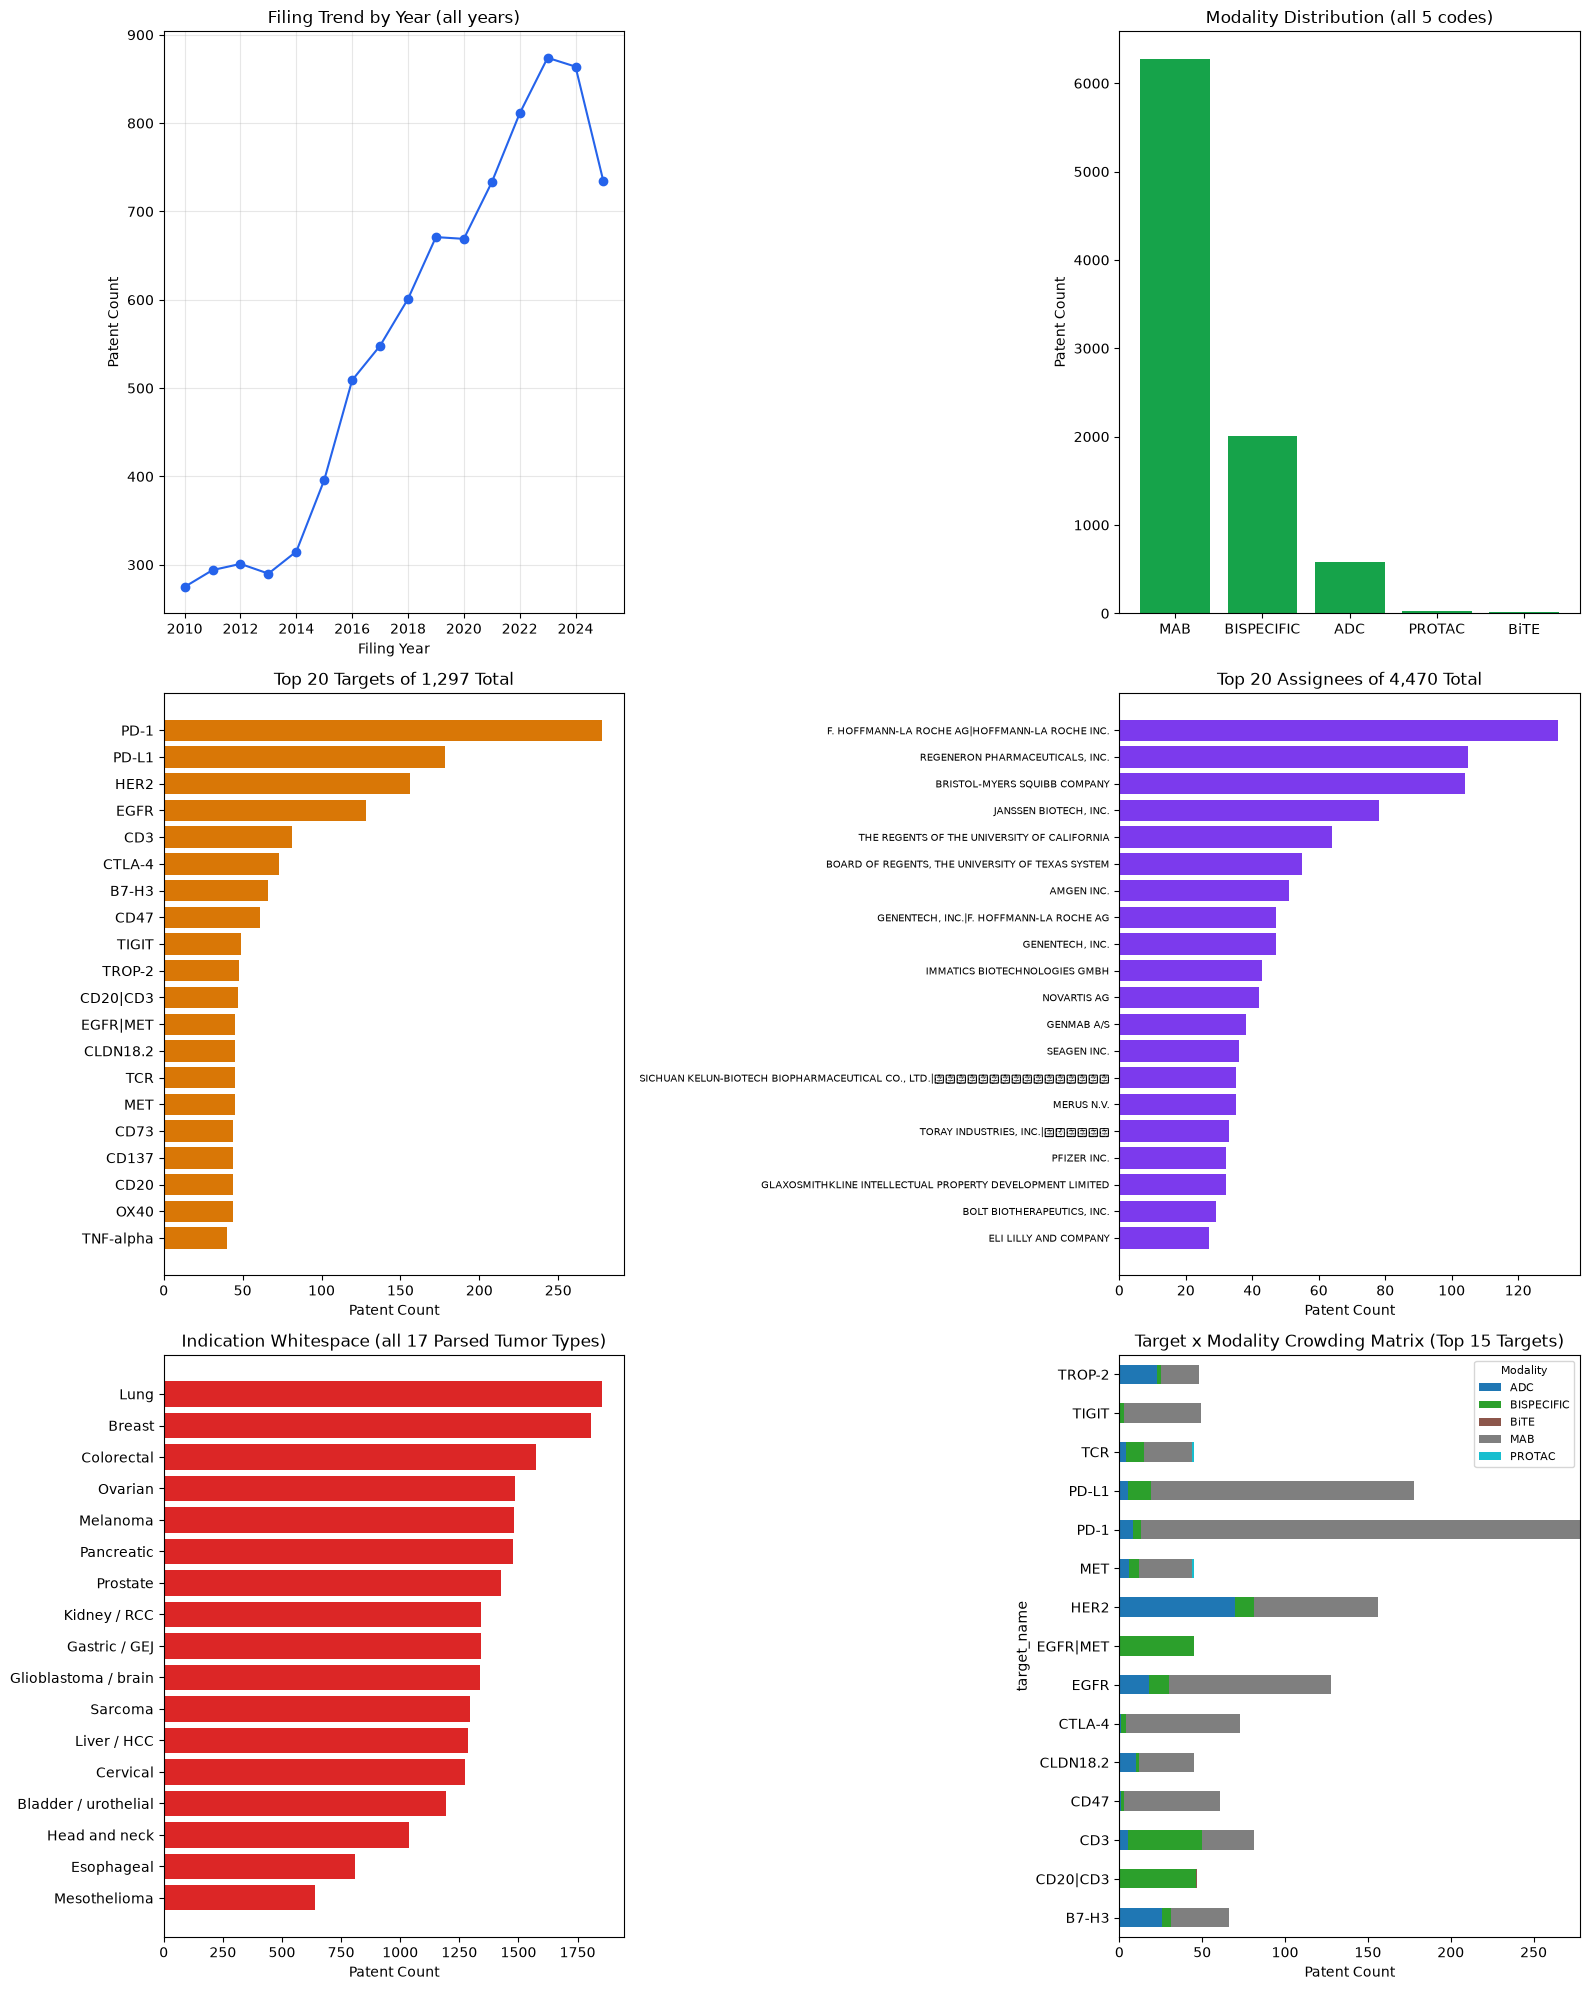

In [4]:
# Target x modality crowding matrix for the top 15 targets by volume (grid built for chart readability)
sql_target_modality_matrix = f"""
WITH top_targets AS (
  SELECT target_harmonized AS t, COUNT(*) AS n
  FROM read_csv_auto('{csv_path.as_posix()}') WHERE target_harmonized IS NOT NULL
  GROUP BY 1 ORDER BY n DESC LIMIT 15
)
SELECT d.target_harmonized AS target_name, d.modality_code, COUNT(*) AS n
FROM read_csv_auto('{csv_path.as_posix()}') d
JOIN top_targets tt ON d.target_harmonized = tt.t
GROUP BY 1, 2 ORDER BY target_name, n DESC;
"""
target_modality_matrix_df = con.sql(sql_target_modality_matrix).df()

top_targets_chart_df = full_targets_df.head(20)
top_assignees_chart_df = full_assignees_df.head(20)
indication_chart_df = full_indications_parsed_df.head(17)
matrix_pivot = target_modality_matrix_df.pivot(index="target_name", columns="modality_code", values="n").fillna(0)

fig, axes = plt.subplots(3, 2, figsize=(16, 20))
axes[0, 0].plot(filing_trend_df["filing_year"], filing_trend_df["n"], marker="o", color="#2563eb")
axes[0, 0].set_title("Filing Trend by Year (all years)"); axes[0, 0].set_xlabel("Filing Year"); axes[0, 0].set_ylabel("Patent Count"); axes[0, 0].grid(alpha=0.3)

modality_code_df = con.sql(f"SELECT modality_code, COUNT(*) n FROM read_csv_auto('{csv_path.as_posix()}') GROUP BY 1 ORDER BY n DESC").df()
axes[0, 1].bar(modality_code_df["modality_code"], modality_code_df["n"], color="#16a34a")
axes[0, 1].set_title("Modality Distribution (all 5 codes)"); axes[0, 1].set_ylabel("Patent Count")

axes[1, 0].barh(top_targets_chart_df["target_harmonized"][::-1], top_targets_chart_df["n"][::-1], color="#d97706")
axes[1, 0].set_title(f"Top 20 Targets of {len(full_targets_df):,} Total"); axes[1, 0].set_xlabel("Patent Count")

axes[1, 1].barh(top_assignees_chart_df["current_assignee"][::-1], top_assignees_chart_df["n"][::-1], color="#7c3aed")
axes[1, 1].set_title(f"Top 20 Assignees of {total_distinct_assignees:,} Total"); axes[1, 1].set_xlabel("Patent Count"); axes[1, 1].tick_params(axis="y", labelsize=7)

axes[2, 0].barh(indication_chart_df["tumor_type"][::-1], indication_chart_df["n"][::-1], color="#dc2626")
axes[2, 0].set_title("Indication Whitespace (all 17 Parsed Tumor Types)"); axes[2, 0].set_xlabel("Patent Count")

matrix_pivot.plot(kind="barh", stacked=True, ax=axes[2, 1], colormap="tab10")
axes[2, 1].set_title("Target x Modality Crowding Matrix (Top 15 Targets)"); axes[2, 1].set_xlabel("Patent Count")
axes[2, 1].legend(title="Modality", fontsize=8, title_fontsize=8)
plt.tight_layout()
plt.show()


## Entry 5: Target-Level Whitespace Scoring (A - Summary, B - Modality Share, C - Indication Matrix, D - Quadrant Classification)

Standardized on `target_harmonized`. A, B and D return the **full** set of every target meeting the stated minimum-volume threshold (>= 3 patents) - not a fixed top-N. C is a designed grid (top 25 targets x top 15 indications) sized generously for chart readability.


In [5]:
sql_target_whitespace_summary = f"""
WITH base AS (
  SELECT target_harmonized AS t, current_assignee, filing_year, modality_code,
         CASE WHEN indications IS NOT NULL AND TRIM(indications) NOT IN ('', 'oncology TA query hit') THEN 1 ELSE 0 END AS has_specific_indication
  FROM read_csv_auto('{csv_path.as_posix()}') WHERE target_harmonized IS NOT NULL
)
SELECT t AS target_name, COUNT(*) AS total_patents, COUNT(DISTINCT current_assignee) AS unique_assignees,
       COUNT(DISTINCT modality_code) AS distinct_modalities,
       SUM(has_specific_indication) AS patents_with_specific_indication,
       COUNT(*) - SUM(has_specific_indication) AS patents_generic_oncology_only,
       ROUND(100.0 * SUM(has_specific_indication) / COUNT(*), 1) AS pct_indication_resolved,
       SUM(CASE WHEN filing_year >= 2023 THEN 1 ELSE 0 END) AS filed_last_3y,
       ROUND(100.0 * SUM(CASE WHEN filing_year >= 2023 THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_recent
FROM base GROUP BY 1 HAVING COUNT(*) >= 3 ORDER BY total_patents DESC;
"""
target_whitespace_summary_df = con.sql(sql_target_whitespace_summary).df()

sql_target_modality_share = f"""
WITH base AS (
  SELECT target_harmonized AS t, modality_code
  FROM read_csv_auto('{csv_path.as_posix()}') WHERE target_harmonized IS NOT NULL
),
tot AS (SELECT t, COUNT(*) AS total FROM base GROUP BY 1)
SELECT b.t AS target_name, b.modality_code, COUNT(*) AS n, ROUND(100.0*COUNT(*)/tot.total,1) AS pct_of_target
FROM base b JOIN tot ON b.t = tot.t WHERE tot.total >= 3 GROUP BY 1,2,tot.total ORDER BY target_name, n DESC;
"""
target_modality_share_df = con.sql(sql_target_modality_share).df()

sql_target_indication_matrix = f"""
WITH expanded AS (
  SELECT target_harmonized AS t, TRIM(UNNEST(STR_SPLIT(TRIM(indications), '|'))) AS tumor
  FROM read_csv_auto('{csv_path.as_posix()}')
  WHERE indications IS NOT NULL AND TRIM(indications) NOT IN ('', 'oncology TA query hit')
    AND target_harmonized IS NOT NULL
),
top_t AS (
  SELECT target_harmonized AS t, COUNT(*) n FROM read_csv_auto('{csv_path.as_posix()}')
  WHERE target_harmonized IS NOT NULL GROUP BY 1 ORDER BY n DESC LIMIT 25
),
top_i AS (SELECT tumor, COUNT(*) n FROM expanded GROUP BY 1 ORDER BY n DESC LIMIT 15)
SELECT e.t AS target_name, e.tumor AS indication, COUNT(*) AS n
FROM expanded e JOIN top_t ON e.t = top_t.t JOIN top_i ON e.tumor = top_i.tumor
GROUP BY 1,2 ORDER BY target_name, n DESC;
"""
target_indication_matrix_df = con.sql(sql_target_indication_matrix).df()

sql_target_quadrant = f"""
WITH base AS (
  SELECT target_harmonized AS t, filing_year
  FROM read_csv_auto('{csv_path.as_posix()}') WHERE target_harmonized IS NOT NULL
),
agg AS (
  SELECT t AS target_name, COUNT(*) AS total_patents,
         SUM(CASE WHEN filing_year >= 2023 THEN 1 ELSE 0 END) AS recent_3y,
         ROUND(100.0*SUM(CASE WHEN filing_year >= 2023 THEN 1 ELSE 0 END)/COUNT(*),1) AS pct_recent
  FROM base GROUP BY 1 HAVING COUNT(*) >= 3
)
SELECT target_name, total_patents, recent_3y, pct_recent,
  CASE
    WHEN total_patents >= 30 AND pct_recent >= 30 THEN 'Hot/Crowded (high volume, high momentum)'
    WHEN total_patents >= 30 AND pct_recent < 30 THEN 'Mature/Legacy (high volume, cooling)'
    WHEN total_patents < 30 AND pct_recent >= 30 THEN 'Emerging Whitespace (low volume, accelerating)'
    ELSE 'Quiet/Underexplored (low volume, low momentum)'
  END AS whitespace_quadrant
FROM agg ORDER BY pct_recent DESC, total_patents ASC;
"""
target_quadrant_df = con.sql(sql_target_quadrant).df()

display(Markdown(f"**A. Target-Level Whitespace Summary - full list, {len(target_whitespace_summary_df):,} targets with >= 3 patents:**"))
display(target_whitespace_summary_df)
display(Markdown(f"**B. Target x Modality Share - full list, {len(target_modality_share_df):,} rows:**"))
display(target_modality_share_df)
display(Markdown(f"**C. Target x Indication Crowding Matrix (top 25 targets x top 15 indications, {len(target_indication_matrix_df):,} non-empty cells):**"))
display(target_indication_matrix_df)
display(Markdown(f"**D. Whitespace Quadrant Classification - full list, {len(target_quadrant_df):,} targets:**"))
display(target_quadrant_df)
display(Markdown("**Quadrant counts:**"))
display(target_quadrant_df["whitespace_quadrant"].value_counts().rename_axis("quadrant").reset_index(name="n_targets"))


**A. Target-Level Whitespace Summary - full list, 338 targets with >= 3 patents:**

,target_name,total_patents,unique_assignees,distinct_modalities,patents_with_specific_indication,patents_generic_oncology_only,pct_indication_resolved,filed_last_3y,pct_recent
0,PD-1,278,206,3,23.0,255.0,8.3,72.0,25.9
1,PD-L1,178,131,3,20.0,158.0,11.2,43.0,24.2
2,HER2,156,112,3,85.0,71.0,54.5,71.0,45.5
3,EGFR,128,101,3,38.0,90.0,29.7,30.0,23.4
4,CD3,81,67,3,51.0,30.0,63.0,33.0,40.7
5,CTLA-4,73,58,3,5.0,68.0,6.8,32.0,43.8
6,B7-H3,66,49,3,32.0,34.0,48.5,36.0,54.5
7,CD47,61,51,3,3.0,58.0,4.9,7.0,11.5
8,TIGIT,49,36,2,3.0,46.0,6.1,11.0,22.4
9,TROP-2,48,39,3,25.0,23.0,52.1,29.0,60.4


**B. Target x Modality Share - full list, 481 rows:**

,target_name,modality_code,n,pct_of_target
0,5T4,MAB,7,63.6
1,5T4,ADC,2,18.2
2,5T4,BISPECIFIC,2,18.2
3,5T4|CD3,BISPECIFIC,6,100.0
4,ADAM17,MAB,3,100.0
5,AGR2,MAB,3,100.0
6,ALK,MAB,5,62.5
7,ALK,ADC,1,12.5
8,ALK,PROTAC,1,12.5
9,ALK,BISPECIFIC,1,12.5


**C. Target x Indication Crowding Matrix (top 25 targets x top 15 indications, 344 non-empty cells):**

,target_name,indication,n
0,B7-H3,Lung,27
1,B7-H3,Glioblastoma / brain,12
2,B7-H3,Breast,12
3,B7-H3,Prostate,11
4,B7-H3,Ovarian,10
5,B7-H3,Colorectal,10
6,B7-H3,Kidney / RCC,10
7,B7-H3,Melanoma,9
8,B7-H3,Head and neck,9
9,B7-H3,Pancreatic,9


**D. Whitespace Quadrant Classification - full list, 338 targets:**

,target_name,total_patents,recent_3y,pct_recent,whitespace_quadrant
0,NECTIN2,3,3.0,100.0,"Emerging Whitespace (low volume, accelerating)"
1,TROP-2|CD28,3,3.0,100.0,"Emerging Whitespace (low volume, accelerating)"
2,VEGF|PD-1,3,3.0,100.0,"Emerging Whitespace (low volume, accelerating)"
3,CD19|CD28,3,3.0,100.0,"Emerging Whitespace (low volume, accelerating)"
4,NECTIN4|CD3,3,3.0,100.0,"Emerging Whitespace (low volume, accelerating)"
5,PD-L1|CD47,3,3.0,100.0,"Emerging Whitespace (low volume, accelerating)"
6,CLDN18.2-MMAE,3,3.0,100.0,"Emerging Whitespace (low volume, accelerating)"
7,VEGF|PD-L1,4,4.0,100.0,"Emerging Whitespace (low volume, accelerating)"
8,ENPP3,5,5.0,100.0,"Emerging Whitespace (low volume, accelerating)"
9,MET|EGFR,10,9.0,90.0,"Emerging Whitespace (low volume, accelerating)"


**Quadrant counts:**

,quadrant,n_targets
0,"Quiet/Underexplored (low volume, low momentum)",155
1,"Emerging Whitespace (low volume, accelerating)",153
2,"Mature/Legacy (high volume, cooling)",18
3,"Hot/Crowded (high volume, high momentum)",12


## Entry 6: Chart Pack 2 - Target Whitespace Multi-Angle View

Whitespace quadrant scatter (all 338 qualifying targets plotted; top 25 by volume annotated by name), target x indication crowding heatmap, modality share by target, and indication-resolution rate.


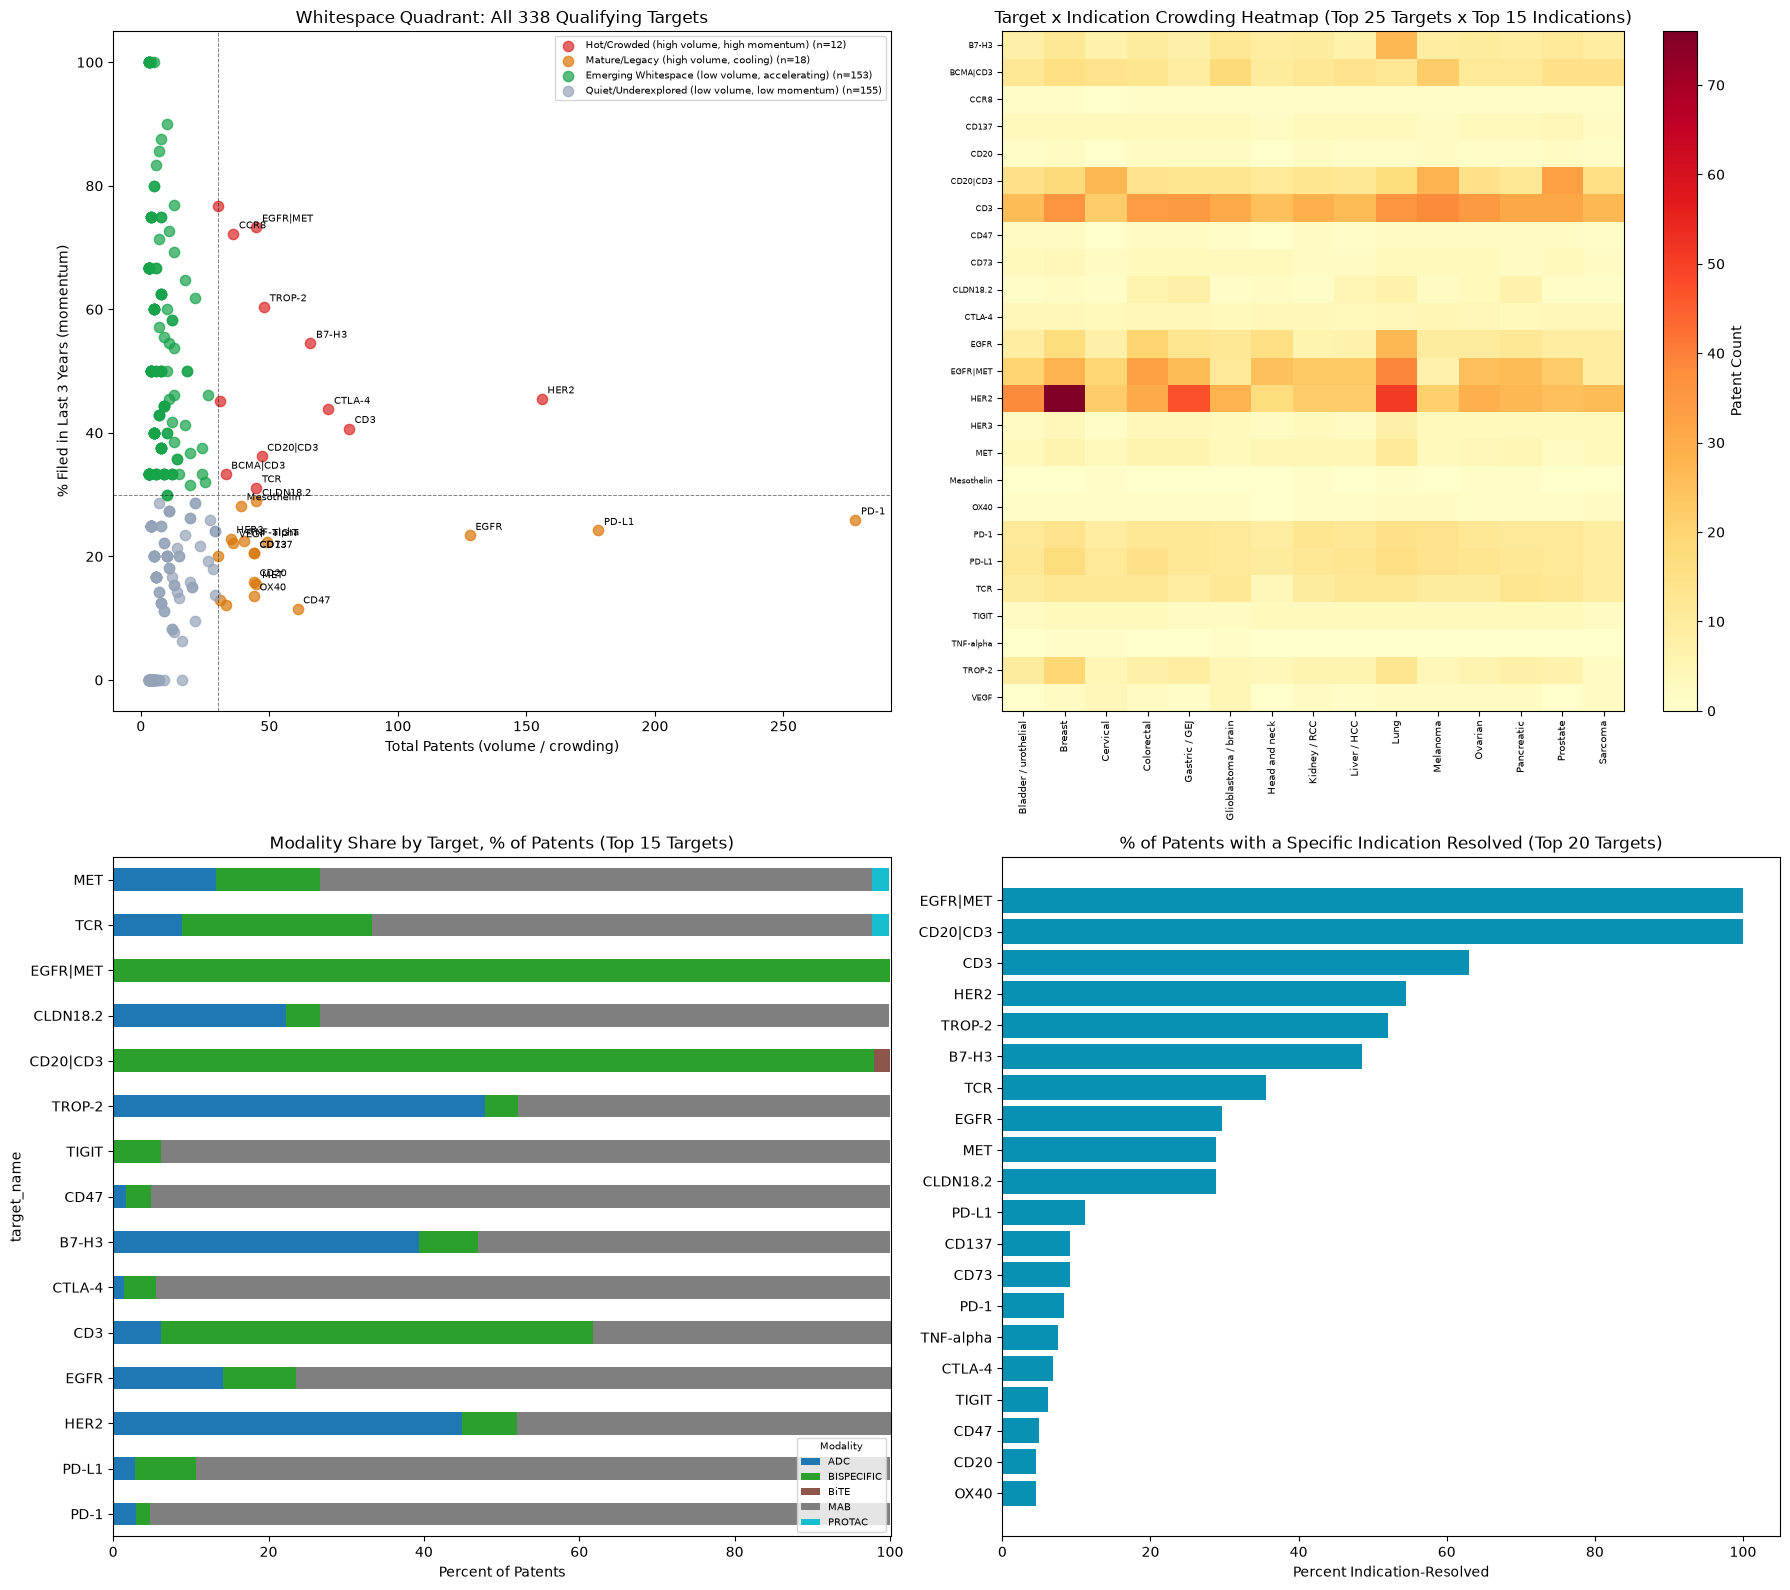

In [6]:
quadrant_colors = {
    "Hot/Crowded (high volume, high momentum)": "#dc2626",
    "Mature/Legacy (high volume, cooling)": "#d97706",
    "Emerging Whitespace (low volume, accelerating)": "#16a34a",
    "Quiet/Underexplored (low volume, low momentum)": "#94a3b8",
}
fig, axes = plt.subplots(2, 2, figsize=(18, 16))
ax = axes[0, 0]
for label, color in quadrant_colors.items():
    subset = target_quadrant_df[target_quadrant_df["whitespace_quadrant"] == label]
    ax.scatter(subset["total_patents"], subset["pct_recent"], label=f"{label} (n={len(subset)})", color=color, alpha=0.7, s=55)
top25 = target_quadrant_df.nlargest(25, "total_patents")
for _, row in top25.iterrows():
    ax.annotate(row["target_name"], (row["total_patents"], row["pct_recent"]), fontsize=7, xytext=(4, 4), textcoords="offset points")
ax.axvline(30, color="black", linestyle="--", linewidth=0.7, alpha=0.5)
ax.axhline(30, color="black", linestyle="--", linewidth=0.7, alpha=0.5)
ax.set_xlabel("Total Patents (volume / crowding)"); ax.set_ylabel("% Filed in Last 3 Years (momentum)")
ax.set_title(f"Whitespace Quadrant: All {len(target_quadrant_df)} Qualifying Targets"); ax.legend(fontsize=7, loc="upper right")

ax = axes[0, 1]
pivot_ti = target_indication_matrix_df.pivot(index="target_name", columns="indication", values="n").fillna(0)
im = ax.imshow(pivot_ti.values, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(len(pivot_ti.columns))); ax.set_xticklabels(pivot_ti.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(pivot_ti.index))); ax.set_yticklabels(pivot_ti.index, fontsize=6)
ax.set_title("Target x Indication Crowding Heatmap (Top 25 Targets x Top 15 Indications)"); fig.colorbar(im, ax=ax, label="Patent Count")

ax = axes[1, 0]
top15_targets = target_whitespace_summary_df.nlargest(15, "total_patents")["target_name"].tolist()
share_pivot = (
    target_modality_share_df[target_modality_share_df["target_name"].isin(top15_targets)]
    .pivot(index="target_name", columns="modality_code", values="pct_of_target").reindex(top15_targets).fillna(0)
)
share_pivot.plot(kind="barh", stacked=True, ax=ax, colormap="tab10")
ax.set_title("Modality Share by Target, % of Patents (Top 15 Targets)"); ax.set_xlabel("Percent of Patents")
ax.legend(title="Modality", fontsize=7, title_fontsize=7)

ax = axes[1, 1]
top20_res = target_whitespace_summary_df.nlargest(20, "total_patents").sort_values("pct_indication_resolved")
ax.barh(top20_res["target_name"], top20_res["pct_indication_resolved"], color="#0891b2")
ax.set_title("% of Patents with a Specific Indication Resolved (Top 20 Targets)"); ax.set_xlabel("Percent Indication-Resolved")
plt.tight_layout()
plt.show()


## Entry 7: Emerging Whitespace Deep-Dive

Full set of targets meeting the Emerging Whitespace definition (total patents < 30, >= 30% filed since 2023, minimum 5 patents to exclude single-filing noise) - assignee concentration, dominant modality, and filing recency detail.


In [7]:
sql_emerging_deepdive = f"""
WITH base AS (
  SELECT target_harmonized AS t, current_assignee, filing_year, modality_code,
         CASE WHEN indications IS NOT NULL AND TRIM(indications) NOT IN ('', 'oncology TA query hit') THEN TRIM(indications) ELSE NULL END AS ind
  FROM read_csv_auto('{csv_path.as_posix()}') WHERE target_harmonized IS NOT NULL
),
class AS (
  SELECT t, COUNT(*) total_patents,
         SUM(CASE WHEN filing_year>=2023 THEN 1 ELSE 0 END) recent_3y,
         ROUND(100.0*SUM(CASE WHEN filing_year>=2023 THEN 1 ELSE 0 END)/COUNT(*),1) pct_recent
  FROM base GROUP BY 1 HAVING COUNT(*) >= 5
),
emerging AS (SELECT t FROM class WHERE total_patents < 30 AND pct_recent >= 30),
assignee_rank AS (
  SELECT t, current_assignee, COUNT(*) n, ROW_NUMBER() OVER (PARTITION BY t ORDER BY COUNT(*) DESC) rn
  FROM base WHERE t IN (SELECT t FROM emerging) GROUP BY 1,2
),
top_assignee AS (SELECT t, current_assignee AS top_assignee, n AS top_assignee_patents FROM assignee_rank WHERE rn = 1),
modality_rank AS (
  SELECT t, modality_code, COUNT(*) n, ROW_NUMBER() OVER (PARTITION BY t ORDER BY COUNT(*) DESC) rn
  FROM base WHERE t IN (SELECT t FROM emerging) GROUP BY 1,2
),
top_modality AS (SELECT t, modality_code AS dominant_modality, n AS dominant_modality_patents FROM modality_rank WHERE rn = 1),
extra AS (
  SELECT t, MIN(filing_year) min_year, MAX(filing_year) max_year,
         COUNT(DISTINCT current_assignee) unique_assignees,
         SUM(CASE WHEN ind IS NOT NULL THEN 1 ELSE 0 END) specific_indication_patents
  FROM base WHERE t IN (SELECT t FROM emerging) GROUP BY 1
)
SELECT c.t AS target_name, c.total_patents, c.recent_3y, c.pct_recent,
       e.min_year AS first_filing_year, e.max_year AS latest_filing_year, e.unique_assignees,
       ta.top_assignee, ta.top_assignee_patents, ROUND(100.0*ta.top_assignee_patents/c.total_patents,1) AS top_assignee_share_pct,
       tm.dominant_modality, ROUND(100.0*tm.dominant_modality_patents/c.total_patents,1) AS dominant_modality_pct,
       e.specific_indication_patents, ROUND(100.0*e.specific_indication_patents/c.total_patents,1) AS pct_indication_resolved
FROM class c JOIN emerging em ON c.t = em.t JOIN extra e ON e.t = c.t
JOIN top_assignee ta ON ta.t = c.t JOIN top_modality tm ON tm.t = c.t
ORDER BY c.pct_recent DESC, c.total_patents DESC;
"""
emerging_deepdive_df = con.sql(sql_emerging_deepdive).df()

sql_emerging_trend = f"""
WITH base AS (
  SELECT target_harmonized AS t, filing_year
  FROM read_csv_auto('{csv_path.as_posix()}') WHERE target_harmonized IS NOT NULL
),
class AS (
  SELECT t, COUNT(*) total_patents,
         ROUND(100.0*SUM(CASE WHEN filing_year>=2023 THEN 1 ELSE 0 END)/COUNT(*),1) pct_recent
  FROM base GROUP BY 1 HAVING COUNT(*) >= 5
),
emerging AS (SELECT t FROM class WHERE total_patents < 30 AND pct_recent >= 30)
SELECT t AS target_name, filing_year, COUNT(*) AS n
FROM base WHERE t IN (SELECT t FROM emerging) AND filing_year BETWEEN 2015 AND 2025
GROUP BY 1,2 ORDER BY target_name, filing_year;
"""
emerging_trend_df = con.sql(sql_emerging_trend).df()

display(Markdown(f"**Emerging Whitespace Deep-Dive - full list, {len(emerging_deepdive_df):,} targets meeting the definition:**"))
display(emerging_deepdive_df)


**Emerging Whitespace Deep-Dive - full list, 92 targets meeting the definition:**

,target_name,total_patents,recent_3y,pct_recent,first_filing_year,latest_filing_year,unique_assignees,top_assignee,top_assignee_patents,top_assignee_share_pct,dominant_modality,dominant_modality_pct,specific_indication_patents,pct_indication_resolved
0,ENPP3,5,5.0,100.0,2024,2025,3,HUTCHMED LIMITED,3,60.0,ADC,80.0,5.0,100.0
1,MET|EGFR,10,9.0,90.0,2022,2025,9,"SICHUAN KELUN-BIOTECH BIOPHARMACEUTICAL CO., LTD.",2,20.0,BISPECIFIC,100.0,10.0,100.0
2,PTK7,8,7.0,87.5,2021,2025,7,"UIF (UNIVERSITY INDUSTRY FOUNDATION), YONSEI U...",2,25.0,MAB,75.0,3.0,37.5
3,PD-1|VEGF,7,6.0,85.7,2020,2025,7,CYTOCARES (SHANGHAI) INC.,1,14.3,BISPECIFIC,100.0,7.0,100.0
4,HLA-G,6,5.0,83.3,2013,2025,6,"HEFEI TG IMMUNOPHARMA CO., LTD.|合肥天港免疫药物有限公司",1,16.7,MAB,100.0,0.0,0.0
5,B7-H3|CD28,5,4.0,80.0,2021,2025,4,FORTVITA BIOLOGICS INC.,2,40.0,BISPECIFIC,100.0,5.0,100.0
6,EZH2,5,4.0,80.0,2020,2024,3,INJE UNIVERSITY INDUSTRY-ACADEMIC COOPERATION ...,3,60.0,PROTAC,40.0,3.0,60.0
7,GPRC5D|CD3,13,10.0,76.9,2017,2025,7,F. HOFFMANN-LA ROCHE AG|HOFFMANN-LA ROCHE INC.,4,30.8,BISPECIFIC,100.0,13.0,100.0
8,CRBN,8,6.0,75.0,2020,2025,8,UNIVERSITY OF ULSAN FOUNDATION FOR INDUSTRY CO...,1,12.5,PROTAC,87.5,8.0,100.0
9,LILRB2,8,6.0,75.0,2018,2025,7,"ONCORESPONSE, INC.",2,25.0,MAB,100.0,0.0,0.0


## Entry 8: Chart - Emerging Whitespace Deep-Dive

Volume/momentum, filing trend, assignee concentration, and dominant modality share for the top 25 (by volume) of the 92 emerging whitespace targets. Note `HER2-MMAE`, `TROP-2-Dxd` and `CEACAM5-DM4` appearing as distinct emerging entries - this is the payload-disaggregated `target_harmonized` field at work, directly resolving the earlier HER2/HER2-DXd conflation concern.


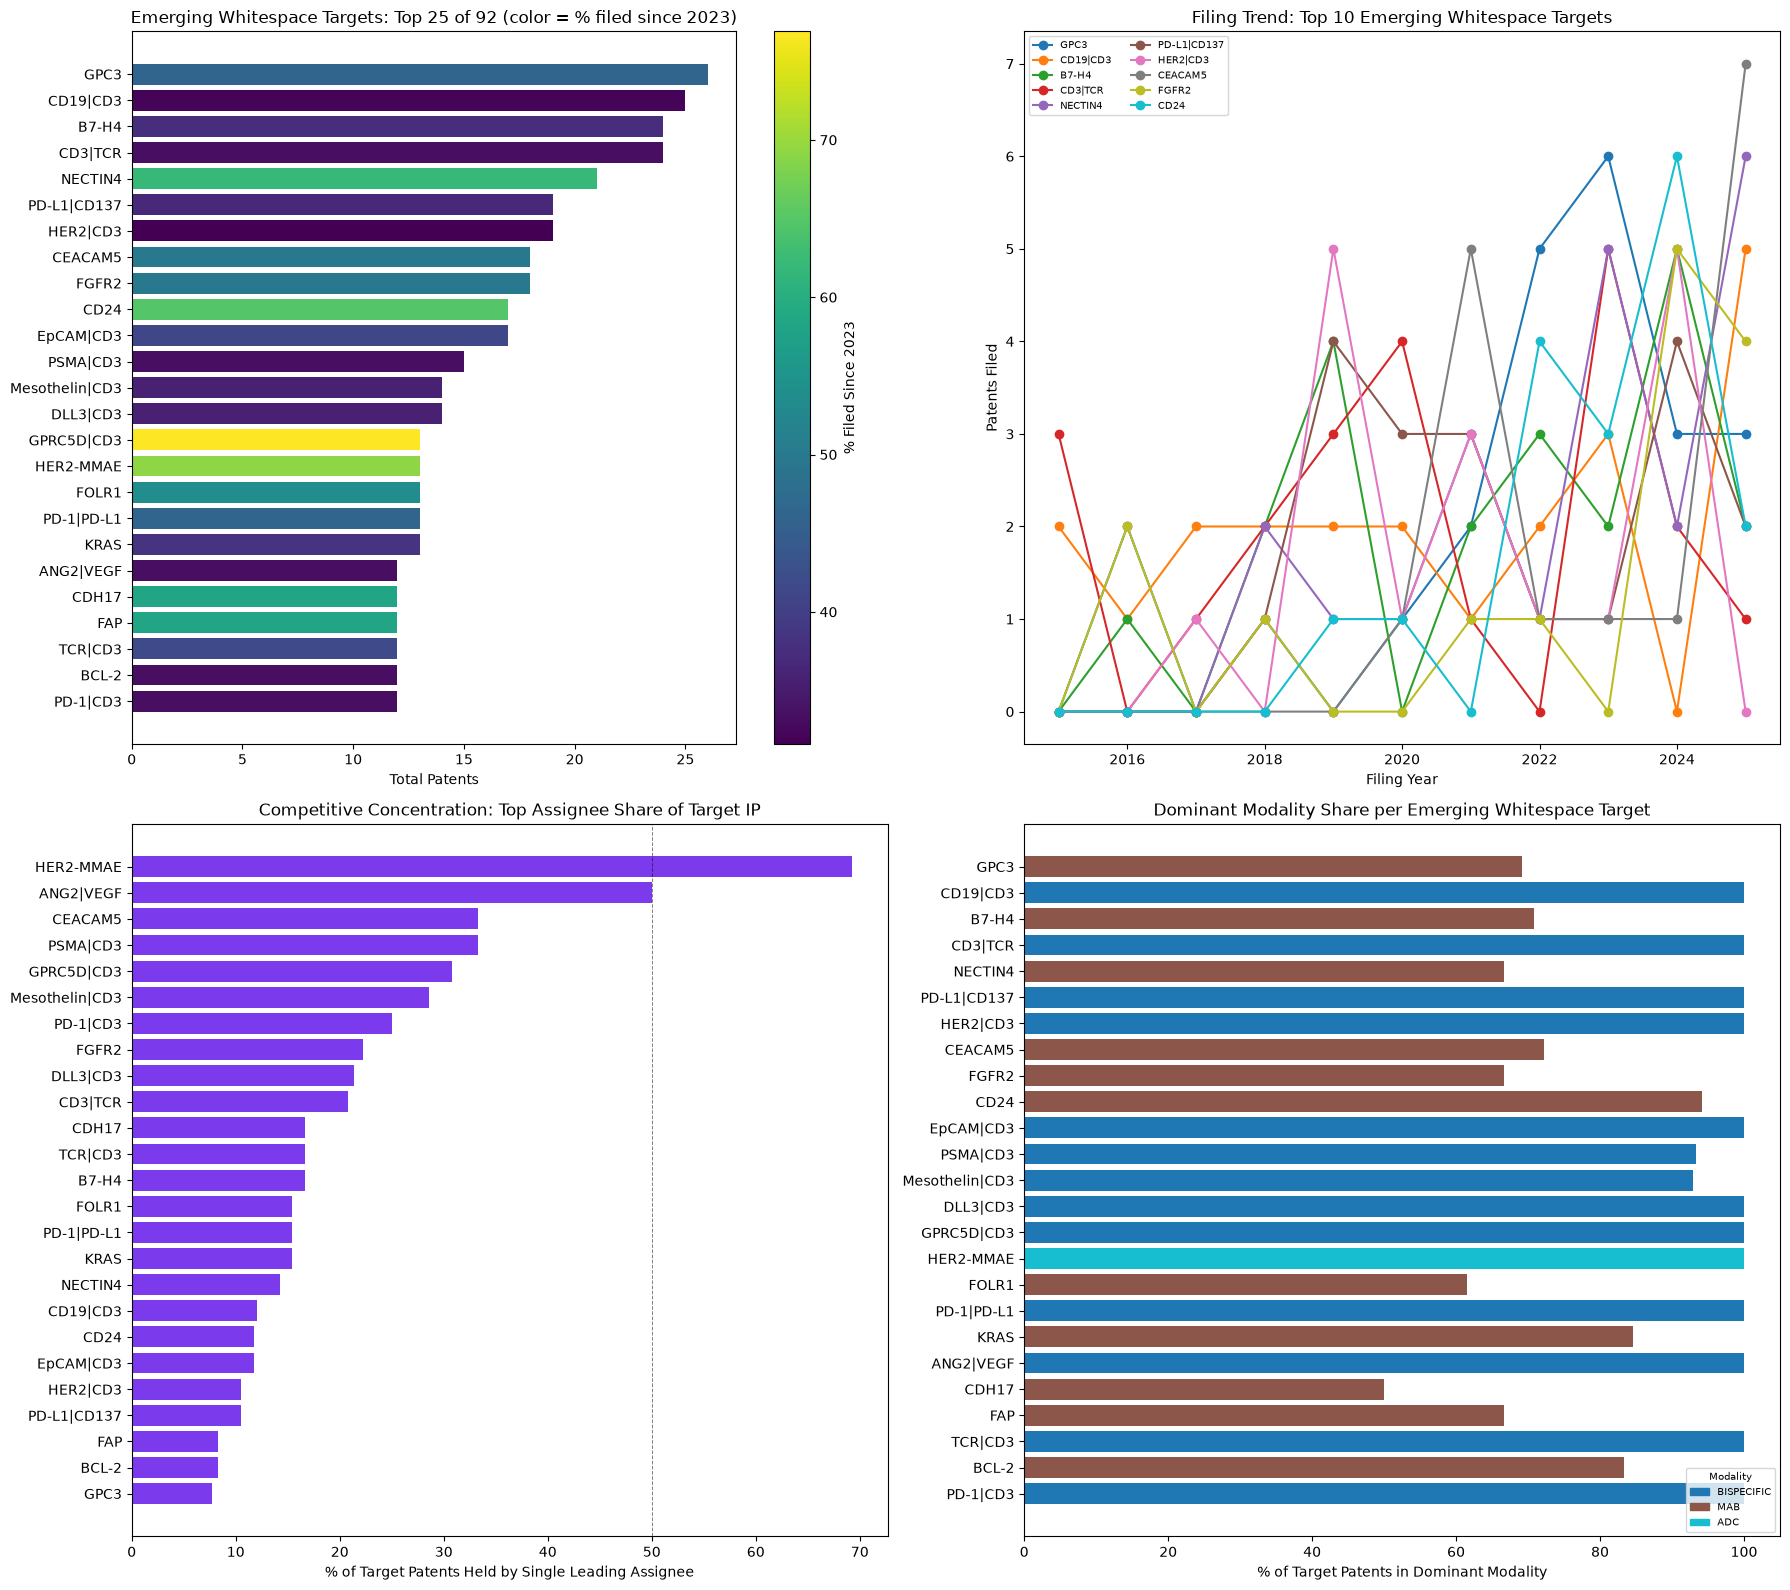

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(18, 16))
top25_emerging = emerging_deepdive_df.nlargest(25, "total_patents").sort_values("total_patents")
ax = axes[0, 0]
norm = mcolors.Normalize(vmin=top25_emerging["pct_recent"].min(), vmax=top25_emerging["pct_recent"].max())
colors_ = cm.viridis(norm(top25_emerging["pct_recent"]))
ax.barh(top25_emerging["target_name"], top25_emerging["total_patents"], color=colors_)
ax.set_title(f"Emerging Whitespace Targets: Top 25 of {len(emerging_deepdive_df)} (color = % filed since 2023)"); ax.set_xlabel("Total Patents")
sm = cm.ScalarMappable(cmap="viridis", norm=norm)
fig.colorbar(sm, ax=ax, label="% Filed Since 2023")

ax = axes[0, 1]
top10_names = emerging_deepdive_df.nlargest(10, "total_patents")["target_name"].tolist()
trend_pivot = (
    emerging_trend_df[emerging_trend_df["target_name"].isin(top10_names)]
    .pivot(index="filing_year", columns="target_name", values="n").fillna(0).reindex(columns=top10_names)
)
for name in top10_names:
    ax.plot(trend_pivot.index, trend_pivot[name], marker="o", label=name, linewidth=1.5)
ax.set_title("Filing Trend: Top 10 Emerging Whitespace Targets"); ax.set_xlabel("Filing Year"); ax.set_ylabel("Patents Filed")
ax.legend(fontsize=7, ncol=2)

ax = axes[1, 0]
conc_sorted = top25_emerging.sort_values("top_assignee_share_pct")
ax.barh(conc_sorted["target_name"], conc_sorted["top_assignee_share_pct"], color="#7c3aed")
ax.set_title("Competitive Concentration: Top Assignee Share of Target IP"); ax.set_xlabel("% of Target Patents Held by Single Leading Assignee")
ax.axvline(50, color="black", linestyle="--", linewidth=0.7, alpha=0.5)

ax = axes[1, 1]
modality_list = top25_emerging["dominant_modality"].unique().tolist()
modality_color_map = {m: cm.tab10(i / max(len(modality_list) - 1, 1)) for i, m in enumerate(modality_list)}
bar_colors = top25_emerging["dominant_modality"].map(modality_color_map)
ax.barh(top25_emerging["target_name"], top25_emerging["dominant_modality_pct"], color=bar_colors)
ax.set_title("Dominant Modality Share per Emerging Whitespace Target"); ax.set_xlabel("% of Target Patents in Dominant Modality")
handles = [plt.Rectangle((0, 0), 1, 1, color=modality_color_map[m]) for m in modality_list]
ax.legend(handles, modality_list, title="Modality", fontsize=7, title_fontsize=7, loc="lower right")
plt.tight_layout()
plt.show()


## Entry 9: Target x Modality x Indication Whitespace Grid

A 3-dimensional whitespace cut: for the top 20 targets x all 5 modality codes x top 12 indications, which combinations have zero filed patents? Grid sized generously (vs. the prior v1 notebook's 10x5x8) since the goal here is full coverage, not a small illustrative sample.


In [9]:
sql_target_modality_indication_grid = f"""
WITH expanded AS (
  SELECT target_harmonized AS t, modality_code, TRIM(UNNEST(STR_SPLIT(TRIM(indications), '|'))) AS tumor
  FROM read_csv_auto('{csv_path.as_posix()}')
  WHERE indications IS NOT NULL AND TRIM(indications) NOT IN ('', 'oncology TA query hit')
    AND target_harmonized IS NOT NULL AND modality_code IS NOT NULL
),
top_t AS (
  SELECT target_harmonized AS t, COUNT(*) n FROM read_csv_auto('{csv_path.as_posix()}')
  WHERE target_harmonized IS NOT NULL GROUP BY 1 ORDER BY n DESC LIMIT 20
),
top_i AS (SELECT tumor, COUNT(*) n FROM expanded GROUP BY 1 ORDER BY n DESC LIMIT 12),
top_m AS (SELECT DISTINCT modality_code FROM expanded),
combos AS (SELECT top_t.t, top_m.modality_code, top_i.tumor FROM top_t CROSS JOIN top_m CROSS JOIN top_i),
actual AS (
  SELECT t, modality_code, tumor, COUNT(*) n FROM expanded
  WHERE t IN (SELECT t FROM top_t) AND modality_code IN (SELECT modality_code FROM top_m) AND tumor IN (SELECT tumor FROM top_i)
  GROUP BY 1,2,3
)
SELECT combos.t AS target_name, combos.modality_code, combos.tumor AS indication, COALESCE(actual.n, 0) AS patent_count
FROM combos LEFT JOIN actual ON actual.t = combos.t AND actual.modality_code = combos.modality_code AND actual.tumor = combos.tumor
ORDER BY combos.t, combos.modality_code, patent_count DESC;
"""
target_modality_indication_grid_df = con.sql(sql_target_modality_indication_grid).df()

n_zero = (target_modality_indication_grid_df["patent_count"] == 0).sum()
n_cells = len(target_modality_indication_grid_df)
whitespace_cells_per_target = (
    target_modality_indication_grid_df.assign(is_zero=lambda d: d["patent_count"] == 0)
    .groupby("target_name")["is_zero"].sum().sort_values(ascending=False).rename("zero_count_combos").reset_index()
)

display(Markdown(f"**Grid: {n_cells:,} target x modality x indication combinations (20 targets x up to 5 modalities x 12 indications). "
                  f"{n_zero:,} ({100*n_zero/n_cells:.0f}%) have zero filed patents.**"))
display(target_modality_indication_grid_df)
display(Markdown("**Whitespace breadth per target (count of unclaimed combinations):**"))
display(whitespace_cells_per_target)


**Grid: 1,200 target x modality x indication combinations (20 targets x up to 5 modalities x 12 indications). 779 (65%) have zero filed patents.**

,target_name,modality_code,indication,patent_count
0,B7-H3,ADC,Lung,22
1,B7-H3,ADC,Breast,8
2,B7-H3,ADC,Glioblastoma / brain,8
3,B7-H3,ADC,Prostate,7
4,B7-H3,ADC,Colorectal,6
...,...,...,...,...
1195,TROP-2,PROTAC,Ovarian,0
1196,TROP-2,PROTAC,Sarcoma,0
1197,TROP-2,PROTAC,Liver / HCC,0
1198,TROP-2,PROTAC,Colorectal,0


**Whitespace breadth per target (count of unclaimed combinations):**

,target_name,zero_count_combos
0,TNF-alpha,58
1,EGFR|MET,48
2,CD20,48
3,TIGIT,48
4,OX40,48
5,CD47,40
6,CD137,38
7,MET,38
8,TROP-2,38
9,CD20|CD3,38


## Entry 10: Chart - Target x Modality x Indication Heatmaps

Small-multiple heatmaps for the top 12 (of 20) targets by volume (matplotlib subplot grid readability limit only), plus the full whitespace-breadth bar chart across all 20 targets in the grid.


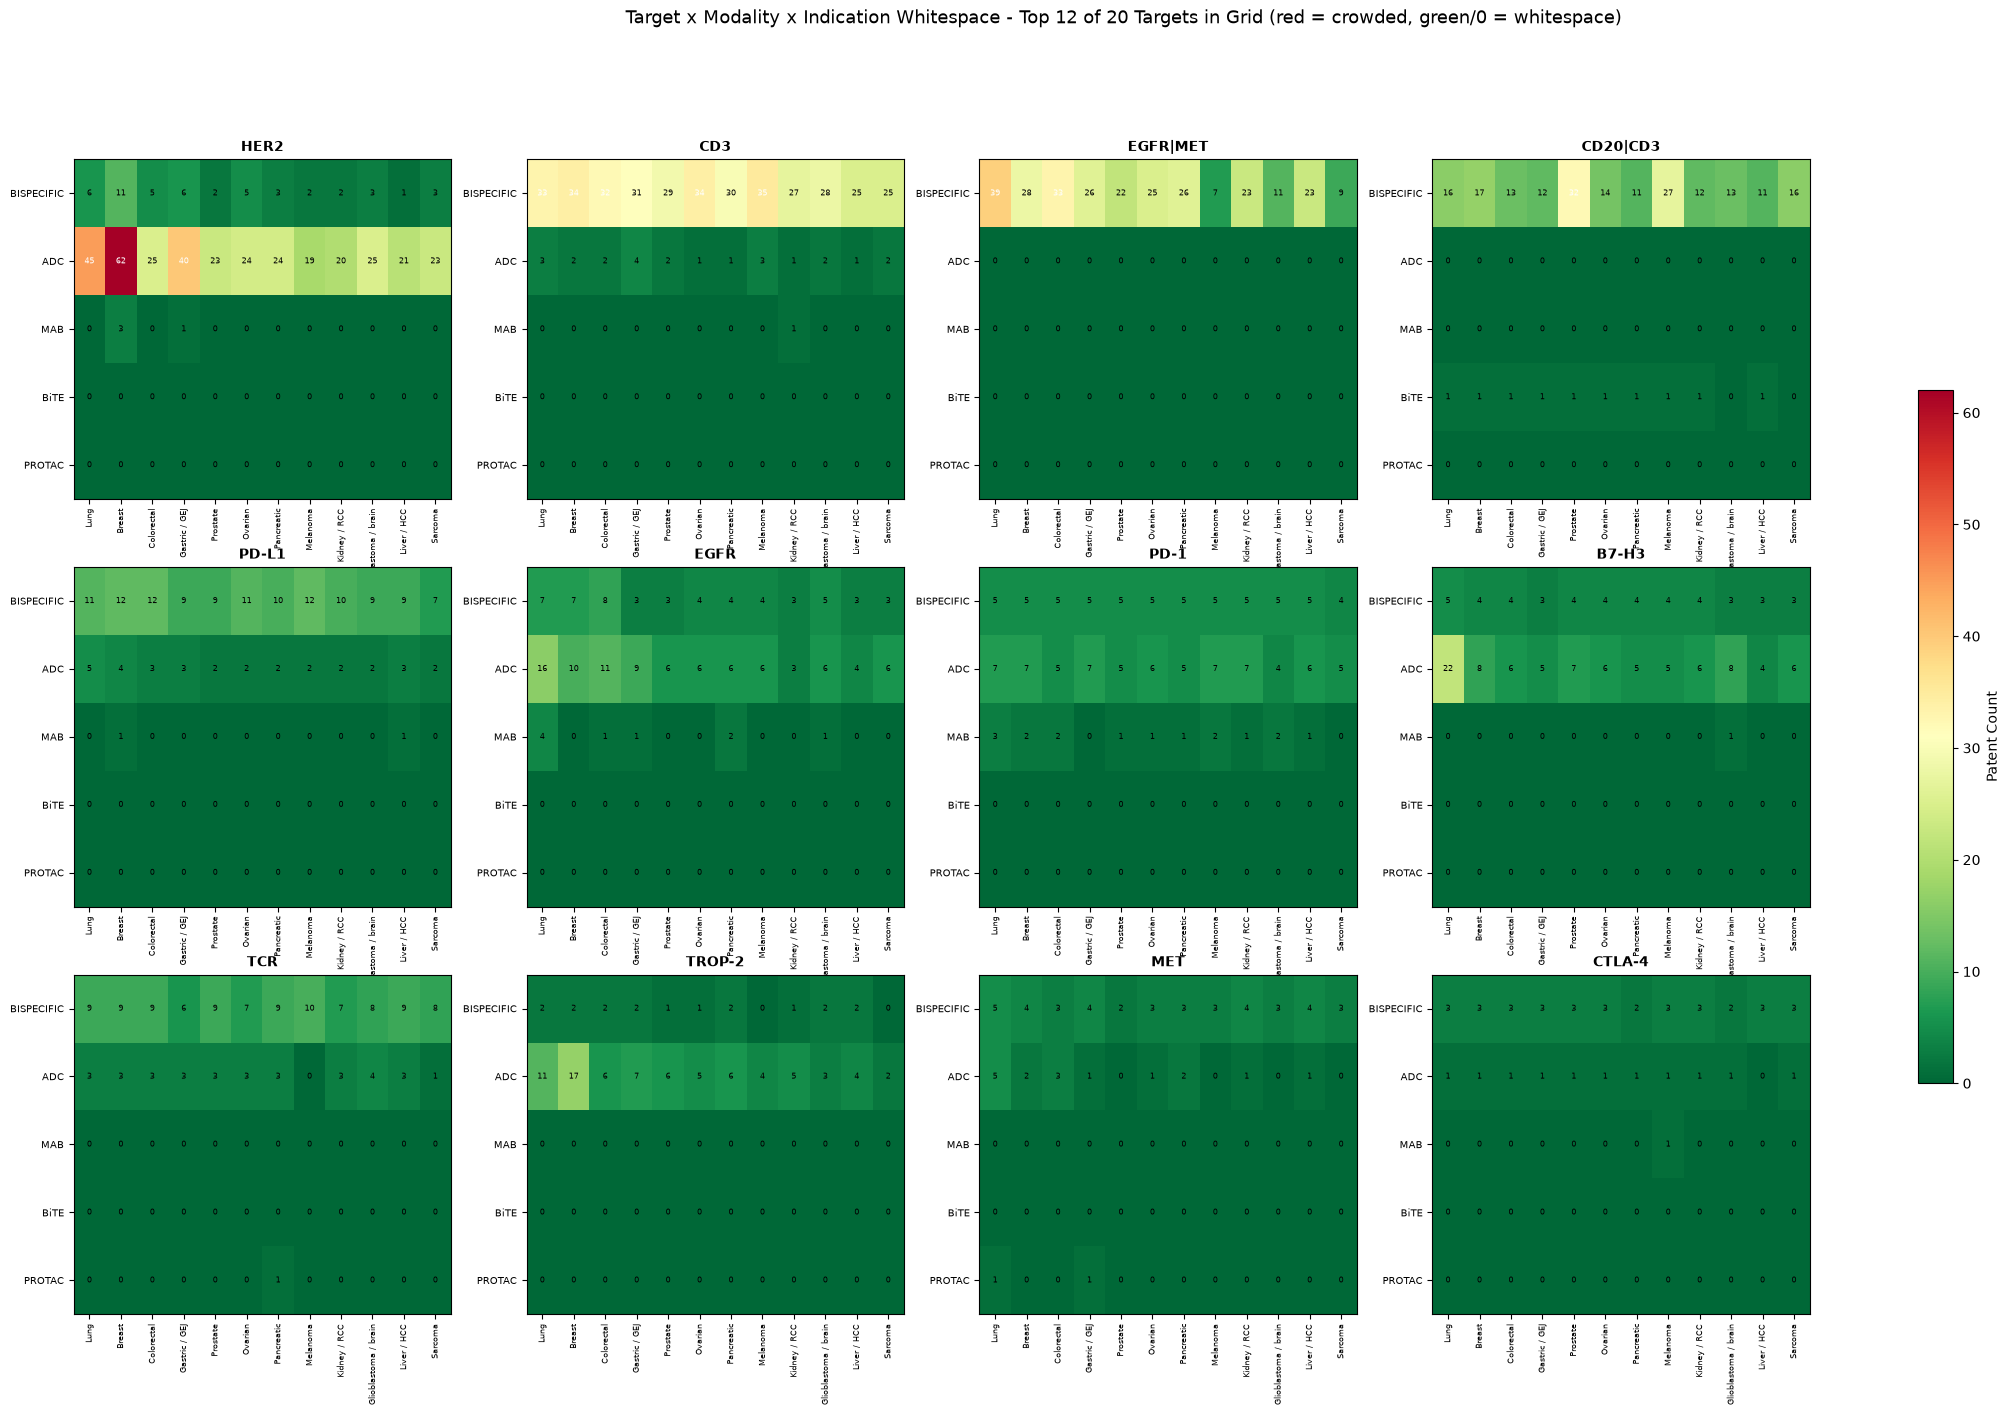

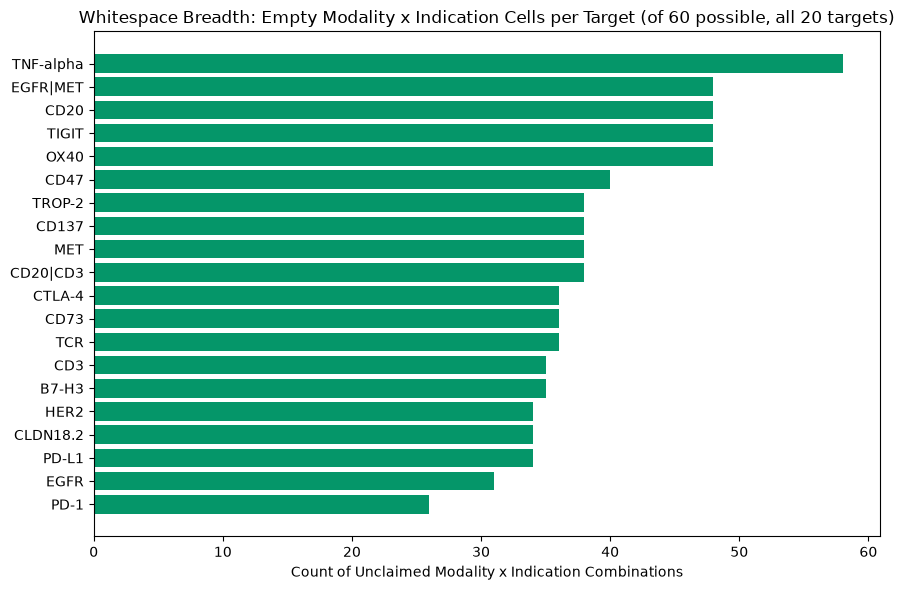

In [10]:
target_order = target_modality_indication_grid_df.groupby("target_name")["patent_count"].sum().sort_values(ascending=False).index.tolist()
modality_order = target_modality_indication_grid_df.groupby("modality_code")["patent_count"].sum().sort_values(ascending=False).index.tolist()
indication_order_g = target_modality_indication_grid_df.groupby("indication")["patent_count"].sum().sort_values(ascending=False).index.tolist()
top12_targets = target_order[:12]

fig, axes = plt.subplots(3, 4, figsize=(28, 15))
vmax = target_modality_indication_grid_df["patent_count"].max()
for ax, target in zip(axes.flat, top12_targets):
    sub = target_modality_indication_grid_df[target_modality_indication_grid_df["target_name"] == target]
    pivot = sub.pivot(index="modality_code", columns="indication", values="patent_count").reindex(index=modality_order, columns=indication_order_g).fillna(0)
    im = ax.imshow(pivot.values, cmap="RdYlGn_r", vmin=0, vmax=vmax, aspect="auto")
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = int(pivot.values[i, j])
            ax.text(j, i, str(val), ha="center", va="center", fontsize=6, color="white" if val > vmax * 0.5 else "black")
    ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, rotation=90, fontsize=6)
    ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index, fontsize=7)
    ax.set_title(target, fontsize=10, fontweight="bold")
fig.suptitle(f"Target x Modality x Indication Whitespace - Top 12 of {len(target_order)} Targets in Grid (red = crowded, green/0 = whitespace)", fontsize=13)
fig.colorbar(im, ax=axes, shrink=0.6, label="Patent Count")
plt.show()

fig2, ax2 = plt.subplots(figsize=(9, 6))
wb = whitespace_cells_per_target.sort_values("zero_count_combos")
ax2.barh(wb["target_name"], wb["zero_count_combos"], color="#059669")
ax2.set_title(f"Whitespace Breadth: Empty Modality x Indication Cells per Target (of {5*12} possible, all {len(wb)} targets)")
ax2.set_xlabel("Count of Unclaimed Modality x Indication Combinations")
plt.tight_layout()
plt.show()


## Entry 11: White Space Targets Available per Solid Tumor Indication

Mirrors the v1 notebook's solid-tumor whitespace cut, standardized on `target_harmonized`. Grid expanded to the top 30 established targets x all 17 solid tumor indications (excluding heme/liquid tumor keywords) for full coverage.


In [11]:
sql_solid_tumor_grid = f"""
WITH expanded AS (
  SELECT target_harmonized AS t, TRIM(UNNEST(STR_SPLIT(TRIM(indications), '|'))) AS tumor
  FROM read_csv_auto('{csv_path.as_posix()}')
  WHERE indications IS NOT NULL AND TRIM(indications) NOT IN ('', 'oncology TA query hit')
    AND target_harmonized IS NOT NULL
),
top_t AS (
  SELECT target_harmonized AS t, COUNT(*) n FROM read_csv_auto('{csv_path.as_posix()}')
  WHERE target_harmonized IS NOT NULL GROUP BY 1 ORDER BY n DESC LIMIT 30
),
all_i AS (SELECT DISTINCT tumor FROM expanded),
combos AS (SELECT top_t.t, all_i.tumor FROM top_t CROSS JOIN all_i),
actual AS (
  SELECT t, tumor, COUNT(*) n FROM expanded WHERE t IN (SELECT t FROM top_t) GROUP BY 1,2
)
SELECT combos.t AS target_name, combos.tumor AS indication, COALESCE(actual.n, 0) AS patent_count
FROM combos LEFT JOIN actual ON actual.t = combos.t AND actual.tumor = combos.tumor
ORDER BY combos.t, patent_count DESC;
"""
solid_tumor_grid_df = con.sql(sql_solid_tumor_grid).df()

whitespace_per_indication = (
    solid_tumor_grid_df.assign(is_zero=lambda d: d["patent_count"] == 0)
    .groupby("indication").agg(targets_with_zero=("is_zero", "sum"), targets_total=("is_zero", "size")).reset_index()
    .assign(pct_whitespace=lambda d: (100 * d["targets_with_zero"] / d["targets_total"]).round(1))
    .sort_values("pct_whitespace", ascending=False)
)

n_zero_st = (solid_tumor_grid_df["patent_count"] == 0).sum()
display(Markdown(f"**Solid Tumor x Target Grid: 30 established targets x {solid_tumor_grid_df['indication'].nunique()} solid tumor indications = "
                  f"{len(solid_tumor_grid_df):,} cells, {n_zero_st:,} ({100*n_zero_st/len(solid_tumor_grid_df):.0f}%) unclaimed:**"))
display(solid_tumor_grid_df)
display(Markdown("**Whitespace ranking by indication (% of the 30 top targets with zero patents in that indication):**"))
display(whitespace_per_indication)


**Solid Tumor x Target Grid: 30 established targets x 17 solid tumor indications = 510 cells, 48 (9%) unclaimed:**

,target_name,indication,patent_count
0,B7-H3,Lung,27
1,B7-H3,Breast,12
2,B7-H3,Glioblastoma / brain,12
3,B7-H3,Prostate,11
4,B7-H3,Ovarian,10
...,...,...,...
505,VEGF,Mesothelioma,1
506,VEGF,Bladder / urothelial,0
507,VEGF,Esophageal,0
508,VEGF,Head and neck,0


**Whitespace ranking by indication (% of the 30 top targets with zero patents in that indication):**

,indication,targets_with_zero,targets_total,pct_whitespace
7,Head and neck,6,30,20.0
12,Mesothelioma,6,30,20.0
4,Esophageal,5,30,16.7
16,Sarcoma,4,30,13.3
2,Cervical,4,30,13.3
15,Prostate,4,30,13.3
9,Liver / HCC,3,30,10.0
0,Bladder / urothelial,3,30,10.0
6,Glioblastoma / brain,2,30,6.7
11,Melanoma,2,30,6.7


## Entry 12: Chart - Solid Tumor Indication x Target Whitespace Heatmap

Full 30 x 17 heatmap (all cells labeled) plus the indication-level whitespace ranking bar chart.


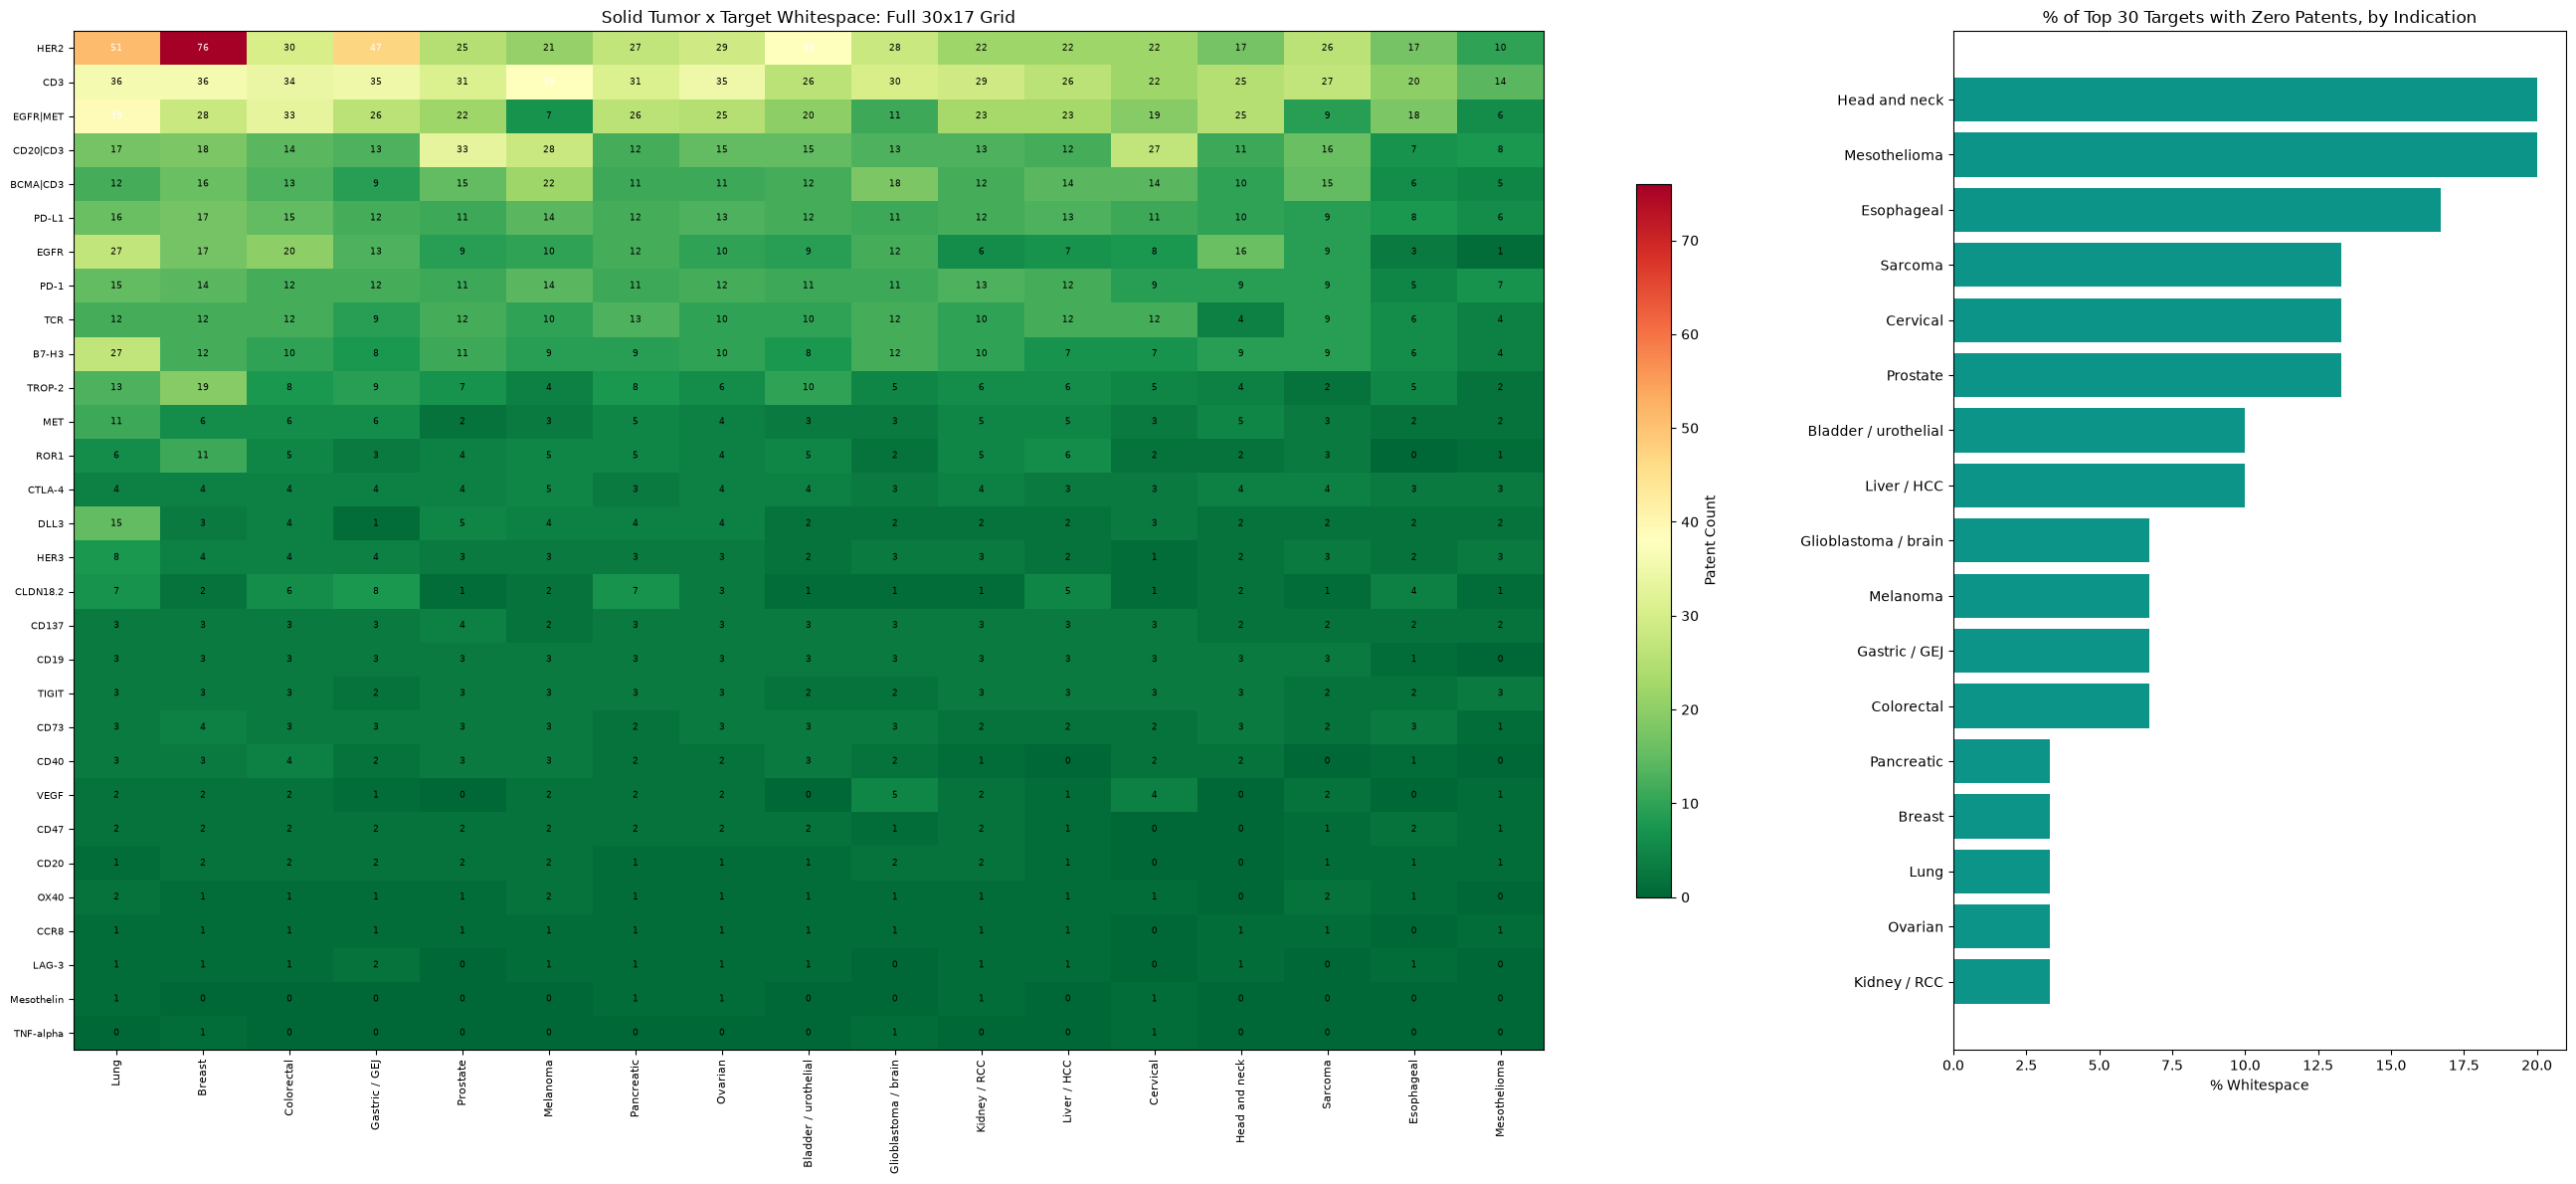

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(26, 12), gridspec_kw={"width_ratios": [3, 1]})
target_order_st = solid_tumor_grid_df.groupby("target_name")["patent_count"].sum().sort_values(ascending=False).index.tolist()
indication_order_st = solid_tumor_grid_df.groupby("indication")["patent_count"].sum().sort_values(ascending=False).index.tolist()
pivot_st = solid_tumor_grid_df.pivot(index="target_name", columns="indication", values="patent_count").reindex(index=target_order_st, columns=indication_order_st)

ax = axes[0]
im = ax.imshow(pivot_st.values, cmap="RdYlGn_r", aspect="auto")
for i in range(pivot_st.shape[0]):
    for j in range(pivot_st.shape[1]):
        val = int(pivot_st.values[i, j])
        ax.text(j, i, str(val), ha="center", va="center", fontsize=6.5, color="black" if val < pivot_st.values.max()*0.5 else "white")
ax.set_xticks(range(len(pivot_st.columns))); ax.set_xticklabels(pivot_st.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(pivot_st.index))); ax.set_yticklabels(pivot_st.index, fontsize=7)
ax.set_title(f"Solid Tumor x Target Whitespace: Full {pivot_st.shape[0]}x{pivot_st.shape[1]} Grid")
fig.colorbar(im, ax=ax, shrink=0.7, label="Patent Count")

ax2 = axes[1]
wpi_sorted = whitespace_per_indication.sort_values("pct_whitespace")
ax2.barh(wpi_sorted["indication"], wpi_sorted["pct_whitespace"], color="#0d9488")
ax2.set_title("% of Top 30 Targets with Zero Patents, by Indication")
ax2.set_xlabel("% Whitespace")
plt.tight_layout()
plt.show()


## Entry 13 (NEW): Target-Class Landscape

New cut not present in the v1 notebook, enabled by the `target_class` field (8 categories spanning simple mAbs, bispecifics, ADCs with/without resolved payload, PROTACs and BiTEs). Full distribution, cross-tab with modality, and filing-year trend by class - are ADCs and bispecifics accelerating relative to simple mAbs?


In [13]:
sql_target_class_dist = f"""
SELECT target_class, COUNT(*) n, ROUND(100.0*COUNT(*)/SUM(COUNT(*)) OVER (),1) AS pct
FROM read_csv_auto('{csv_path.as_posix()}') GROUP BY 1 ORDER BY n DESC;
"""
target_class_dist_df = con.sql(sql_target_class_dist).df()

sql_target_class_modality = f"""
SELECT target_class, modality_code, COUNT(*) n
FROM read_csv_auto('{csv_path.as_posix()}') GROUP BY 1,2 ORDER BY 1, n DESC;
"""
target_class_modality_df = con.sql(sql_target_class_modality).df()

sql_target_class_trend = f"""
SELECT target_class, filing_year, COUNT(*) n
FROM read_csv_auto('{csv_path.as_posix()}') WHERE filing_year BETWEEN 2015 AND 2025
GROUP BY 1,2 ORDER BY 1,2;
"""
target_class_trend_df = con.sql(sql_target_class_trend).df()

sql_target_class_recency = f"""
SELECT target_class, COUNT(*) total,
       SUM(CASE WHEN filing_year >= 2023 THEN 1 ELSE 0 END) recent_3y,
       ROUND(100.0*SUM(CASE WHEN filing_year >= 2023 THEN 1 ELSE 0 END)/COUNT(*),1) pct_recent
FROM read_csv_auto('{csv_path.as_posix()}') GROUP BY 1 ORDER BY pct_recent DESC;
"""
target_class_recency_df = con.sql(sql_target_class_recency).df()

display(Markdown(f"**Target-Class Distribution - all {len(target_class_dist_df)} classes, {target_class_dist_df['n'].sum():,} total patents:**"))
display(target_class_dist_df)
display(Markdown("**Target-Class x Modality Cross-Tab (full):**"))
display(target_class_modality_df)
display(Markdown("**Target-Class Momentum - % filed in last 3 years (2023-2025), full ranking:**"))
display(target_class_recency_df)


**Target-Class Distribution - all 8 classes, 8,901 total patents:**

,target_class,n,pct
0,MONOSPECIFIC_MAB,6258,70.3
1,BISPECIFIC,1930,21.7
2,ADC_PAYLOAD_UNSPECIFIED,416,4.7
3,ADC_WITH_PAYLOAD,170,1.9
4,BISPECIFIC_ADC_PAYLOAD_UNSPECIFIED,80,0.9
5,PROTAC,26,0.3
6,BISPECIFIC_ADC_WITH_PAYLOAD,11,0.1
7,BiTE,10,0.1


**Target-Class x Modality Cross-Tab (full):**

,target_class,modality_code,n
0,ADC_PAYLOAD_UNSPECIFIED,ADC,416
1,ADC_WITH_PAYLOAD,ADC,170
2,BISPECIFIC,BISPECIFIC,1914
3,BISPECIFIC,MAB,16
4,BISPECIFIC_ADC_PAYLOAD_UNSPECIFIED,BISPECIFIC,80
5,BISPECIFIC_ADC_WITH_PAYLOAD,BISPECIFIC,11
6,BiTE,BiTE,10
7,MONOSPECIFIC_MAB,MAB,6258
8,PROTAC,PROTAC,26


**Target-Class Momentum - % filed in last 3 years (2023-2025), full ranking:**

,target_class,total,recent_3y,pct_recent
0,BISPECIFIC_ADC_WITH_PAYLOAD,11,9.0,81.8
1,PROTAC,26,20.0,76.9
2,ADC_PAYLOAD_UNSPECIFIED,416,264.0,63.5
3,BISPECIFIC_ADC_PAYLOAD_UNSPECIFIED,80,47.0,58.8
4,ADC_WITH_PAYLOAD,170,76.0,44.7
5,BISPECIFIC,1930,690.0,35.8
6,BiTE,10,3.0,30.0
7,MONOSPECIFIC_MAB,6258,1363.0,21.8


## Entry 14 (NEW): Chart - Target-Class Landscape

Class distribution, filing trend by class (share of year, normalized to show mix shift), and momentum ranking. PROTAC and unspecified-payload ADC classes show the highest % filed in the last 3 years - both accelerating faster than the dominant `MONOSPECIFIC_MAB` class.


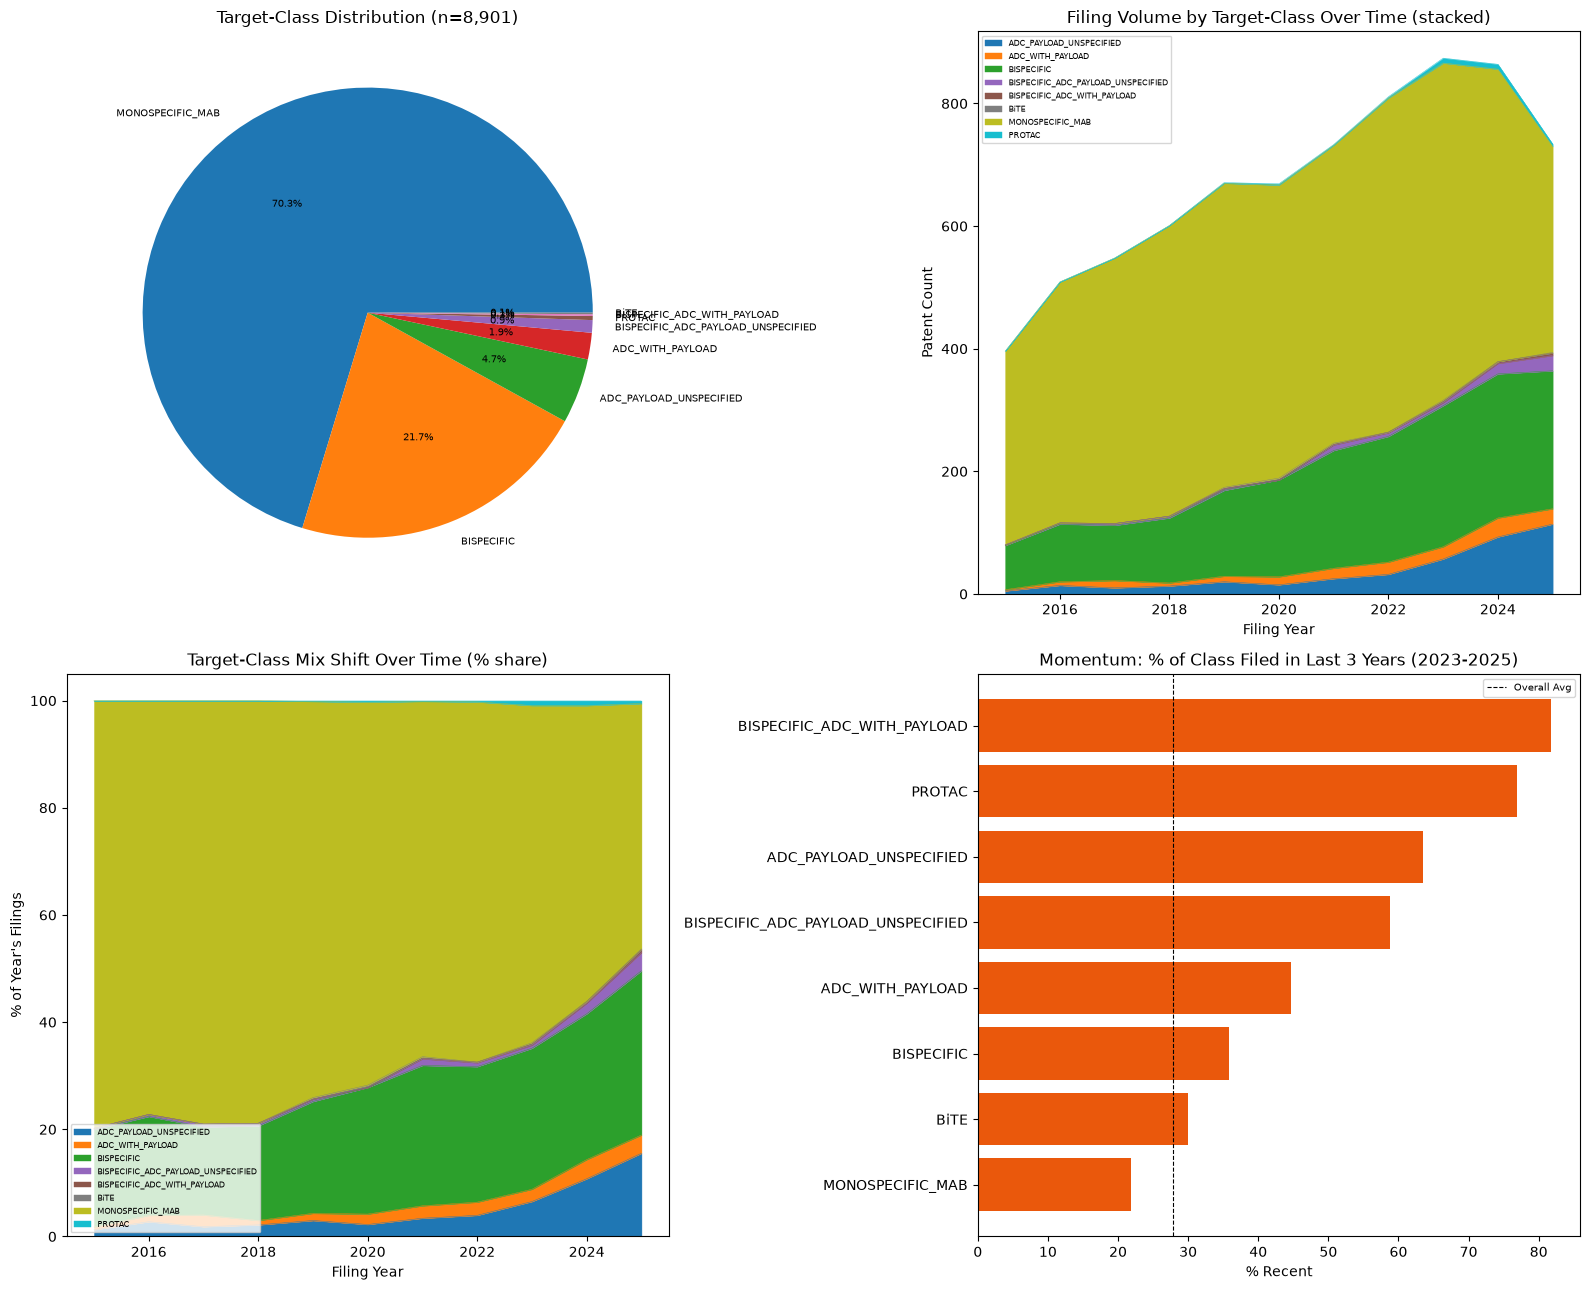

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 13))
ax = axes[0, 0]
ax.pie(target_class_dist_df["n"], labels=target_class_dist_df["target_class"], autopct="%1.1f%%", textprops={"fontsize": 7}, colors=cm.tab10.colors)
ax.set_title(f"Target-Class Distribution (n={target_class_dist_df['n'].sum():,})")

ax = axes[0, 1]
trend_pivot_tc = target_class_trend_df.pivot(index="filing_year", columns="target_class", values="n").fillna(0)
trend_pivot_tc.plot(kind="area", stacked=True, ax=ax, colormap="tab10", linewidth=0.3)
ax.set_title("Filing Volume by Target-Class Over Time (stacked)"); ax.set_xlabel("Filing Year"); ax.set_ylabel("Patent Count")
ax.legend(fontsize=6, loc="upper left")

ax = axes[1, 0]
trend_share_tc = trend_pivot_tc.div(trend_pivot_tc.sum(axis=1), axis=0) * 100
trend_share_tc.plot(kind="area", stacked=True, ax=ax, colormap="tab10", linewidth=0.3)
ax.set_title("Target-Class Mix Shift Over Time (% share)"); ax.set_xlabel("Filing Year"); ax.set_ylabel("% of Year's Filings")
ax.legend(fontsize=6, loc="lower left")

ax = axes[1, 1]
tcr_sorted = target_class_recency_df.sort_values("pct_recent")
ax.barh(tcr_sorted["target_class"], tcr_sorted["pct_recent"], color="#ea580c")
ax.set_title("Momentum: % of Class Filed in Last 3 Years (2023-2025)"); ax.set_xlabel("% Recent")
ax.axvline(target_class_recency_df["recent_3y"].sum() / target_class_recency_df["total"].sum() * 100, color="black", linestyle="--", linewidth=0.8, label="Overall Avg")
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()


## Entry 15 (NEW): Single vs. Multi-Target (Bispecific/Multispecific) Landscape

New cut using `n_targets` and `bispecific_complete`. Full list of every distinct dual-target pair derived from `target_harmonized` (split on `|`) with counts - no cap, since this is the actual combinatorial "who is pairing with whom" map of the bispecific landscape.


In [15]:
sql_n_targets_dist = f"""
SELECT n_targets, COUNT(*) n, ROUND(100.0*COUNT(*)/SUM(COUNT(*)) OVER (),1) AS pct
FROM read_csv_auto('{csv_path.as_posix()}') GROUP BY 1 ORDER BY n_targets;
"""
n_targets_dist_df = con.sql(sql_n_targets_dist).df()

sql_bispecific_complete_dist = f"""
SELECT COALESCE(bispecific_complete, 'null (single-target / not applicable)') AS bispecific_complete, COUNT(*) n
FROM read_csv_auto('{csv_path.as_posix()}') GROUP BY 1 ORDER BY n DESC;
"""
bispecific_complete_dist_df = con.sql(sql_bispecific_complete_dist).df()

sql_dual_target_pairs = f"""
SELECT target_harmonized AS target_pair, COUNT(*) n,
       ROUND(100.0*SUM(CASE WHEN filing_year >= 2023 THEN 1 ELSE 0 END)/COUNT(*),1) AS pct_recent,
       COUNT(DISTINCT current_assignee) AS unique_assignees
FROM read_csv_auto('{csv_path.as_posix()}')
WHERE target_harmonized LIKE '%|%' GROUP BY 1 ORDER BY n DESC;
"""
dual_target_pairs_df = con.sql(sql_dual_target_pairs).df()

sql_bispecific_partner_freq = f"""
WITH pairs AS (
  SELECT TRIM(UNNEST(STR_SPLIT(target_harmonized, '|'))) AS partner, target_harmonized
  FROM read_csv_auto('{csv_path.as_posix()}') WHERE target_harmonized LIKE '%|%'
)
SELECT partner, COUNT(*) AS n_patents_involved, COUNT(DISTINCT target_harmonized) AS n_distinct_pairings
FROM pairs GROUP BY 1 ORDER BY n_patents_involved DESC;
"""
bispecific_partner_freq_df = con.sql(sql_bispecific_partner_freq).df()

display(Markdown(f"**Number of Targets per Patent (`n_targets`) - full distribution:**"))
display(n_targets_dist_df)
display(Markdown("**Bispecific Completeness Flag - full distribution:**"))
display(bispecific_complete_dist_df)
display(Markdown(f"**All {len(dual_target_pairs_df):,} distinct dual/multi-target pairs (full list, no cap):**"))
display(dual_target_pairs_df)
display(Markdown(f"**Bispecific partner frequency - which single antigens appear most often as one arm of a pair, full list of {len(bispecific_partner_freq_df):,} antigens:**"))
display(bispecific_partner_freq_df)


**Number of Targets per Patent (`n_targets`) - full distribution:**

,n_targets,n,pct
0,0,3567,40.1
1,1,3840,43.1
2,2,1485,16.7
3,3,6,0.1
4,4,3,0.0


**Bispecific Completeness Flag - full distribution:**

,bispecific_complete,n
0,null (single-target / not applicable),6885
1,yes,1479
2,NO-no-target,308
3,review-1-antigen,229


**All 604 distinct dual/multi-target pairs (full list, no cap):**

,target_pair,n,pct_recent,unique_assignees
0,CD20|CD3,47,36.2,19
1,EGFR|MET,45,73.3,20
2,BCMA|CD3,33,33.3,20
3,EGFR|CD3,26,19.2,21
4,CD19|CD3,25,32.0,20
...,...,...,...,...
599,CD3|HER2,1,100.0,1
600,CD47|TCR,1,0.0,1
601,DLL3|EGFR,1,0.0,1
602,CD22|CD137,1,100.0,1


**Bispecific partner frequency - which single antigens appear most often as one arm of a pair, full list of 246 antigens:**

,partner,n_patents_involved,n_distinct_pairings
0,CD3,552,118
1,EGFR,174,47
2,PD-1,147,38
3,PD-L1,145,53
4,TCR,114,38
5,HER2,103,35
6,CD137,97,36
7,VEGF,74,28
8,MET,70,15
9,CD28,69,31


## Entry 16 (NEW): Chart - Bispecific/Multi-Target Landscape

`n_targets` distribution, top 20 dual-target pairs, and top 20 partner antigens by involvement (CD3 dominates as the universal T-cell engager arm).


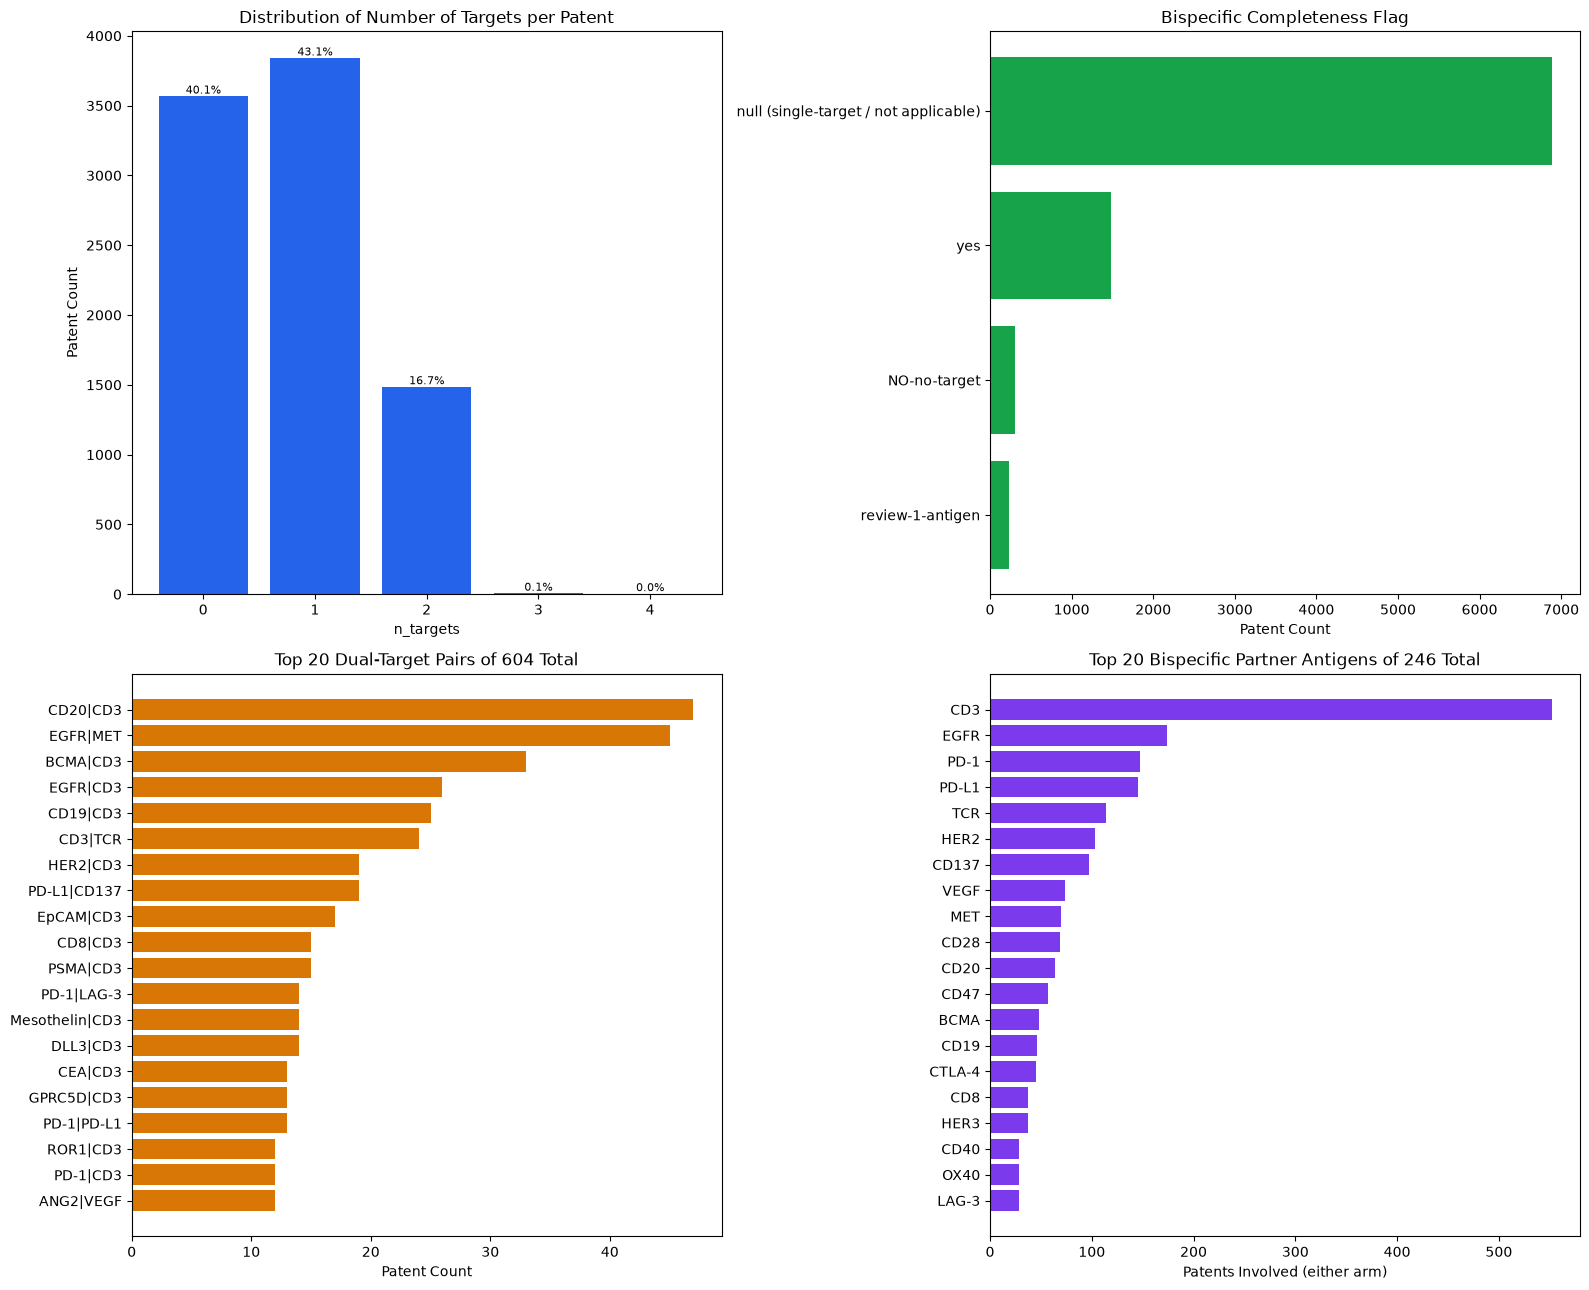

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 13))
ax = axes[0, 0]
ax.bar(n_targets_dist_df["n_targets"].astype(str), n_targets_dist_df["n"], color="#2563eb")
ax.set_title("Distribution of Number of Targets per Patent"); ax.set_xlabel("n_targets"); ax.set_ylabel("Patent Count")
for i, row in n_targets_dist_df.iterrows():
    ax.text(i, row["n"], f"{row['pct']}%", ha="center", va="bottom", fontsize=8)

ax = axes[0, 1]
bc_sorted = bispecific_complete_dist_df.sort_values("n")
ax.barh(bc_sorted["bispecific_complete"], bc_sorted["n"], color="#16a34a")
ax.set_title("Bispecific Completeness Flag"); ax.set_xlabel("Patent Count")

ax = axes[1, 0]
top20_pairs = dual_target_pairs_df.nlargest(20, "n").sort_values("n")
ax.barh(top20_pairs["target_pair"], top20_pairs["n"], color="#d97706")
ax.set_title(f"Top 20 Dual-Target Pairs of {len(dual_target_pairs_df)} Total"); ax.set_xlabel("Patent Count")

ax = axes[1, 1]
top20_partners = bispecific_partner_freq_df.nlargest(20, "n_patents_involved").sort_values("n_patents_involved")
ax.barh(top20_partners["partner"], top20_partners["n_patents_involved"], color="#7c3aed")
ax.set_title(f"Top 20 Bispecific Partner Antigens of {len(bispecific_partner_freq_df)} Total"); ax.set_xlabel("Patents Involved (either arm)")
plt.tight_layout()
plt.show()


## Entry 17 (NEW): Payload-Class Whitespace Analysis

**Directly resolves the earlier user concern**: in the original dataset, HER2 and HER2-DXd (and other ADC payload variants) were folded together because payload was unavailable. Here, `target_harmonized` already encodes the payload into the target label (e.g. `HER2`, `HER2-Dxd`, `HER2-MMAE`, `HER2-DM1`), and `payload_class`/`payload`/`payload_short` give the ADC payload chemistry directly. Full `payload_class` distribution (34 classes, no cap), a base-target x payload crosstab for every ADC target, and an explicit HER2 payload breakdown.


In [17]:
sql_payload_class_dist = f"""
SELECT payload_class, COUNT(*) n
FROM read_csv_auto('{csv_path.as_posix()}') WHERE payload_class IS NOT NULL
GROUP BY 1 ORDER BY n DESC;
"""
payload_class_dist_df = con.sql(sql_payload_class_dist).df()

sql_adc_target_payload = f"""
SELECT target_harmonized AS adc_target_payload_label, payload_class, payload_short, COUNT(*) n,
       ROUND(100.0*SUM(CASE WHEN filing_year >= 2023 THEN 1 ELSE 0 END)/COUNT(*),1) AS pct_recent,
       COUNT(DISTINCT current_assignee) AS unique_assignees
FROM read_csv_auto('{csv_path.as_posix()}')
WHERE target_class IN ('ADC_WITH_PAYLOAD','ADC_PAYLOAD_UNSPECIFIED','BISPECIFIC_ADC_WITH_PAYLOAD','BISPECIFIC_ADC_PAYLOAD_UNSPECIFIED')
GROUP BY 1,2,3 ORDER BY n DESC;
"""
adc_target_payload_df = con.sql(sql_adc_target_payload).df()

sql_her2_payload_breakdown = f"""
SELECT target_harmonized AS her2_label, payload_class, payload_short, COUNT(*) n,
       MIN(filing_year) first_year, MAX(filing_year) last_year,
       COUNT(DISTINCT current_assignee) unique_assignees
FROM read_csv_auto('{csv_path.as_posix()}')
WHERE target_harmonized LIKE 'HER2%' AND target_harmonized NOT LIKE '%|%'
GROUP BY 1,2,3 ORDER BY n DESC;
"""
her2_payload_breakdown_df = con.sql(sql_her2_payload_breakdown).df()

sql_payload_base_target_matrix = f"""
WITH adc AS (
  SELECT target_harmonized,
         CASE WHEN target_harmonized LIKE '%-%' THEN SPLIT_PART(target_harmonized, '-', 1) ELSE target_harmonized END AS base_target,
         payload_short, filing_year, current_assignee
  FROM read_csv_auto('{csv_path.as_posix()}')
  WHERE target_class IN ('ADC_WITH_PAYLOAD','ADC_PAYLOAD_UNSPECIFIED')
),
top_base AS (SELECT base_target, COUNT(*) n FROM adc GROUP BY 1 ORDER BY n DESC LIMIT 20)
SELECT adc.base_target, COALESCE(adc.payload_short, 'unspecified') AS payload_short, COUNT(*) n
FROM adc JOIN top_base ON adc.base_target = top_base.base_target
GROUP BY 1,2 ORDER BY base_target, n DESC;
"""
payload_base_target_matrix_df = con.sql(sql_payload_base_target_matrix).df()

display(Markdown(f"**Full Payload-Class Distribution - all {len(payload_class_dist_df)} classes, {payload_class_dist_df['n'].sum():,} patents with a resolved payload class:**"))
display(payload_class_dist_df)
display(Markdown(f"**Every ADC target x payload label (from `target_harmonized`) - full list, {len(adc_target_payload_df):,} rows:**"))
display(adc_target_payload_df)
display(Markdown("**HER2 Payload Breakdown - the exact resolution of the earlier HER2/HER2-DXd conflation concern:**"))
display(her2_payload_breakdown_df)


**Full Payload-Class Distribution - all 34 classes, 178 patents with a resolved payload class:**

,payload_class,n
0,topoisomerase I inhibitor,64
1,microtubule inhibitor (auristatin),28
2,maytansinoid or topoisomerase I inhibitor (amb...,13
3,pyrrolobenzodiazepine (PBD) dimer,12
4,maytansinoid (tubulin inhibitor),11
5,immunostimulatory (IO ADC),10
6,benzodiazepine dimer (DNA cross-linker),3
7,topoisomerase I inhibitor (irinotecan metabolite),3
8,duocarmazine (DNA alkylator),2
9,calicheamicin,2


**Every ADC target x payload label (from `target_harmonized`) - full list, 262 rows:**

,adc_target_payload_label,payload_class,payload_short,n,pct_recent,unique_assignees
0,NaN,NaN,NaN,94,55.3,71
1,HER2,NaN,NaN,57,75.4,32
2,TROP-2,NaN,NaN,18,66.7,16
3,EGFR,NaN,NaN,18,61.1,16
4,B7-H3,NaN,NaN,17,58.8,13
5,CLDN18.2,NaN,NaN,10,60.0,8
6,B7-H3,topoisomerase I inhibitor,NaN,10,100.0,6
7,HER2-MMAE,NaN,MMAE,10,90.0,4
8,HER2-Dxd,topoisomerase I inhibitor,Dxd,9,11.1,1
9,EGFR|MET,NaN,NaN,9,100.0,9


**HER2 Payload Breakdown - the exact resolution of the earlier HER2/HER2-DXd conflation concern:**

,her2_label,payload_class,payload_short,n,first_year,last_year,unique_assignees
0,HER2,NaN,NaN,143,2010,2025,105
1,HER2-MMAE,NaN,MMAE,10,2020,2025,4
2,HER2-Dxd,topoisomerase I inhibitor,Dxd,9,2021,2024,1
3,HER2,topoisomerase I inhibitor,NaN,4,2023,2024,2
4,HER2-MMAE,microtubule inhibitor (auristatin),MMAE,3,2022,2022,1
5,HER2,maytansinoid or topoisomerase I inhibitor (amb...,NaN,3,2014,2024,3
6,HER2-DM1,maytansinoid (tubulin inhibitor),DM1,3,2015,2019,3
7,HER2-DM1,NaN,DM1,2,2016,2019,2
8,HER2,microtubule inhibitor (auristatin),NaN,2,2016,2023,2
9,HER2-Duocarmycin,duocarmazine (DNA alkylator),Duocarmycin,2,2016,2018,2


## Entry 18 (NEW): Chart - Payload-Class Whitespace

Payload-class distribution, and a base-target x payload heatmap for the top 20 ADC base targets (e.g. HER2, TROP-2, EGFR) showing which specific payload chemistries are already claimed vs. still open ("unspecified" bucket = payload not yet disclosed/resolved, a candidate whitespace signal in itself).


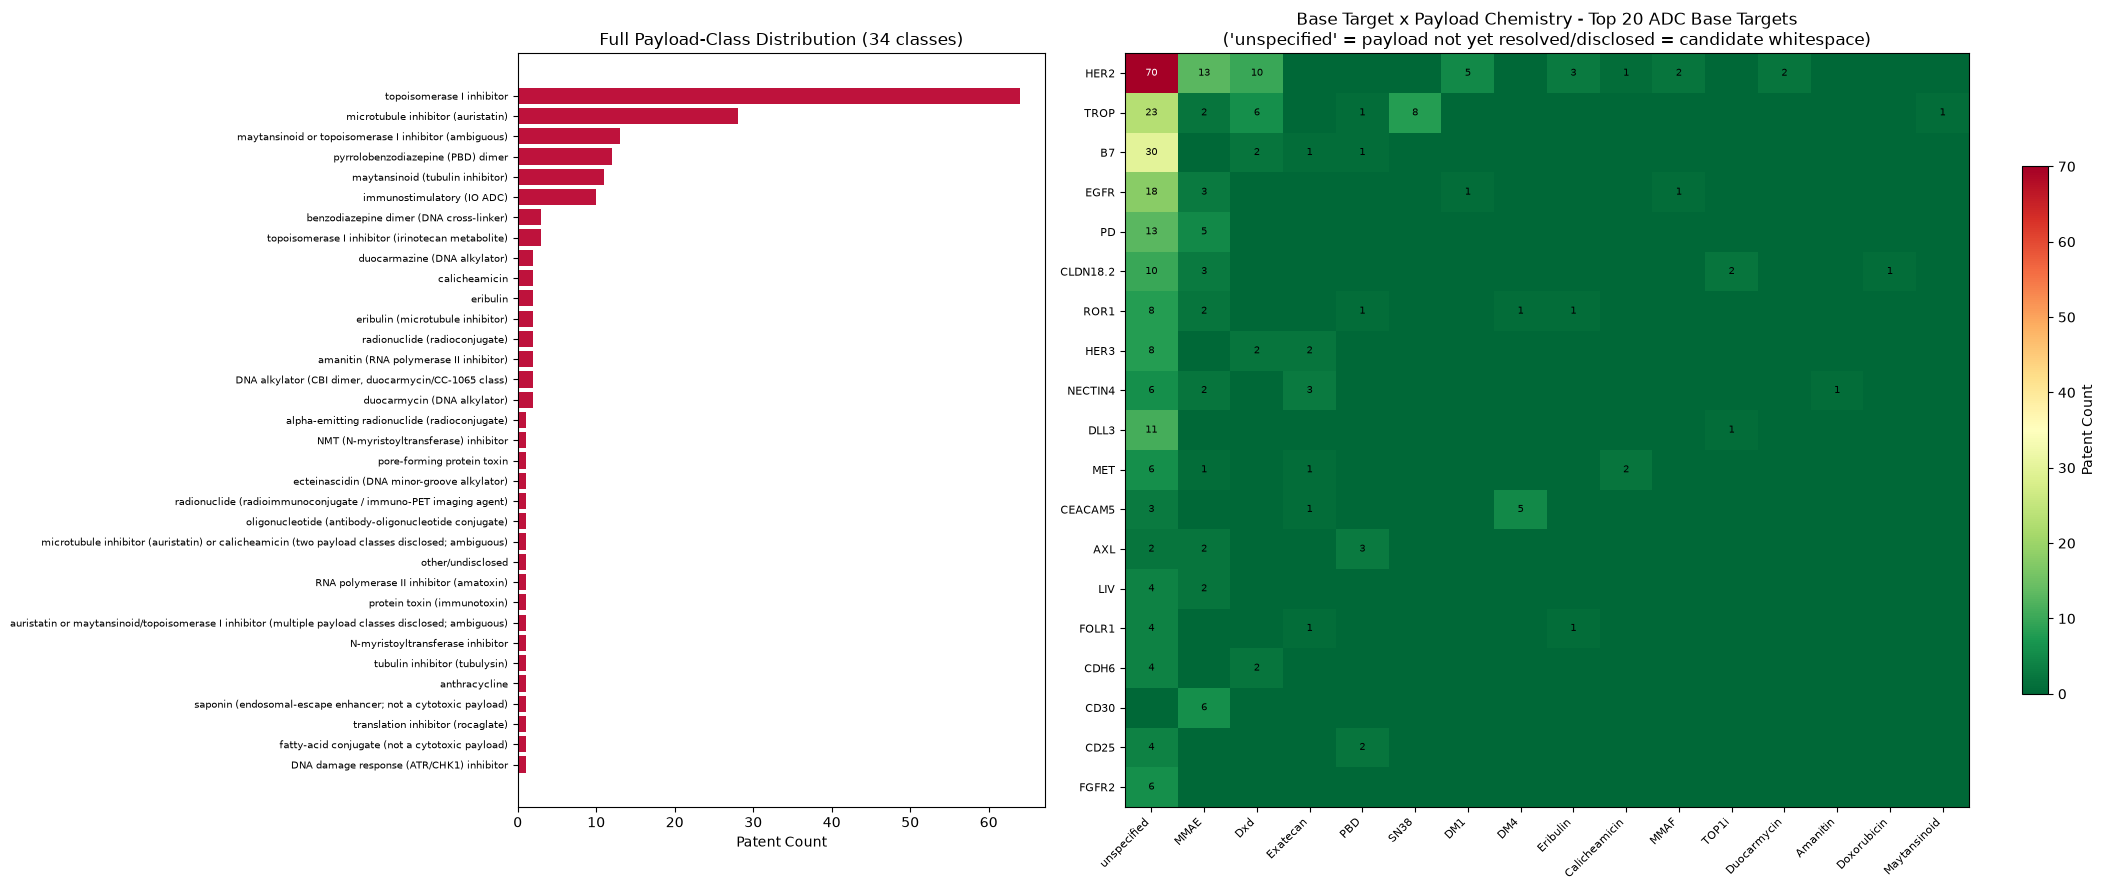

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(22, 9), gridspec_kw={"width_ratios": [1, 2]})
ax = axes[0]
pc_sorted = payload_class_dist_df.sort_values("n")
ax.barh(pc_sorted["payload_class"], pc_sorted["n"], color="#be123c")
ax.set_title(f"Full Payload-Class Distribution ({len(payload_class_dist_df)} classes)"); ax.set_xlabel("Patent Count")
ax.tick_params(axis="y", labelsize=7)

ax = axes[1]
base_order = payload_base_target_matrix_df.groupby("base_target")["n"].sum().sort_values(ascending=False).index.tolist()
payload_order = payload_base_target_matrix_df.groupby("payload_short")["n"].sum().sort_values(ascending=False).index.tolist()
pivot_pb = payload_base_target_matrix_df.pivot(index="base_target", columns="payload_short", values="n").reindex(index=base_order, columns=payload_order).fillna(0)
im = ax.imshow(pivot_pb.values, cmap="RdYlGn_r", aspect="auto")
for i in range(pivot_pb.shape[0]):
    for j in range(pivot_pb.shape[1]):
        val = int(pivot_pb.values[i, j])
        if val > 0:
            ax.text(j, i, str(val), ha="center", va="center", fontsize=7, color="black" if val < pivot_pb.values.max()*0.5 else "white")
ax.set_xticks(range(len(pivot_pb.columns))); ax.set_xticklabels(pivot_pb.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(pivot_pb.index))); ax.set_yticklabels(pivot_pb.index, fontsize=8)
ax.set_title("Base Target x Payload Chemistry - Top 20 ADC Base Targets\n('unspecified' = payload not yet resolved/disclosed = candidate whitespace)")
fig.colorbar(im, ax=ax, shrink=0.7, label="Patent Count")
plt.tight_layout()
plt.show()


## Entry 19 (NEW): Competitive Concentration & Claim-Depth Analysis

Another "other way to analyze the data" per the brief: (1) an HHI-style competitive concentration score per target (how monopolized vs. fragmented is the IP), (2) claim-depth metrics (independent/total claims, target/sequence/epitope-level disclosure) cross-tabbed by `target_class`, and (3) the relationship between `resolution_confidence` and claim depth (does richer claim language make target resolution easier?).


In [19]:
sql_hhi_concentration = f"""
WITH base AS (
  SELECT target_harmonized AS t, current_assignee, COUNT(*) AS n
  FROM read_csv_auto('{csv_path.as_posix()}') WHERE target_harmonized IS NOT NULL
  GROUP BY 1,2
),
tot AS (SELECT t, SUM(n) AS total FROM base GROUP BY 1 HAVING SUM(n) >= 5),
shares AS (SELECT b.t, b.current_assignee, b.n, tot.total, POWER(100.0*b.n/tot.total, 2) AS share_sq
           FROM base b JOIN tot ON b.t = tot.t)
SELECT t AS target_name, MAX(total) AS total_patents, COUNT(*) AS n_assignees,
       ROUND(SUM(share_sq), 0) AS hhi,
       CASE WHEN SUM(share_sq) >= 2500 THEN 'Highly Concentrated (single-player risk)'
            WHEN SUM(share_sq) >= 1500 THEN 'Moderately Concentrated'
            ELSE 'Fragmented (open competitive field)' END AS concentration_tier
FROM shares GROUP BY 1 ORDER BY hhi DESC;
"""
hhi_concentration_df = con.sql(sql_hhi_concentration).df()

sql_claim_depth_by_class = f"""
SELECT target_class,
       ROUND(AVG(independent_claim_count),1) AS avg_independent_claims,
       ROUND(AVG(total_claim_count),1) AS avg_total_claims,
       ROUND(100.0*SUM(CASE WHEN claim_mentions_target THEN 1 ELSE 0 END)/COUNT(*),1) AS pct_mentions_target,
       ROUND(100.0*SUM(CASE WHEN claim_mentions_sequence_or_cdr THEN 1 ELSE 0 END)/COUNT(*),1) AS pct_mentions_seq_cdr,
       ROUND(100.0*SUM(CASE WHEN claim_mentions_epitope_domain_or_competition THEN 1 ELSE 0 END)/COUNT(*),1) AS pct_mentions_epitope,
       COUNT(*) AS n
FROM read_csv_auto('{csv_path.as_posix()}') GROUP BY 1 ORDER BY avg_total_claims DESC;
"""
claim_depth_by_class_df = con.sql(sql_claim_depth_by_class).df()

sql_claim_depth_by_confidence = f"""
SELECT resolution_confidence,
       ROUND(AVG(independent_claim_count),1) AS avg_independent_claims,
       ROUND(AVG(total_claim_count),1) AS avg_total_claims,
       ROUND(100.0*SUM(CASE WHEN claim_mentions_sequence_or_cdr THEN 1 ELSE 0 END)/COUNT(*),1) AS pct_mentions_seq_cdr,
       COUNT(*) AS n
FROM read_csv_auto('{csv_path.as_posix()}') GROUP BY 1 ORDER BY avg_total_claims DESC;
"""
claim_depth_by_confidence_df = con.sql(sql_claim_depth_by_confidence).df()

n_concentrated = (hhi_concentration_df["concentration_tier"] == "Highly Concentrated (single-player risk)").sum()
n_fragmented = (hhi_concentration_df["concentration_tier"] == "Fragmented (open competitive field)").sum()
display(Markdown(f"**Competitive Concentration (HHI) - full list, {len(hhi_concentration_df):,} targets with >= 5 patents. "
                  f"{n_concentrated} highly concentrated (single-player risk), {n_fragmented} fragmented (open field):**"))
display(hhi_concentration_df)
display(Markdown("**Claim-Depth by Target-Class (full):**"))
display(claim_depth_by_class_df)
display(Markdown("**Claim-Depth by Resolution-Confidence (full) - does richer claim language correlate with easier target resolution?**"))
display(claim_depth_by_confidence_df)


**Competitive Concentration (HHI) - full list, 203 targets with >= 5 patents. 33 highly concentrated (single-player risk), 105 fragmented (open field):**

,target_name,total_patents,n_assignees,hhi,concentration_tier
0,IGSF1,5.0,1,10000.0,Highly Concentrated (single-player risk)
1,HER2-Dxd,10.0,2,8200.0,Highly Concentrated (single-player risk)
2,CD300c,5.0,2,6800.0,Highly Concentrated (single-player risk)
3,CEACAM5-DM4,5.0,2,6800.0,Highly Concentrated (single-player risk)
4,MCAM,5.0,2,6800.0,Highly Concentrated (single-player risk)
5,MUC16|CD3,10.0,4,5200.0,Highly Concentrated (single-player risk)
6,HER2-MMAE,13.0,4,5148.0,Highly Concentrated (single-player risk)
7,TROP-2-Dxd,6.0,3,5000.0,Highly Concentrated (single-player risk)
8,FcRH5|CD3,11.0,4,4545.0,Highly Concentrated (single-player risk)
9,EZH2,5.0,3,4400.0,Highly Concentrated (single-player risk)


**Claim-Depth by Target-Class (full):**

,target_class,avg_independent_claims,avg_total_claims,pct_mentions_target,pct_mentions_seq_cdr,pct_mentions_epitope,n
0,BISPECIFIC_ADC_WITH_PAYLOAD,11.9,62.2,45.5,90.9,81.8,11
1,BISPECIFIC,19.7,57.8,39.5,92.7,75.7,1930
2,BISPECIFIC_ADC_PAYLOAD_UNSPECIFIED,11.6,49.7,40.0,95.0,63.8,80
3,ADC_WITH_PAYLOAD,11.9,47.7,44.7,82.9,32.9,170
4,MONOSPECIFIC_MAB,14.7,46.5,43.0,1.8,43.0,6258
5,BiTE,22.0,43.1,10.0,90.0,90.0,10
6,PROTAC,7.4,31.1,19.2,26.9,3.8,26
7,ADC_PAYLOAD_UNSPECIFIED,9.7,30.8,13.9,74.0,20.9,416


**Claim-Depth by Resolution-Confidence (full) - does richer claim language correlate with easier target resolution?**

,resolution_confidence,avg_independent_claims,avg_total_claims,pct_mentions_seq_cdr,n
0,low,17.0,51.8,79.2,542
1,medium,16.9,51.8,9.2,1614
2,high,16.2,49.1,16.0,2536
3,NaN,14.5,46.2,33.1,4069
4,low-REVIEW,13.9,46.1,85.7,140


## Entry 20 (NEW): Chart - Competitive Concentration & Claim-Depth

Concentration tier counts, top 20 most concentrated targets (single-player risk - attractive for in-licensing/partnership plays), top 20 most fragmented (open competitive fields), and claim-depth by target-class.


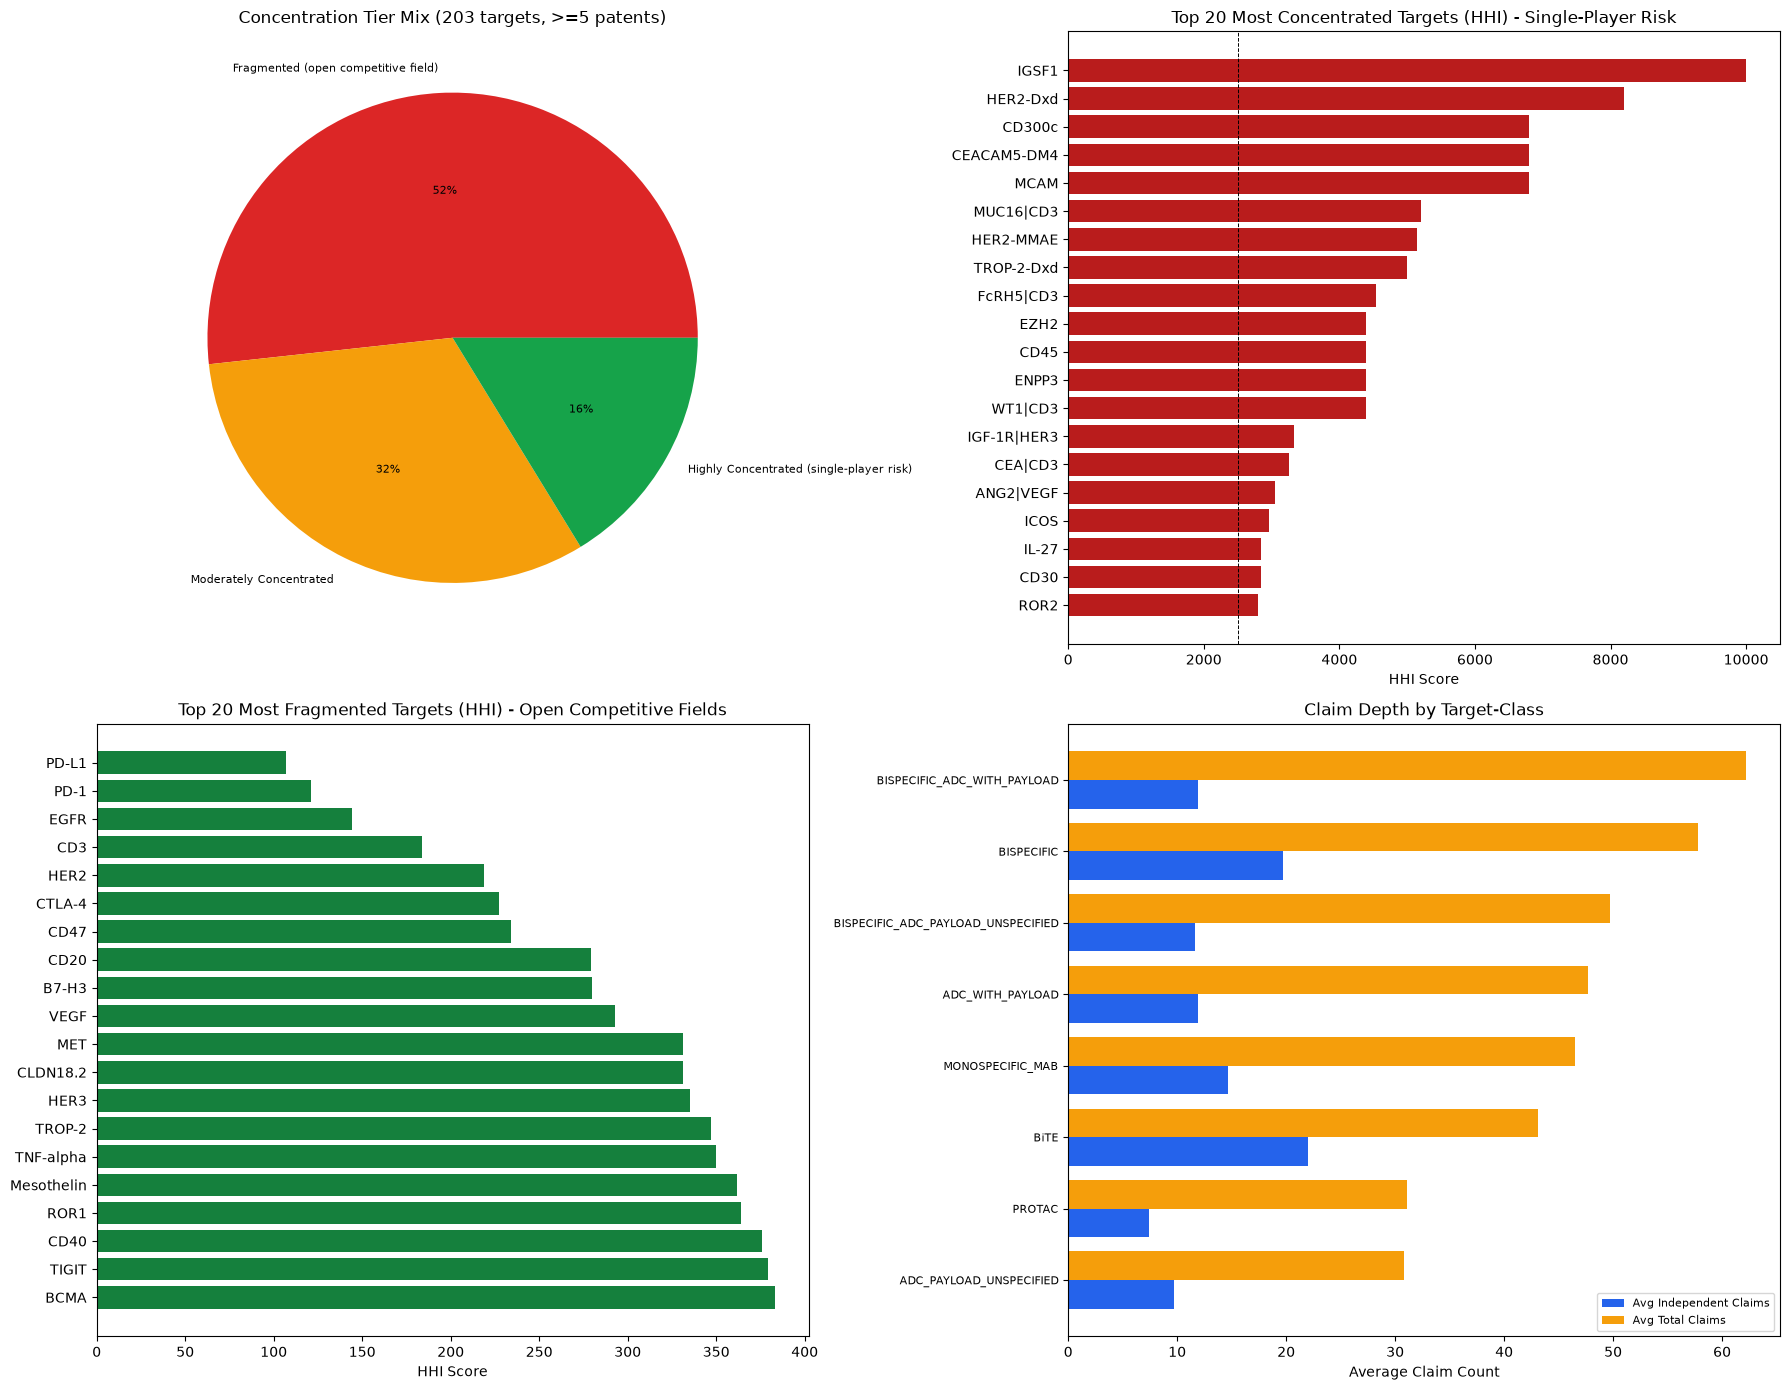

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
ax = axes[0, 0]
tier_counts = hhi_concentration_df["concentration_tier"].value_counts()
ax.pie(tier_counts.values, labels=tier_counts.index, autopct="%1.0f%%", colors=["#dc2626", "#f59e0b", "#16a34a"], textprops={"fontsize": 8})
ax.set_title(f"Concentration Tier Mix ({len(hhi_concentration_df)} targets, >=5 patents)")

ax = axes[0, 1]
top20_conc = hhi_concentration_df.nlargest(20, "hhi").sort_values("hhi")
ax.barh(top20_conc["target_name"], top20_conc["hhi"], color="#b91c1c")
ax.set_title("Top 20 Most Concentrated Targets (HHI) - Single-Player Risk"); ax.set_xlabel("HHI Score")
ax.axvline(2500, color="black", linestyle="--", linewidth=0.7)

ax = axes[1, 0]
top20_frag = hhi_concentration_df.nsmallest(20, "hhi").sort_values("hhi", ascending=False)
ax.barh(top20_frag["target_name"], top20_frag["hhi"], color="#15803d")
ax.set_title("Top 20 Most Fragmented Targets (HHI) - Open Competitive Fields"); ax.set_xlabel("HHI Score")

ax = axes[1, 1]
cd_sorted = claim_depth_by_class_df.sort_values("avg_total_claims")
x = range(len(cd_sorted))
ax.barh([i - 0.2 for i in x], cd_sorted["avg_independent_claims"], height=0.4, label="Avg Independent Claims", color="#2563eb")
ax.barh([i + 0.2 for i in x], cd_sorted["avg_total_claims"], height=0.4, label="Avg Total Claims", color="#f59e0b")
ax.set_yticks(list(x)); ax.set_yticklabels(cd_sorted["target_class"], fontsize=8)
ax.set_title("Claim Depth by Target-Class"); ax.set_xlabel("Average Claim Count"); ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## Entry 21: Key Findings & Insights

**Dataset & Data Quality**
- 8,901 antibody-therapeutics-in-oncology patent records, 2010-2025, from `ip_final_version3.csv`. `target_harmonized` resolves for 5,334 rows (3,567 null - mostly platform/technology patents with no specific target).
- The dataset **directly resolves the earlier HER2/HER2-DXd payload-conflation concern**: `target_harmonized` now encodes payload into the label itself (`HER2`, `HER2-Dxd`, `HER2-MMAE`, `HER2-DM1`, `HER2-Eribulin`, `HER2-Duocarmycin`, `HER2-Calicheamicin`), backed by dedicated `payload_class`/`payload_short` fields. HER2 (unspecified payload) = 143 patents / 105 assignees (fragmented, competitive), while HER2-Dxd = 9-10 patents concentrated almost entirely in one assignee (HHI ~8,200 - a single-player IP position), and HER2-MMAE, HER2-DM1 etc. are similarly small, distinct, highly concentrated clusters. Folding these together (as the original dataset did) would have masked a materially different competitive picture for each payload variant.

**Target Crowding & Whitespace**
- PD-1 (278), PD-L1 (178) and HER2 (156) remain the most crowded targets by raw patent volume out of 1,297 distinct `target_harmonized` values, but only 12 of 338 qualifying targets (>=3 patents) fall in the "Hot/Crowded" quadrant (high volume + high recent momentum) - most IP activity is spread across a long tail.
- 92 targets meet the "Emerging Whitespace" definition (total patents < 30, >= 30% filed since 2023, >= 5 patents to exclude noise). Notably, several are payload-specific ADC clusters invisible in the original conflated dataset: `HER2-MMAE` (13 patents, 69% recent, REMEGEN-dominated), `TROP-2-Dxd`, `CEACAM5-DM4`.
- Solid-tumor whitespace ranking (top 30 targets x 17 indications): Head & Neck and Mesothelioma are the least-claimed indications (20% of top targets have zero patents there); Breast, Lung, Ovarian, Pancreatic and Kidney/RCC are the most thoroughly claimed (<=3.3% whitespace).

**Modality / Target-Class Landscape**
- `MONOSPECIFIC_MAB` still dominates (70.3%), but `BISPECIFIC` (21.7%) is the clear #2 and growing category. PROTAC (76.9% recent) and unspecified-payload ADCs (63.5% recent) show the highest momentum - both accelerating faster than the dominant mAb class (21.8% recent).
- Bispecifics: CD3 is the universal T-cell-engager partner (552 patents, paired with 118 distinct targets); CD20|CD3 (47), EGFR|MET (45) and BCMA|CD3 (33) are the most-filed dual-target pairs of 604 total. 43.1% of patents target exactly 1 antigen, 16.7% target 2 (bispecific/multispecific).

**Payload-Class Whitespace**
- Topoisomerase I inhibitors (Dxd/SN-38/Exatecan family, 64 patents) and auristatins (MMAE, 28 patents) dominate disclosed ADC payload chemistry; PBD dimers, maytansinoids and several rarer classes (radioconjugates, amanitin, calicheamicin) remain thin - potential differentiation opportunities for a new ADC payload if paired with an underexploited target.
- For most ADC base targets (HER2, TROP-2, B7-H3, EGFR, PD-1/PD-L1, CLDN18.2), the majority of patents still have an **unspecified payload** - meaning payload chemistry itself is frequently the still-open competitive dimension even on "crowded" targets.

**Competitive Concentration & Claim Depth**
- 33 of 203 targets with >= 5 patents are "Highly Concentrated" (HHI >= 2500, effectively single-player IP positions) - many are payload-specific ADC clusters or under-explored bispecific pairs, making them attractive in-licensing/partnership targets rather than build-from-scratch targets.
- Bispecific and ADC-with-payload patents disclose sequence/CDR-level claim language far more often (83-95%) than monospecific mAbs (1.8%) - reflecting the more complex, format-specific claiming needed for multi-domain constructs.

**Strategic Implication for Program Design**: the crowding/whitespace picture changes meaningfully once modality, target-class and payload are disaggregated - a target that looks "crowded" at the antigen level (e.g. HER2) can still have wide-open, highly-concentrated-but-contestable payload sub-niches, and the bispecific landscape is structured around a small set of hub antigens (CD3, EGFR, PD-1/PD-L1) that any new bispecific program will need to differentiate against.


## Entry 22 (NEW): Indication x Modality-Class Whitespace - Emerging Promising Targets (ADC vs Bispecific vs Other)

New cut requested: for every **solid tumor** indication, split the target landscape into three modality buckets - `ADC` (any target-class with a payload, mono- or bispecific), `BISPECIFIC` (`BISPECIFIC`/`BiTE`, no payload), and `OTHER` (mAb/PROTAC/etc.) - then rank **emerging promising targets** per indication x bucket: low current patent volume (1-15 patents in that indication, i.e. not yet crowded) but high recent momentum (>= 25% filed since 2023). Full list, no cap - the filter criteria themselves define the population. Includes a dedicated drill-down answering "what are the promising, low-patent, recent ADC targets in lung cancer?".



In [21]:
HEME_KEYWORDS = ["leukemia", "lymphoma", "myeloma", "hematologic", "hematological", "blood cancer",
                  "AML", "ALL", "CLL", "CML", "MDS", "multiple myeloma", "non-hodgkin", "hodgkin"]
heme_exclude_sql = " AND ".join([f"tumor NOT ILIKE '%{kw}%'" for kw in HEME_KEYWORDS])

sql_indication_modality_emerging = f"""
WITH base AS (
  SELECT target_harmonized AS t, filing_year, current_assignee,
         CASE
           WHEN target_class IN ('ADC_WITH_PAYLOAD','ADC_PAYLOAD_UNSPECIFIED','BISPECIFIC_ADC_WITH_PAYLOAD','BISPECIFIC_ADC_PAYLOAD_UNSPECIFIED') THEN 'ADC'
           WHEN target_class IN ('BISPECIFIC','BiTE') THEN 'BISPECIFIC'
           ELSE 'OTHER (mAb/PROTAC/etc.)'
         END AS modality_bucket,
         TRIM(UNNEST(STR_SPLIT(TRIM(indications), '|'))) AS tumor
  FROM read_csv_auto('{csv_path.as_posix()}')
  WHERE target_harmonized IS NOT NULL AND indications IS NOT NULL AND TRIM(indications) NOT IN ('', 'oncology TA query hit')
),
solid AS (
  SELECT * FROM base WHERE {heme_exclude_sql}
),
agg AS (
  SELECT t AS target_name, modality_bucket, tumor AS indication,
         COUNT(*) AS total_patents,
         SUM(CASE WHEN filing_year >= 2023 THEN 1 ELSE 0 END) AS recent_3y,
         ROUND(100.0*SUM(CASE WHEN filing_year >= 2023 THEN 1 ELSE 0 END)/COUNT(*),1) AS pct_recent,
         COUNT(DISTINCT current_assignee) AS unique_assignees,
         MAX(filing_year) AS latest_filing_year
  FROM solid GROUP BY 1,2,3
)
SELECT *,
       ROW_NUMBER() OVER (PARTITION BY indication, modality_bucket ORDER BY pct_recent DESC, total_patents ASC) AS promising_rank
FROM agg
WHERE total_patents BETWEEN 1 AND 15 AND pct_recent >= 25
ORDER BY indication, modality_bucket, promising_rank;
"""
indication_modality_emerging_df = con.sql(sql_indication_modality_emerging).df()

n_indications = indication_modality_emerging_df["indication"].nunique()
n_combos = len(indication_modality_emerging_df)
display(Markdown(f"**Emerging Promising Targets by Solid-Tumor Indication x Modality-Class - full list, {n_combos:,} qualifying "
                  f"(target, indication, modality-bucket) rows across {n_indications} solid-tumor indications. "
                  f"Criteria: 1-15 patents filed in that indication (not yet crowded) AND >= 25% filed since 2023 (real momentum).**"))
display(indication_modality_emerging_df)

display(Markdown("**Top 3 (by `promising_rank`) per indication x modality-bucket - the shortlist view:**"))
top3_per_combo = indication_modality_emerging_df[indication_modality_emerging_df["promising_rank"] <= 3]
display(top3_per_combo)

display(Markdown("**Direct answer: Promising, low-patent, recent ADC targets in Lung Cancer:**"))
lung_adc = indication_modality_emerging_df[
    (indication_modality_emerging_df["modality_bucket"] == "ADC") &
    (indication_modality_emerging_df["indication"].str.contains("lung", case=False))
].sort_values("promising_rank")
display(lung_adc)

display(Markdown("**Same view, Bispecific targets in Lung Cancer:**"))
lung_bispecific = indication_modality_emerging_df[
    (indication_modality_emerging_df["modality_bucket"] == "BISPECIFIC") &
    (indication_modality_emerging_df["indication"].str.contains("lung", case=False))
].sort_values("promising_rank")
display(lung_bispecific)

display(Markdown(f"**Distinct solid-tumor indications covered ({n_indications}):** " + ", ".join(sorted(indication_modality_emerging_df['indication'].unique()))))


**Emerging Promising Targets by Solid-Tumor Indication x Modality-Class - full list, 4,431 qualifying (target, indication, modality-bucket) rows across 17 solid-tumor indications. Criteria: 1-15 patents filed in that indication (not yet crowded) AND >= 25% filed since 2023 (real momentum).**

,target_name,modality_bucket,indication,total_patents,recent_3y,pct_recent,unique_assignees,latest_filing_year,promising_rank
0,FGFR2,ADC,Bladder / urothelial,1,1.0,100.0,1,2025,1
1,EGFR|HER3-Auristatin,ADC,Bladder / urothelial,1,1.0,100.0,1,2025,2
2,CD47,ADC,Bladder / urothelial,1,1.0,100.0,1,2023,3
3,IL-4|STEAP1,ADC,Bladder / urothelial,1,1.0,100.0,1,2025,4
4,BCL-2,ADC,Bladder / urothelial,1,1.0,100.0,1,2024,5
...,...,...,...,...,...,...,...,...,...
4426,CLDN18.2|CD3,BISPECIFIC,Sarcoma,4,1.0,25.0,4,2024,183
4427,BCMA|CD28,BISPECIFIC,Sarcoma,4,1.0,25.0,3,2024,184
4428,B7-H3|CD3,BISPECIFIC,Sarcoma,4,1.0,25.0,4,2025,185
4429,CD19|CD3,BISPECIFIC,Sarcoma,12,3.0,25.0,8,2025,186


**Top 3 (by `promising_rank`) per indication x modality-bucket - the shortlist view:**

,target_name,modality_bucket,indication,total_patents,recent_3y,pct_recent,unique_assignees,latest_filing_year,promising_rank
0,FGFR2,ADC,Bladder / urothelial,1,1.0,100.0,1,2025,1
1,EGFR|HER3-Auristatin,ADC,Bladder / urothelial,1,1.0,100.0,1,2025,2
2,CD47,ADC,Bladder / urothelial,1,1.0,100.0,1,2023,3
75,B7-H7|CD3,BISPECIFIC,Bladder / urothelial,1,1.0,100.0,1,2025,1
76,CD16|EGFR,BISPECIFIC,Bladder / urothelial,1,1.0,100.0,1,2025,2
77,HER2|TNF-alpha,BISPECIFIC,Bladder / urothelial,1,1.0,100.0,1,2024,3
252,KRAS,ADC,Breast,1,1.0,100.0,1,2024,1
253,FGFR3-Dxd,ADC,Breast,1,1.0,100.0,1,2024,2
254,PD-L1|TROP-2-Exatecan,ADC,Breast,1,1.0,100.0,1,2024,3
349,IL-17A|CD3,BISPECIFIC,Breast,1,1.0,100.0,1,2023,1


**Direct answer: Promising, low-patent, recent ADC targets in Lung Cancer:**

,target_name,modality_bucket,indication,total_patents,recent_3y,pct_recent,unique_assignees,latest_filing_year,promising_rank
2579,NECTIN4-MMAE,ADC,Lung,1,1.0,100.0,1,2024,1
2580,CLDN18.2-Doxorubicin,ADC,Lung,1,1.0,100.0,1,2024,2
2581,EGFR|HER3-TOP1i,ADC,Lung,1,1.0,100.0,1,2024,3
2582,VEGF,ADC,Lung,1,1.0,100.0,1,2025,4
2583,ROR1-DM4,ADC,Lung,1,1.0,100.0,1,2025,5
2584,IL-4|STEAP1,ADC,Lung,1,1.0,100.0,1,2025,6
2585,FOLR1-Eribulin,ADC,Lung,1,1.0,100.0,1,2024,7
2586,LRRC15-Exatecan,ADC,Lung,1,1.0,100.0,1,2025,8
2587,ROR2-MMAE,ADC,Lung,1,1.0,100.0,1,2023,9
2588,PD-L1|TROP-2-Exatecan,ADC,Lung,1,1.0,100.0,1,2024,10


**Same view, Bispecific targets in Lung Cancer:**

,target_name,modality_bucket,indication,total_patents,recent_3y,pct_recent,unique_assignees,latest_filing_year,promising_rank
2678,C5aR1|GM-CSFRalpha,BISPECIFIC,Lung,1,1.0,100.0,1,2024,1
2679,LRRC15|FAP,BISPECIFIC,Lung,1,1.0,100.0,1,2025,2
2680,EGFR|B7-H3,BISPECIFIC,Lung,1,1.0,100.0,1,2023,3
2681,Mesothelin|CD28,BISPECIFIC,Lung,1,1.0,100.0,1,2023,4
2682,CD3|TrkB,BISPECIFIC,Lung,1,1.0,100.0,1,2023,5
2683,EGFR|FGFR,BISPECIFIC,Lung,1,1.0,100.0,1,2023,6
2684,B7-H3|GD2,BISPECIFIC,Lung,1,1.0,100.0,1,2023,7
2685,SIRP-alpha|CLDN18.2,BISPECIFIC,Lung,1,1.0,100.0,1,2024,8
2686,CD70|PD-1,BISPECIFIC,Lung,1,1.0,100.0,1,2025,9
2687,CD40|OX40,BISPECIFIC,Lung,1,1.0,100.0,1,2023,10


**Distinct solid-tumor indications covered (17):** Bladder / urothelial, Breast, Cervical, Colorectal, Esophageal, Gastric / GEJ, Glioblastoma / brain, Head and neck, Kidney / RCC, Liver / HCC, Lung, Melanoma, Mesothelioma, Ovarian, Pancreatic, Prostate, Sarcoma

## Entry 23 (NEW): Chart - Emerging Promising Targets by Indication x Modality (with Lung Cancer Deep-Dive)

Heatmap of promising-target counts (indication x modality bucket), plus a dedicated Lung Cancer panel ranking the top ADC and top Bispecific candidates by `promising_rank` (low patent count + high recent momentum).



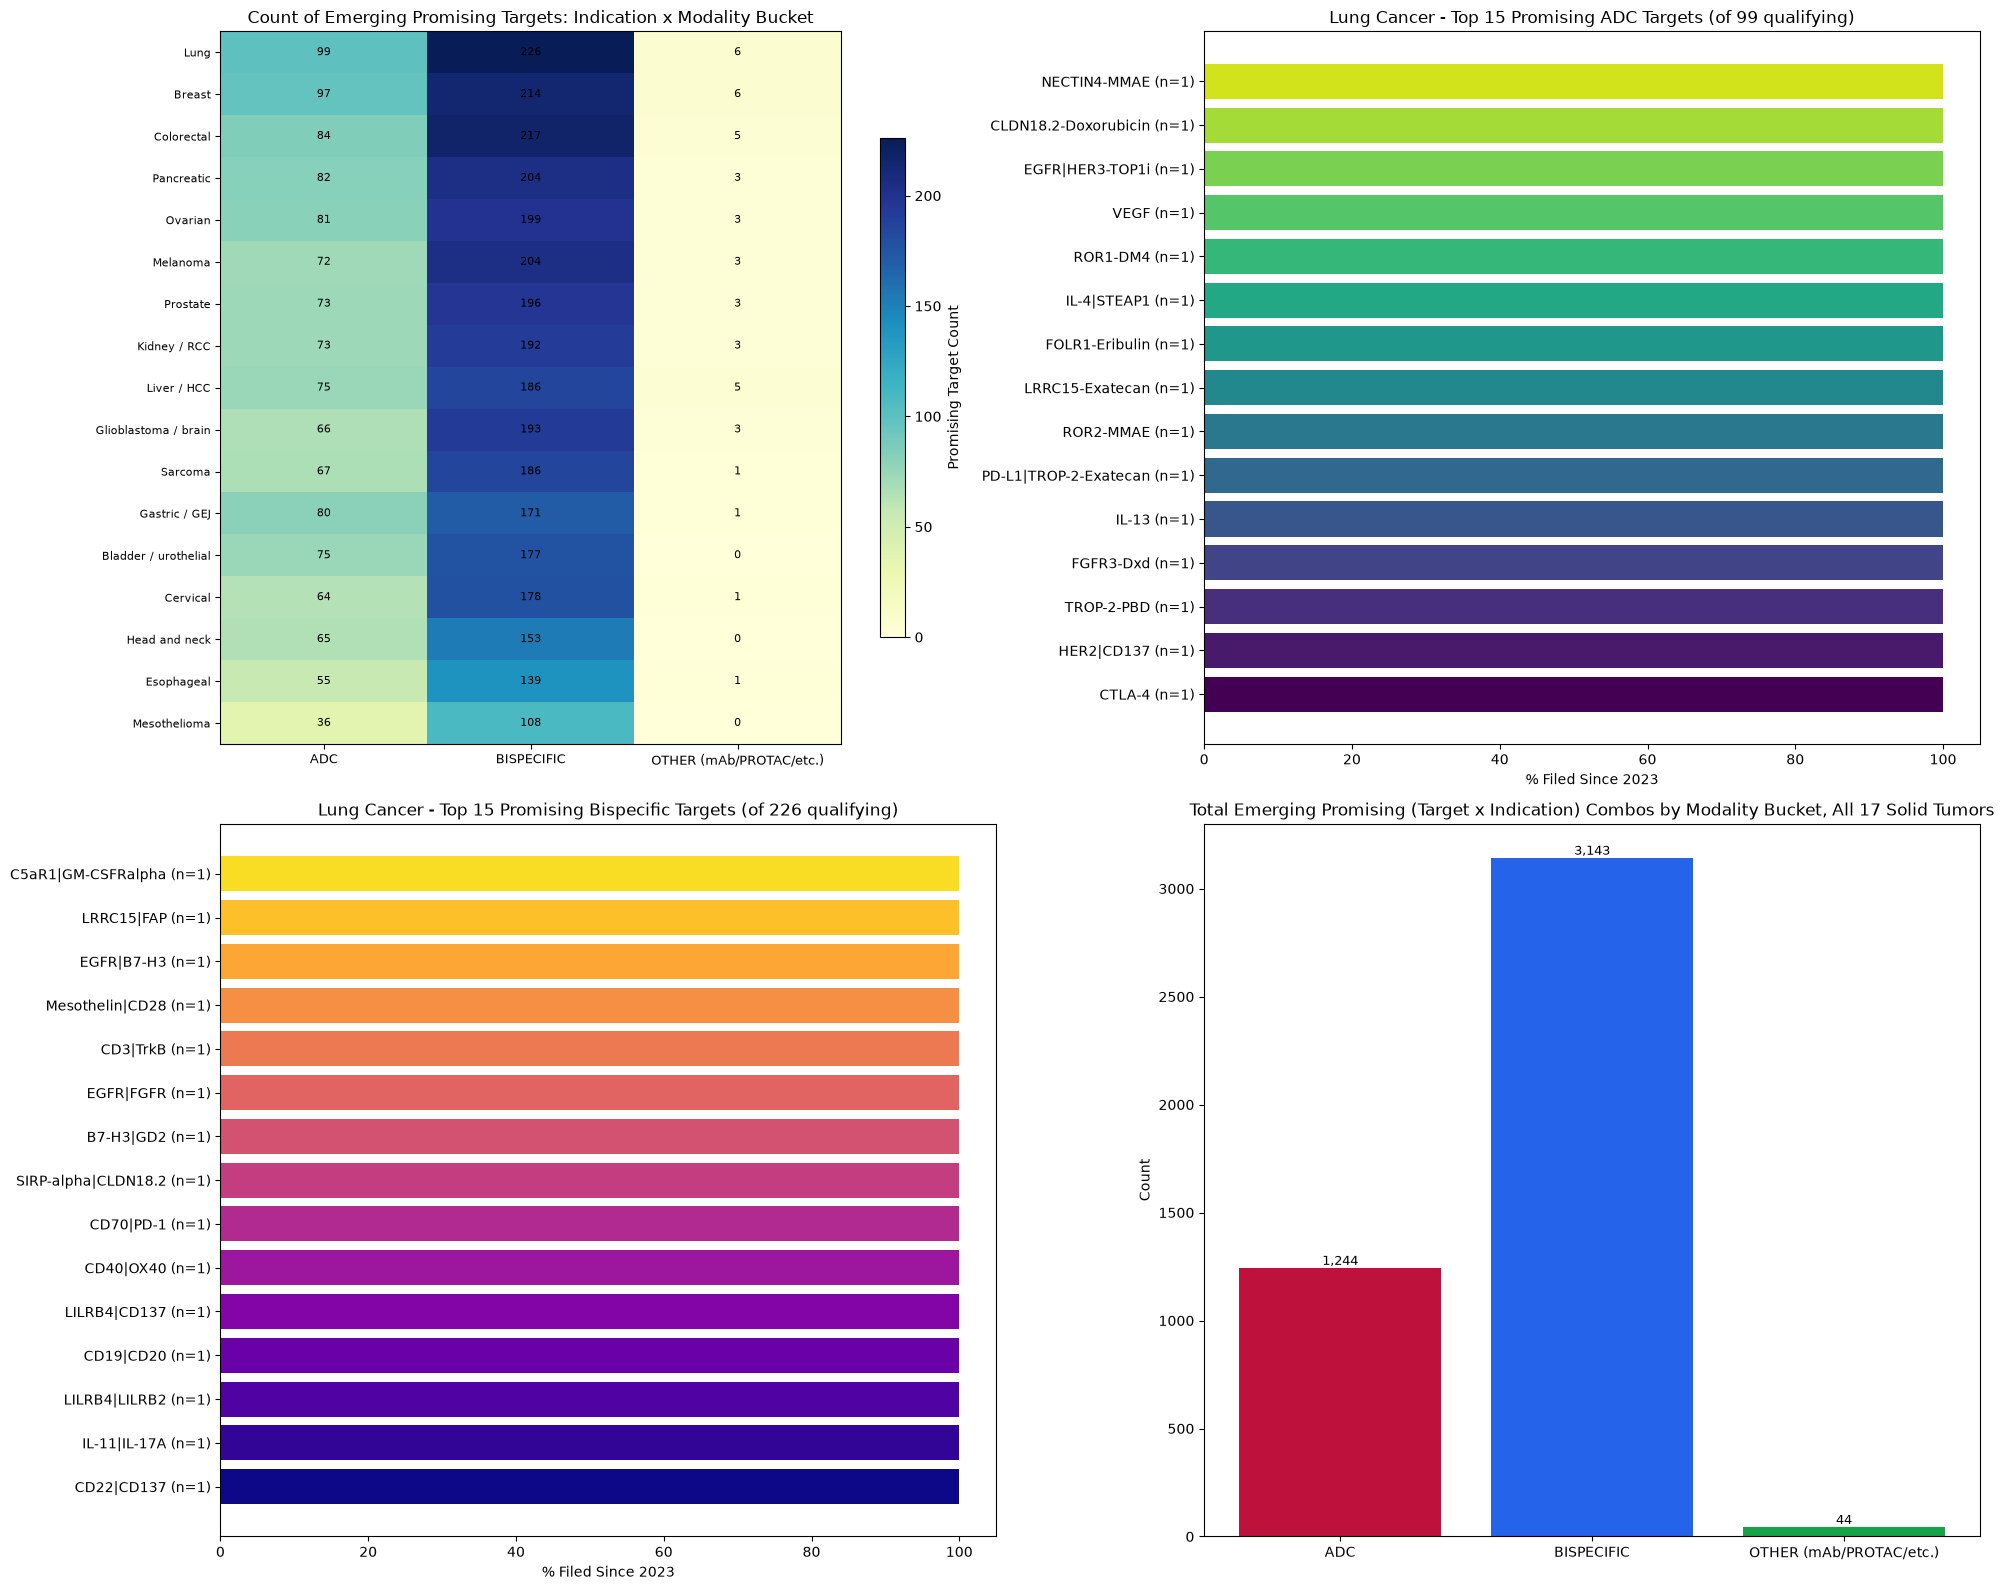

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# Panel 1: heatmap of count of promising targets per indication x modality bucket
counts_pivot = indication_modality_emerging_df.groupby(["indication", "modality_bucket"]).size().unstack(fill_value=0)
bucket_order = ["ADC", "BISPECIFIC", "OTHER (mAb/PROTAC/etc.)"]
counts_pivot = counts_pivot.reindex(columns=[b for b in bucket_order if b in counts_pivot.columns])
counts_pivot = counts_pivot.loc[counts_pivot.sum(axis=1).sort_values(ascending=False).index]
ax = axes[0, 0]
im = ax.imshow(counts_pivot.values, cmap="YlGnBu", aspect="auto")
for i in range(counts_pivot.shape[0]):
    for j in range(counts_pivot.shape[1]):
        ax.text(j, i, str(int(counts_pivot.values[i, j])), ha="center", va="center", fontsize=8)
ax.set_xticks(range(len(counts_pivot.columns))); ax.set_xticklabels(counts_pivot.columns, fontsize=9)
ax.set_yticks(range(len(counts_pivot.index))); ax.set_yticklabels(counts_pivot.index, fontsize=8)
ax.set_title("Count of Emerging Promising Targets: Indication x Modality Bucket")
fig.colorbar(im, ax=ax, shrink=0.7, label="Promising Target Count")

# Panel 2: Lung Cancer - Top 15 ADC promising targets (already computed above: lung_adc)
ax = axes[0, 1]
top15_lung_adc = lung_adc.nsmallest(15, "promising_rank").sort_values("promising_rank", ascending=False)
colors_adc = cm.viridis(1 - top15_lung_adc["promising_rank"] / top15_lung_adc["promising_rank"].max())
ax.barh(top15_lung_adc["target_name"] + " (n=" + top15_lung_adc["total_patents"].astype(str) + ")", top15_lung_adc["pct_recent"], color=colors_adc)
ax.set_title(f"Lung Cancer - Top 15 Promising ADC Targets (of {len(lung_adc)} qualifying)"); ax.set_xlabel("% Filed Since 2023")

# Panel 3: Lung Cancer - Top 15 Bispecific promising targets
ax = axes[1, 0]
top15_lung_bispecific = lung_bispecific.nsmallest(15, "promising_rank").sort_values("promising_rank", ascending=False)
colors_bsp = cm.plasma(1 - top15_lung_bispecific["promising_rank"] / top15_lung_bispecific["promising_rank"].max())
ax.barh(top15_lung_bispecific["target_name"] + " (n=" + top15_lung_bispecific["total_patents"].astype(str) + ")", top15_lung_bispecific["pct_recent"], color=colors_bsp)
ax.set_title(f"Lung Cancer - Top 15 Promising Bispecific Targets (of {len(lung_bispecific)} qualifying)"); ax.set_xlabel("% Filed Since 2023")

# Panel 4: total promising-target count by modality bucket, across all 17 solid tumor indications
ax = axes[1, 1]
bucket_totals = indication_modality_emerging_df["modality_bucket"].value_counts().reindex(bucket_order)
ax.bar(bucket_totals.index, bucket_totals.values, color=["#be123c", "#2563eb", "#16a34a"])
ax.set_title("Total Emerging Promising (Target x Indication) Combos by Modality Bucket, All 17 Solid Tumors")
ax.set_ylabel("Count")
for i, v in enumerate(bucket_totals.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()


## Entry 24 (NEW): Full Ranked Table - ALL Targets per Modality Bucket per Indication (Competitive Leaderboard)

Complementary to Entry 22 (which filtered to *emerging/promising* targets only), this gives the **complete ranked leaderboard** of every target within each (indication x modality-bucket) combination - no patent-count or recency filter. Ranked by `overall_rank` = total patent volume (descending), tie-broken by unique assignee count (descending), so rank 1 = the most crowded/dominant target in that indication+modality space, and the tail of each ranking = the least-contested (emerging) end. Full table, a Top-10-per-combo leaderboard shortlist across all 17 solid-tumor indications x 3 modality buckets, and Lung Cancer ADC/Bispecific Top-10 call-outs.



In [23]:
sql_target_modality_indication_rank = f"""
WITH base AS (
  SELECT target_harmonized AS t, filing_year, current_assignee,
         CASE
           WHEN target_class IN ('ADC_WITH_PAYLOAD','ADC_PAYLOAD_UNSPECIFIED','BISPECIFIC_ADC_WITH_PAYLOAD','BISPECIFIC_ADC_PAYLOAD_UNSPECIFIED') THEN 'ADC'
           WHEN target_class IN ('BISPECIFIC','BiTE') THEN 'BISPECIFIC'
           ELSE 'OTHER (mAb/PROTAC/etc.)'
         END AS modality_bucket,
         TRIM(UNNEST(STR_SPLIT(TRIM(indications), '|'))) AS tumor
  FROM read_csv_auto('{csv_path.as_posix()}')
  WHERE target_harmonized IS NOT NULL AND indications IS NOT NULL AND TRIM(indications) NOT IN ('', 'oncology TA query hit')
),
solid AS (
  SELECT * FROM base WHERE {heme_exclude_sql}
),
agg AS (
  SELECT t AS target_name, modality_bucket, tumor AS indication,
         COUNT(*) AS total_patents,
         SUM(CASE WHEN filing_year >= 2023 THEN 1 ELSE 0 END) AS recent_3y,
         ROUND(100.0*SUM(CASE WHEN filing_year >= 2023 THEN 1 ELSE 0 END)/COUNT(*),1) AS pct_recent,
         COUNT(DISTINCT current_assignee) AS unique_assignees,
         MAX(filing_year) AS latest_filing_year
  FROM solid GROUP BY 1,2,3
)
SELECT *,
       ROW_NUMBER() OVER (PARTITION BY indication, modality_bucket ORDER BY total_patents DESC, unique_assignees DESC, pct_recent DESC) AS overall_rank
FROM agg
ORDER BY indication, modality_bucket, overall_rank;
"""
target_modality_indication_rank_df = con.sql(sql_target_modality_indication_rank).df()

display(Markdown(f"**Full ranked leaderboard - every (target, indication, modality-bucket) combination, {len(target_modality_indication_rank_df):,} rows "
                  f"across {target_modality_indication_rank_df['indication'].nunique()} solid-tumor indications x "
                  f"{target_modality_indication_rank_df['modality_bucket'].nunique()} modality buckets. "
                  f"`overall_rank` 1 = most crowded/dominant target (highest patent volume) in that indication+modality space; "
                  f"highest `overall_rank` = least-contested / emerging end.**"))
display(target_modality_indication_rank_df)

# Top-10-per-combo leaderboard shortlist (most dominant targets), across all indications x modality buckets
top10_per_combo_overall = target_modality_indication_rank_df[target_modality_indication_rank_df["overall_rank"] <= 10].reset_index(drop=True)
display(Markdown(f"**Top 10 (by patent volume / dominance) per indication x modality-bucket - leaderboard shortlist, {len(top10_per_combo_overall):,} rows:**"))
display(top10_per_combo_overall)

# Lung Cancer call-outs: Top 10 dominant ADC targets and Top 10 dominant Bispecific targets
lung_adc_ranked = target_modality_indication_rank_df[(target_modality_indication_rank_df["indication"] == "Lung") & (target_modality_indication_rank_df["modality_bucket"] == "ADC")].sort_values("overall_rank")
lung_bispecific_ranked = target_modality_indication_rank_df[(target_modality_indication_rank_df["indication"] == "Lung") & (target_modality_indication_rank_df["modality_bucket"] == "BISPECIFIC")].sort_values("overall_rank")

display(Markdown(f"**Lung Cancer - Top 10 most-dominant ADC targets (by patent volume, {len(lung_adc_ranked)} total ADC targets in Lung):**"))
display(lung_adc_ranked.head(10))

display(Markdown(f"**Lung Cancer - Top 10 most-dominant Bispecific targets (by patent volume, {len(lung_bispecific_ranked)} total Bispecific targets in Lung):**"))
display(lung_bispecific_ranked.head(10))


**Full ranked leaderboard - every (target, indication, modality-bucket) combination, 9,174 rows across 17 solid-tumor indications x 3 modality buckets. `overall_rank` 1 = most crowded/dominant target (highest patent volume) in that indication+modality space; highest `overall_rank` = least-contested / emerging end.**

,target_name,modality_bucket,indication,total_patents,recent_3y,pct_recent,unique_assignees,latest_filing_year,overall_rank
0,HER2,ADC,Bladder / urothelial,35,26.0,74.3,24,2025,1
1,HER2-Dxd,ADC,Bladder / urothelial,10,2.0,20.0,2,2025,2
2,TROP-2,ADC,Bladder / urothelial,8,6.0,75.0,7,2025,3
3,PD-1,ADC,Bladder / urothelial,7,5.0,71.4,6,2024,4
4,B7-H3,ADC,Bladder / urothelial,6,5.0,83.3,5,2025,5
...,...,...,...,...,...,...,...,...,...
9169,CRBN,OTHER (mAb/PROTAC/etc.),Sarcoma,1,1.0,100.0,1,2023,1
9170,MUC1,OTHER (mAb/PROTAC/etc.),Sarcoma,1,0.0,0.0,1,2011,2
9171,ERG,OTHER (mAb/PROTAC/etc.),Sarcoma,1,0.0,0.0,1,2010,3
9172,GD2,OTHER (mAb/PROTAC/etc.),Sarcoma,1,0.0,0.0,1,2018,4


**Top 10 (by patent volume / dominance) per indication x modality-bucket - leaderboard shortlist, 454 rows:**

,target_name,modality_bucket,indication,total_patents,recent_3y,pct_recent,unique_assignees,latest_filing_year,overall_rank
0,HER2,ADC,Bladder / urothelial,35,26.0,74.3,24,2025,1
1,HER2-Dxd,ADC,Bladder / urothelial,10,2.0,20.0,2,2025,2
2,TROP-2,ADC,Bladder / urothelial,8,6.0,75.0,7,2025,3
3,PD-1,ADC,Bladder / urothelial,7,5.0,71.4,6,2024,4
4,B7-H3,ADC,Bladder / urothelial,6,5.0,83.3,5,2025,5
5,HER2-MMAE,ADC,Bladder / urothelial,6,5.0,83.3,3,2025,6
6,TROP-2-Dxd,ADC,Bladder / urothelial,6,3.0,50.0,3,2025,7
7,B7-H3|CD28,ADC,Bladder / urothelial,5,5.0,100.0,2,2024,8
8,EGFR|MET,ADC,Bladder / urothelial,4,4.0,100.0,4,2025,9
9,MUC1,ADC,Bladder / urothelial,4,3.0,75.0,4,2025,10


**Lung Cancer - Top 10 most-dominant ADC targets (by patent volume, 156 total ADC targets in Lung):**

,target_name,modality_bucket,indication,total_patents,recent_3y,pct_recent,unique_assignees,latest_filing_year,overall_rank
5285,HER2,ADC,Lung,45,33.0,73.3,28,2025,1
5286,B7-H3,ADC,Lung,23,19.0,82.6,17,2025,2
5287,EGFR,ADC,Lung,16,10.0,62.5,14,2025,3
5288,DLL3,ADC,Lung,11,9.0,81.8,10,2025,4
5289,TROP-2,ADC,Lung,11,7.0,63.6,8,2025,5
5290,HER2-Dxd,ADC,Lung,10,2.0,20.0,2,2025,6
5291,EGFR|MET,ADC,Lung,9,9.0,100.0,9,2025,7
5292,HER3,ADC,Lung,8,7.0,87.5,7,2025,8
5293,PD-1,ADC,Lung,7,4.0,57.1,6,2024,9
5294,HER2-MMAE,ADC,Lung,6,5.0,83.3,4,2025,10


**Lung Cancer - Top 10 most-dominant Bispecific targets (by patent volume, 496 total Bispecific targets in Lung):**

,target_name,modality_bucket,indication,total_patents,recent_3y,pct_recent,unique_assignees,latest_filing_year,overall_rank
5441,CD3,BISPECIFIC,Lung,33,17.0,51.5,25,2025,1
5442,EGFR|MET,BISPECIFIC,Lung,30,19.0,63.3,14,2025,2
5443,EGFR|CD3,BISPECIFIC,Lung,21,4.0,19.0,16,2025,3
5444,PD-L1|CD137,BISPECIFIC,Lung,17,7.0,41.2,13,2025,4
5445,CD20|CD3,BISPECIFIC,Lung,17,8.0,47.1,10,2025,5
5446,EpCAM|CD3,BISPECIFIC,Lung,15,7.0,46.7,13,2025,6
5447,CD19|CD3,BISPECIFIC,Lung,15,5.0,33.3,11,2025,7
5448,HER2|CD3,BISPECIFIC,Lung,14,5.0,35.7,12,2024,8
5449,DLL3|CD3,BISPECIFIC,Lung,13,5.0,38.5,10,2025,9
5450,CEA|CD3,BISPECIFIC,Lung,13,1.0,7.7,7,2024,10
